## **1. Establezca una conexión con la api de sentinel 2, puede usar para eso el módulo openeo.**

In [ ]:
import openeo
conn = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

## **2 y 3.**

Descarga los .tif de cada uno de los lagos usando para eso las coordenadas o el geojson provisto.

Selecciona un período de observación: mínimo 6 meses. Tenga en cuenta que serán útiles imágenes con menos nubosidad.

In [ ]:
COLLECTION = "SENTINEL2_L1C"                 
TEMPORAL_EXTENT = ["2025-01-01", "2025-08-14"]
MAX_CLOUD = 20

BANDS = ["B02", "B03", "B04", "B05", "B07", "B8A", "B08", "B11", "B12"]

# BBoxes (EPSG:4326)
lago_atitlan = {"west": -91.326256, "east": -91.07151, "south": 14.5948,   "north": 14.750979}
lago_amatitlan = {"west": -90.638065, "east": -90.512924, "south": 14.412347, "north": 14.493799}

def to_extent(box):
    return {"west": box["west"], "south": box["south"], "east": box["east"], "north": box["north"], "crs": "EPSG:4326"}

def descargar_lago(nombre, box, carpeta):
    print(f"\n🔎 {nombre}: S2 L1C {TEMPORAL_EXTENT[0]} → {TEMPORAL_EXTENT[1]} con ≤{MAX_CLOUD}% nubes, remuestreado a 10 m (EPSG:32616)…")

    cube = conn.load_collection(
        collection_id=COLLECTION,
        spatial_extent=to_extent(box),
        temporal_extent=TEMPORAL_EXTENT,
        bands=BANDS,
        max_cloud_cover=MAX_CLOUD
    )

    # remuestreo a 10 m y proyección común (UTM 16N ~ Guatemala)
    cube = cube.resample_spatial(resolution=10, projection="EPSG:32616", method="near")

    # GeoTIFF multibanda por fecha (time-slices)
    result = cube.save_result(format="GTIFF")
    job = conn.create_job(result, title=f"{nombre} S2 L1C ≤{MAX_CLOUD}% (ene-ago 2025, 10m)")
    job.start_and_wait().get_results().download_files(target=carpeta)

    print(f"✅ {nombre}: archivos guardados en './{carpeta}'")


descargar_lago("Lago Atitlán",   lago_atitlan,   "descargas_atitlan_fechas")
descargar_lago("Lago Amatitlán", lago_amatitlan, "descargas_amatitlan")

## **4. Aplica el script de detección de cianobacteria de Sentinel Hub (por ejemplo, Cyano Detection Script) para cada imagen.**
    # 4.1. Puede calcularlo en copernicus browser y descargar los resultados o puede calcularlo usando para eso las bandas que incluyó la descarga de cada una de las imágenes.

In [ ]:
import os, glob, re
import numpy as np
import rasterio
from tqdm import tqdm
import pandas as pd
import scipy.ndimage as ndi  

IN_DIRS = [
    ("Lago Atitlán", "descargas_atitlan_fechas"),
    ("Lago Amatitlán", "descargas_amatitlan"),
]

OUT_BASE = "ciano_outputs"  # rasters procesados espejo a la estructura de entrada
TS_OUT   = "timeseries"     # CSV por lago
os.makedirs(OUT_BASE, exist_ok=True)
os.makedirs(TS_OUT, exist_ok=True)

def safe_div(a, b):
    with np.errstate(divide='ignore', invalid='ignore'):
        out = np.true_divide(a, b)
        out[~np.isfinite(out)] = 0.0
    return out

def open_bands(path):
    """
    Abre tif multibanda con B02,B03,B04,B05,B07,B8A,B08,B11,B12 (en ese orden).
    Normaliza a [0,1] si vienen en 0..10000 (reflectancia escalada).
    """
    names = ["B02","B03","B04","B05","B07","B8A","B08","B11","B12"]
    with rasterio.open(path) as src:
        if src.count < 9:
            raise ValueError(f"{path} necesita 9 bandas (tiene {src.count})")
        arr = {}
        for i, n in enumerate(names, 1):
            b = src.read(i).astype(np.float32)
            if np.nanpercentile(b, 99) > 1.5:  
                b = b / 10000.0
            b = np.clip(b, 0.0, 1.0)
            arr[n] = b
        profile = src.profile
    return arr, profile

def cloud_shadow_mask(B02, B03, B04, B08, B11, B12,
                      thr_vis=0.20, thr_swir=0.10,
                      thr_shadow_nir=0.08, thr_shadow_swir=0.04,
                      dilate_px=1):
    """
    True = ENMASCARAR (nube/sombra).
      - Nube: muy brillante en visible (B02-04) y elevada en SWIR (B11/B12).
      - Sombra: muy oscura en NIR (B08) y SWIR.
    Todas las bandas deben estar en reflectancia [0..1].
    """
    bright_vis  = (B02 > thr_vis) & (B03 > thr_vis) & (B04 > thr_vis)
    bright_swir = (B11 > thr_swir) | (B12 > thr_swir)
    cloud = bright_vis & bright_swir

    shadow = (B08 < thr_shadow_nir) & ((B11 < thr_shadow_swir) | (B12 < thr_shadow_swir))

    mask = cloud | shadow
    if dilate_px and np.any(mask):
        mask = ndi.binary_dilation(mask, iterations=dilate_px)
    return mask

def wbi(B04,B03,B02,B08,B11,B12, MNDWI_threshold=0.42, NDWI_threshold=0.4, filter_UABS=True):
    ndvi = safe_div((B08 - B04), (B08 + B04))
    mndwi = safe_div((B03 - B11), (B03 + B11))
    ndwi = safe_div((B03 - B08), (B03 + B08))
    ndwi_leaves = safe_div((B08 - B11), (B08 + B11))
    aweish = B02 + 2.5*B03 - 1.5*(B08 + B11) - 0.25*B12
    aweinsh = 4*(B03 - B11) - (0.25*B08 + 2.75*B11)
    dbsi = safe_div((B11 - B03), (B11 + B03)) - ndvi

    ws = np.zeros(B04.shape, dtype=np.uint8)
    cond_water = (
        (mndwi > MNDWI_threshold) |
        (ndwi  > NDWI_threshold)  |
        (aweinsh > 0.1879)        |
        (aweish  > 0.1112)        |
        (ndvi    < -0.2)          |
        (ndwi_leaves > 1)
    )
    ws[cond_water] = 1
    if filter_UABS:
        cond_urban_bare = (aweinsh <= -0.03) | (dbsi > 0)
        ws[cond_urban_bare] = 0
    return ws

def FAI(B04, B07, B8A):
    return (B07 - B04) - (B8A - B04) * ((783.0 - 665.0)/(865.0 - 665.0))

def NDCI(B04, B05):
    return safe_div((B05 - B04), (B05 + B04))

def chl_from_ndci(ndci):
    return 826.57*(ndci**3) - 176.43*(ndci**2) + 19.0*ndci + 4.071


PALETTE = [
    (0.5,   (0,  0,255)),
    (1,     (0,  0,255)),
    (2.5,   (0, 59,255)),
    (3.5,   (0, 98,255)),
    (5,     (15,113,141)),
    (7,     (14,141,120)),
    (8,     (13,141,103)),
    (10,    (30,226, 28)),
    (14,    (42,226, 28)),
    (18,    (68,226, 28)),
    (20,    (68,226, 28)),
    (24,    (134,247, 0)),
    (28,    (140,247, 0)),
    (30,    (205,237, 0)),
    (38,    (208,240, 0)),
    (45,    (208,240, 0)),
    (50,    (251,210, 3)),
    (75,    (248,207, 2)),
    (90,    (134,247, 0)),
    (100,   (245,164, 9)),
    (150,   (240,159, 8)),
    (250,   (237,157, 7)),
    (300,   (239,118,15)),
    (350,   (239,101,15)),
    (450,   (239,100,14)),
    (500,   (233, 72,21)),
]
FAI_COLOR = (233, 72, 21)
FALLBACK  = (233, 72, 21)

def render_rgb(water, FAIv, chl, B04,B03,B02):
    H, W = chl.shape
    rgb = np.zeros((3, H, W), dtype=np.uint8)
    # tierra -> true color (3*B04, 3*B03, 3*B02)
    land = (water == 0)
    tc = np.stack([3*B04, 3*B03, 3*B02], axis=0)
    tc255 = np.clip(tc*255.0, 0, 255).astype(np.uint8)
    rgb[:, land] = tc255[:, land]
    # agua
    agua = (water == 1)
    # FAI primero
    fai_mask = agua & (FAIv > 0.08)
    if np.any(fai_mask):
        rgb[:, fai_mask] = np.array(FAI_COLOR, dtype=np.uint8)[:, None]
    restante = agua & (~fai_mask)
    if np.any(restante):
        assigned = np.zeros_like(restante, dtype=bool)
        for thr, col in PALETTE:
            m = restante & (~assigned) & (chl < thr)
            if np.any(m):
                rgb[:, m] = np.array(col, dtype=np.uint8)[:, None]
                assigned[m] = True
        m_fb = restante & (~assigned)
        if np.any(m_fb):
            rgb[:, m_fb] = np.array(FALLBACK, dtype=np.uint8)[:, None]
    return rgb

def process_one(in_path, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    bands, profile = open_bands(in_path)

    B02 = bands["B02"]; B03 = bands["B03"]; B04 = bands["B04"]; B05 = bands["B05"]
    B07 = bands["B07"]; B8A = bands["B8A"]; B08 = bands["B08"]; B11 = bands["B11"]; B12 = bands["B12"]

    # 0) máscara de nubes/sombras solo con L1C
    m_cloud = cloud_shadow_mask(B02, B03, B04, B08, B11, B12,
                                thr_vis=0.20, thr_swir=0.10,
                                thr_shadow_nir=0.08, thr_shadow_swir=0.04,
                                dilate_px=1)

    # 1) máscara de agua (WBI)
    water = wbi(B04,B03,B02,B08,B11,B12).astype(bool)

    # 2) índices espectrales
    FAIv  = FAI(B04,B07,B8A)
    ndci  = NDCI(B04,B05)
    chl   = chl_from_ndci(ndci).astype(np.float32)

    # 3) máscara final: fuera de agua O nubes/sombras -> NaN
    m_nodata = (~water) | m_cloud
    chl_masked = chl.copy()
    chl_masked[m_nodata] = np.nan

    # 4) clip físico para estabilidad
    chl_masked = np.clip(chl_masked, 0.0, 500.0)

    # 5) render temático (usa water y chl_masked)
    rgb = render_rgb(water.astype(np.uint8), FAIv, chl_masked, B04,B03,B02)

    base = os.path.splitext(os.path.basename(in_path))[0]
    rgb_path = os.path.join(out_dir, f"{base}_cyano_rgb.tif")
    chl_path = os.path.join(out_dir, f"{base}_chl.tif")

    # RGB
    rgb_prof = profile.copy()
    rgb_prof.update({"count": 3, "dtype": "uint8", "compress": "lzw", "nodata": None})
    with rasterio.open(rgb_path, "w", **rgb_prof) as dst:
        dst.write(rgb[0], 1); dst.write(rgb[1], 2); dst.write(rgb[2], 3)

    # Chl-a (float32) con NaN fuera de agua/nubes/sombras
    chl_prof = profile.copy()
    chl_prof.update({"count": 1, "dtype": "float32", "compress": "lzw", "nodata": np.nan})
    with rasterio.open(chl_path, "w", **chl_prof) as dst:
        dst.write(chl_masked, 1)

    return rgb_path, chl_path

def walk_and_process(in_root, out_root):
    tifs = sorted(glob.glob(os.path.join(in_root, "**", "*.tif"), recursive=True))
    if not tifs:
        print(f"⚠️ No hay .tif en {in_root}")
        return []
    out_chl_files = []
    print(f"Procesando {len(tifs)} archivos de {in_root} …")
    for tif in tqdm(tifs):
        rel = os.path.relpath(os.path.dirname(tif), in_root)
        out_dir = os.path.join(out_root, rel)
        try:
            _, chl_path = process_one(tif, out_dir)
            out_chl_files.append(chl_path)
        except Exception as e:
            print(f"❌ Error en {tif}: {e}")
    return out_chl_files

DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

def extract_date_from_path(p):
    m = DATE_RE.search(p)
    return m.group(1) if m else None

def summarize_chl(chl_tif):
    with rasterio.open(chl_tif) as src:
        a = src.read(1).astype(np.float32)
    valid = np.isfinite(a)
    if not np.any(valid):
        return dict(mean=np.nan, median=np.nan, p90=np.nan, std=np.nan, water_px=0)
    vals = a[valid]
    return dict(
        mean   = float(np.nanmean(vals)),
        median = float(np.nanmedian(vals)),
        p90    = float(np.nanpercentile(vals, 90)),
        std    = float(np.nanstd(vals)),
        water_px = int(valid.sum())
    )

def build_timeseries(lake_name, out_root, csv_path):
    chl_files = sorted(glob.glob(os.path.join(out_root, "**", "*_chl.tif"), recursive=True))
    rows = []
    for f in chl_files:
        d = extract_date_from_path(f)
        if d is None:
            continue
        stats = summarize_chl(f)
        rows.append({"date": d, **stats})
    if not rows:
        print(f"⚠️ {lake_name}: no se pudieron construir series (sin fechas detectadas).")
        return
    df = pd.DataFrame(rows).sort_values("date")
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df["timestamp_s"]  = (df.index.view("int64") // 10**9).astype("int64")        
    df["date_ordinal"] = df.index.map(pd.Timestamp.toordinal).astype("int64")      
    df["doy"]          = df.index.dayofyear.astype("int64")
    df["year"]         = df.index.year.astype("int64")
    df["month"]        = df.index.month.astype("int64")
    df["day"]          = df.index.day.astype("int64")
    df.to_csv(csv_path, index=True)
    print(f"🧾 Serie temporal guardada: {csv_path}")
    return df


for lake_name, in_dir in IN_DIRS:
    print(f"\n=== {lake_name} ===")
    out_dir = os.path.join(OUT_BASE, os.path.basename(in_dir))
    chl_files = walk_and_process(in_dir, out_dir)
    csv_path = os.path.join(TS_OUT, f"{os.path.basename(in_dir)}_chl_timeseries.csv")
    build_timeseries(lake_name, out_dir, csv_path)

print("\n✅ Listo. Rasters en:", OUT_BASE, " | Series en:", TS_OUT)

*Suavizar y mejorar las vistas tanto de ati como amati*

In [ ]:
import os, glob, re, json
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling, transform_geom
from rasterio import features
import matplotlib.pyplot as plt

LAKE_NAME = "Atitlán"
L2A_DIR   = "descargas_atitlan_fechas"          
USE_POLYGON = os.path.exists("lago_atitlan.geojson")
LAKE_POLYGON_GEOJSON = "lago_atitlan.geojson"   
OUT_DIR   = "chl_soft_out_ati"
NCOLS     = 6

SCL_CLOUDS = {3,8,9,10,11}        # sombras, nubes med/altas, cirrus, nieve/hielo
ERODE_WATER_PIXELS = 0            # 0 = sin erosión (más laxo); sube a 1–2 si ves orillas sucias

V_CLAMP = (0, 200)                
P_LOW, P_HIGH = 5, 95

DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})", re.I)
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

def list_openEO(L2A_DIR):
    files = sorted(glob.glob(os.path.join(L2A_DIR, "openEO_*Z.tif")))
    items = []
    for p in files:
        m = DATE_RE.search(os.path.basename(p))
        if m:
            items.append((m.group(1), p))
    return items

def rasterize_polygon_on(transform, shape, dst_crs, geojson_path):
    with open(geojson_path, "r", encoding="utf-8") as f:
        gj = json.load(f)
    if gj.get("type") == "FeatureCollection":
        geoms = [g["geometry"] for g in gj["features"]]
    elif gj.get("type") == "Feature":
        geoms = [gj["geometry"]]
    else:
        geoms = [gj]
    geoms = [(transform_geom("EPSG:4326", dst_crs.to_string(), g), 1) for g in geoms]
    mask = features.rasterize(geoms, out_shape=shape, transform=transform,
                              fill=0, all_touched=True, dtype="uint8").astype(bool)
    return mask

def to_match_band(src_path, band_index, dst_tr, dst_crs, W, H, resampling=Resampling.bilinear):
    with rasterio.open(src_path) as src:
        out = np.full((H,W), np.nan, dtype=np.float32)
        reproject(
            source=rasterio.band(src, band_index),
            destination=out,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=dst_tr,    dst_crs=dst_crs,
            resampling=resampling,
            src_nodata=src.nodata, dst_nodata=np.nan
        )
    return out

def soft_masks_from_SCL(scl, lake_mask):
    # rellena NaN de SCL con -1 para poder castear sin warnings
    scl = np.where(np.isfinite(scl), scl, -1).astype(np.int16)
    cloud_mask = np.isin(scl, list(SCL_CLOUDS))
    if USE_POLYGON:
        water_mask = lake_mask.copy()
    else:
        # SIN polígono: usa agua SCL==6 
        water_mask = (scl == 6)
    if ERODE_WATER_PIXELS > 0:
        try:
            from scipy.ndimage import binary_erosion
            water_mask = binary_erosion(water_mask, iterations=ERODE_WATER_PIXELS,
                                        structure=np.ones((3,3), dtype=bool))
        except Exception:
            pass
    valid = water_mask & (~cloud_mask)
    return valid, water_mask, cloud_mask

def compute_CHL_soft(rrs_b02, rrs_b03, rrs_b04, rrs_b05):
    # Índices "suaves"
    tiny = 1e-6
    with np.errstate(divide='ignore', invalid='ignore'):
        ndci = (rrs_b05 - rrs_b04) / (rrs_b05 + rrs_b04 + tiny)
        oc3  = np.log10((rrs_b02 + tiny) / (rrs_b03 + tiny))
    # Combinación pragmática (ajusta coeficientes si quieres)
    chl_low  = 10 ** (0.4 + 3.0 * oc3)            # cloros bajas/medias
    chl_high = 40.0 * ndci + 2.0                  # cloros altas (lineal en NDCI)
    chl_soft = np.where(ndci > 0, chl_high, chl_low)
    chl_soft = np.clip(chl_soft, V_CLAMP[0], V_CLAMP[1])
    chl_soft[~np.isfinite(chl_soft)] = np.nan
    return ndci, oc3, chl_soft

items = list_openEO(L2A_DIR)
if not items:
    raise SystemExit(f"No encontré multibandas openEO_*Z.tif en {L2A_DIR}")

rows, stacks = [], []
for date_iso, mb in items:
    with rasterio.open(mb) as src:
        H,W = src.height, src.width
        dst_tr, dst_crs = src.transform, src.crs
        # Sentinel-2 L2A (openEO): orden típico de bandas
        b02 = src.read(1).astype(np.float32)   # 490 nm
        b03 = src.read(2).astype(np.float32)   # 560 nm
        b04 = src.read(3).astype(np.float32)   # 665 nm
        b05 = src.read(4).astype(np.float32)   # 705 nm
        scl = src.read(10).astype(np.float32)  # SCL
        # escala a reflectancia 0..1
        rrs_b02 = b02 / 10000.0
        rrs_b03 = b03 / 10000.0
        rrs_b04 = b04 / 10000.0
        rrs_b05 = b05 / 10000.0

    # máscara lago
    if USE_POLYGON:
        lake_mask = rasterize_polygon_on(dst_tr, (H,W), dst_crs, LAKE_POLYGON_GEOJSON)
    else:
        lake_mask = np.ones((H,W), dtype=bool)

    # máscara ligera con SCL
    valid_mask, water_mask, cloud_mask = soft_masks_from_SCL(scl, lake_mask)

    # CHL_soft
    ndci, oc3, chl = compute_CHL_soft(rrs_b02, rrs_b03, rrs_b04, rrs_b05)
    chl_masked = np.where(valid_mask, chl, np.nan)

    # métricas rápidas
    lake_px = int(water_mask.sum())
    valid   = chl_masked[np.isfinite(chl_masked)]
    clouds_pct = float((cloud_mask & water_mask).sum())/max(lake_px,1)*100.0
    coverage_pct = 100.0 * valid.size / max(lake_px,1)
    row = dict(date=date_iso, lake_px=lake_px, valid_px=int(valid.size),
               clouds_pct_over_lake=clouds_pct,
               coverage_pct=coverage_pct,
               chl_mean=float(np.nanmean(valid)) if valid.size else np.nan,
               chl_median=float(np.nanmedian(valid)) if valid.size else np.nan,
               chl_p90=float(np.nanpercentile(valid,90)) if valid.size else np.nan,
               chl_max=float(np.nanmax(valid)) if valid.size else np.nan)
    rows.append(row)

    # guarda GeoTIFF de salida 
    out_path = os.path.join(OUT_DIR, f"openEO_{date_iso}Z_chl_soft.tif")
    with rasterio.open(mb) as src:
        profile = src.profile
    profile.update(count=1, dtype="float32", nodata=np.nan)
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(chl_masked.astype(np.float32), 1)
    # almacena para galería
    stacks.append((date_iso, chl_masked))

df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
csv_path = os.path.join(OUT_DIR, f"resumen_{LAKE_NAME}_chl_soft.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Guardado: {csv_path}")

vals = [a[np.isfinite(a)] for _,a in stacks if np.isfinite(a).any()]
if vals:
    allv = np.concatenate(vals)
    vmin = max(V_CLAMP[0], np.percentile(allv, P_LOW))
    vmax = min(V_CLAMP[1], np.percentile(allv, P_HIGH))
    if vmin >= vmax: vmax = vmin + 1.0
else:
    vmin, vmax = 0.0, 10.0
print(f"Escala global CHL_soft: vmin={vmin:.1f}, vmax={vmax:.1f}")

# panel
n = len(stacks)
ncols = min(NCOLS, n); nrows = int(np.ceil(n / ncols))
cmap = plt.cm.viridis.copy(); cmap.set_bad(alpha=0.0)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.3*ncols, 2.7*nrows), dpi=140, squeeze=False)
fig.suptitle(f"{LAKE_NAME} — CHL_soft (máscara ligera) vmin={vmin:.1f}, vmax={vmax:.1f}", y=0.995)
im_for_cbar=None
for i, (d, arr) in enumerate(stacks):
    r,c = divmod(i, ncols); ax = axes[r][c]
    im = ax.imshow(arr, vmin=vmin, vmax=vmax, cmap=cmap, interpolation='none'); im_for_cbar = im
    ax.set_axis_off()
    m = df.loc[df["date"]==d].iloc[0]
    ax.set_title(f"{d}\nμ={m['chl_mean']:.1f} p90={m['chl_p90']:.1f} cov={m['coverage_pct']:.1f}% nubes={m['clouds_pct_over_lake']:.0f}%", fontsize=8)
for j in range(n, nrows*ncols):
    r,c = divmod(j, ncols); axes[r][c].set_visible(False)
if im_for_cbar is not None:
    cb = fig.colorbar(im_for_cbar, ax=axes, fraction=0.02, pad=0.02); cb.set_label("Clorofila-a (mg/m³) ~ relativa")
plt.tight_layout(rect=(0,0,1,0.97)); plt.show()


In [ ]:
LAKE_NAME = "Amatitlán"
L2A_DIR   = "descargas_amatitlan"
OUT_DIR   = "chl_soft_out_amati"
NCOLS     = 6

SCL_CLOUDS = {3,8,9,10,11}
ERODE_WATER_PIXELS = 0         # 0–2 limpia orillas
BRIDGE_DILATE_PX    = 0        # 0–2 para “puentear” cuellos estrechos ANTES del voto
MIN_COMPONENT_FRAC  = 0.10      # conserva componentes >=10% del mayor (dos cuencas)
WATER_COUNT_MIN     = 1        # píxeles marcados agua en >=1 fecha entran al lake_mask

V_CLAMP = (0, 200)
P_LOW, P_HIGH = 5, 95

DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})", re.I)
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

def list_openEO(root):
    items=[]
    for p in sorted(glob.glob(os.path.join(root, "openEO_*Z.tif"))):
        m = DATE_RE.search(os.path.basename(p))
        if m: items.append((m.group(1), p))
    return items

def safe_div(a,b):
    with np.errstate(divide='ignore', invalid='ignore'):
        out = np.true_divide(a,b); out[~np.isfinite(out)] = 0.0
    return out

def find_band_safe(src, idx):
    return src.read(idx).astype(np.float32) if (1 <= idx <= src.count) else None

def find_scl_band(src):
    try:
        desc = getattr(src, "descriptions", None)
        if desc:
            for i, d in enumerate(desc, start=1):
                if d and ("scl" in d.lower() or "scene classification" in d.lower()):
                    return i
    except Exception:
        pass
    return 10 if src.count >= 10 else None

def cloud_mask_from_SCL(scl):
    scl = np.where(np.isfinite(scl), scl, -1).astype(np.int16)
    return np.isin(scl, list(SCL_CLOUDS))

def water_mask_from_SCL(scl):
    scl = np.where(np.isfinite(scl), scl, -1).astype(np.int16)
    return (scl == 6)

def water_mask_from_indices(B02,B03,B04,B08,B11,B12):
    def norm(x):
        if x is None: return None
        if np.nanpercentile(x,99) > 1.5: x = x/10000.0
        return np.clip(x,0,1)
    B02,B03,B04,B08,B11,B12 = map(norm,(B02,B03,B04,B08,B11,B12))
    ndvi  = safe_div((B08 - B04), (B08 + B04)) if (B08 is not None) else None
    mndwi = safe_div((B03 - B11), (B03 + B11)) if (B11 is not None) else None
    ndwi  = safe_div((B03 - (B08 if B08 is not None else B04)),
                     (B03 + (B08 if B08 is not None else B04)))
    conds=[]
    if mndwi is not None: conds.append(mndwi > 0.42)
    if ndwi  is not None: conds.append(ndwi  > 0.40)
    if ndvi  is not None: conds.append(ndvi  < -0.20)
    if not conds: return np.zeros(B03.shape, dtype=bool)
    water = conds[0]
    for c in conds[1:]: water |= c
    return water

def keep_big_components(mask, min_frac=0.10):
    if not mask.any(): return mask
    lab, num = ndi.label(mask.astype(np.uint8))
    if num <= 1: return mask
    sizes = ndi.sum(mask, lab, index=range(1, num+1)).astype(np.int64)
    max_area = float(sizes.max())
    keep_ids = [i+1 for i, s in enumerate(sizes) if (s >= min_frac*max_area)]
    return np.isin(lab, keep_ids)

def fill_holes(mask):
    return ndi.binary_fill_holes(mask).astype(bool)

def reproject_like(src_arr, src_tr, src_crs, dst_shape, dst_tr, dst_crs,
                   order=Resampling.nearest, nodata=0):
    out = np.full(dst_shape, nodata, dtype=src_arr.dtype)
    reproject(source=src_arr, destination=out,
              src_transform=src_tr, src_crs=src_crs,
              dst_transform=dst_tr, dst_crs=dst_crs,
              resampling=order, src_nodata=nodata, dst_nodata=nodata)
    return out

def compute_CHL_soft(rrs_b02, rrs_b03, rrs_b04, rrs_b05):
    tiny = 1e-6
    with np.errstate(divide='ignore', invalid='ignore'):
        ndci = (rrs_b05 - rrs_b04) / (rrs_b05 + rrs_b04 + tiny)
        oc3  = np.log10((rrs_b02 + tiny) / (rrs_b03 + tiny))
    chl_low  = 10 ** (0.4 + 3.0 * oc3)
    chl_high = 40.0 * ndci + 2.0
    chl_soft = np.where(ndci > 0, chl_high, chl_low)
    chl_soft = np.clip(chl_soft, V_CLAMP[0], V_CLAMP[1])
    chl_soft[~np.isfinite(chl_soft)] = np.nan
    return ndci, oc3, chl_soft

items = list_openEO(L2A_DIR)
if not items:
    raise SystemExit(f"No encontré multibandas openEO_*Z.tif en {L2A_DIR}")

with rasterio.open(items[0][1]) as src0:
    base_H, base_W = src0.height, src0.width
    base_tr, base_crs = src0.transform, src0.crs

water_count = np.zeros((base_H, base_W), dtype=np.uint16)

for _, mb in items:
    with rasterio.open(mb) as src:
        tr, crs = src.transform, src.crs
        scl_idx = find_scl_band(src)
        scl = None
        if scl_idx is not None:
            try: scl = src.read(scl_idx).astype(np.float32)
            except Exception: pass

        if scl is not None:
            water = water_mask_from_SCL(scl)
        else:
            B02 = find_band_safe(src,1); B03 = find_band_safe(src,2); B04 = find_band_safe(src,3)
            B08 = find_band_safe(src,7); B11 = find_band_safe(src,8); B12 = find_band_safe(src,9)
            water = water_mask_from_indices(B02,B03,B04,B08,B11,B12)

        water_r = reproject_like(water.astype(np.uint8), tr, crs,
                                 (base_H, base_W), base_tr, base_crs,
                                 order=Resampling.nearest, nodata=0).astype(bool)

        if BRIDGE_DILATE_PX > 0 and water_r.any():
            water_r = ndi.binary_dilation(water_r, iterations=BRIDGE_DILATE_PX)

        water_r = keep_big_components(water_r, MIN_COMPONENT_FRAC)
        water_r = fill_holes(water_r)

        if ERODE_WATER_PIXELS > 0 and water_r.any():
            water_r = ndi.binary_opening(water_r, iterations=ERODE_WATER_PIXELS)

        water_count += water_r.astype(np.uint16)

lake_mask = (water_count >= WATER_COUNT_MIN)
lake_mask = keep_big_components(lake_mask, MIN_COMPONENT_FRAC)
lake_mask = fill_holes(lake_mask)

rows, stacks = [], []
for date_iso, mb in items:
    with rasterio.open(mb) as src:
        tr, crs = src.transform, src.crs
        lake_m = reproject_like(lake_mask.astype(np.uint8), base_tr, base_crs,
                                (src.height, src.width), tr, crs,
                                order=Resampling.nearest, nodata=0).astype(bool)

        b02 = src.read(1).astype(np.float32)
        b03 = src.read(2).astype(np.float32)
        b04 = src.read(3).astype(np.float32)
        b05 = src.read(4).astype(np.float32)

        scl = None
        scl_idx = find_scl_band(src)
        if scl_idx is not None:
            try: scl = src.read(scl_idx).astype(np.float32)
            except Exception: pass
        cloud_mask = cloud_mask_from_SCL(scl) if scl is not None else np.zeros_like(lake_m, dtype=bool)

        rrs_b02 = (b02/10000.0).clip(0,1)
        rrs_b03 = (b03/10000.0).clip(0,1)
        rrs_b04 = (b04/10000.0).clip(0,1)
        rrs_b05 = (b05/10000.0).clip(0,1)

        _, _, chl = compute_CHL_soft(rrs_b02, rrs_b03, rrs_b04, rrs_b05)
        valid_mask = lake_m & (~cloud_mask)
        chl_masked = np.where(valid_mask, chl, np.nan)
        chl_masked[~lake_m] = np.nan

        lake_px = int(lake_m.sum())
        valid   = chl_masked[np.isfinite(chl_masked)]
        clouds_pct = float((cloud_mask & lake_m).sum())/max(lake_px,1)*100.0
        coverage_pct = 100.0 * valid.size / max(lake_px,1)

        rows.append(dict(
            date=date_iso, lake_px=lake_px, valid_px=int(valid.size),
            clouds_pct_over_lake=clouds_pct, coverage_pct=coverage_pct,
            chl_mean=float(np.nanmean(valid)) if valid.size else np.nan,
            chl_median=float(np.nanmedian(valid)) if valid.size else np.nan,
            chl_p90=float(np.nanpercentile(valid,90)) if valid.size else np.nan,
            chl_max=float(np.nanmax(valid)) if valid.size else np.nan
        ))

        profile = src.profile
        profile.update(count=1, dtype="float32", nodata=np.nan, compress="lzw")
        out_path = os.path.join(OUT_DIR, f"openEO_{date_iso}Z_chl_soft.tif")
        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(chl_masked.astype(np.float32), 1)

        stacks.append((date_iso, chl_masked))

df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
csv_path = os.path.join(OUT_DIR, f"resumen_{LAKE_NAME}_chl_soft.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Guardado: {csv_path}")

vals = [a[np.isfinite(a)] for _,a in stacks if np.isfinite(a).any()]
if vals:
    allv = np.concatenate(vals)
    vmin = max(V_CLAMP[0], np.percentile(allv, P_LOW))
    vmax = min(V_CLAMP[1], np.percentile(allv, P_HIGH))
    if vmin >= vmax: vmax = vmin + 1.0
else:
    vmin, vmax = 0.0, 10.0
print(f"Escala global CHL_soft: vmin={vmin:.1f}, vmax={vmax:.1f}")

n = len(stacks)
ncols = min(NCOLS, n); nrows = int(np.ceil(n / ncols))
cmap = plt.cm.viridis.copy(); cmap.set_bad(alpha=0.0)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.3*ncols, 2.7*nrows), dpi=140, squeeze=False)
fig.suptitle(f"{LAKE_NAME} — CHL_soft (máscara ligera) vmin={vmin:.1f}, vmax={vmax:.1f}", y=0.995)
im_for_cbar=None
for i, (d, arr) in enumerate(stacks):
    r,c = divmod(i, ncols); ax = axes[r][c]
    im = ax.imshow(arr, vmin=vmin, vmax=vmax, cmap=cmap, interpolation='none'); im_for_cbar = im
    ax.set_axis_off()
    m = df.loc[df["date"]==d].iloc[0]
    ax.set_title(f"{d}\nμ={m['chl_mean']:.1f} p90={m['chl_p90']:.1f} cov={m['coverage_pct']:.1f}% nubes={m['clouds_pct_over_lake']:.0f}%", fontsize=8)
for j in range(n, nrows*ncols):
    r,c = divmod(j, ncols); axes[r][c].set_visible(False)
if im_for_cbar is not None:
    cb = fig.colorbar(im_for_cbar, ax=axes, fraction=0.02, pad=0.02); cb.set_label("Clorofila-a (mg/m³) ~ relativa")
plt.tight_layout(rect=(0,0,1,0.97)); plt.show()

## **5. Conviertalo en arreglos de numpy para analizarlos**
## **6. Haga un análisis temporal para eso:**
    6.1. Calcula un índice promedio de cianobacteria por lago y por fecha.
    6.2. Visualiza la evolución temporal en un gráfico de línea por lago.
    6.3. Identifica posibles picos de floración y fechas críticas.

In [ ]:
LAKES = {
    "Atitlán":   "chl_soft_out_ati",
    "Amatitlán": "chl_soft_out_amati",
}
DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

def find_chl_tifs(lake_root):
    files = glob.glob(os.path.join(lake_root, "**", "*_chl_soft.tif"), recursive=True)
    items = []
    for p in sorted(files):
        m = DATE_RE.search(p)
        if m:
            items.append((pd.to_datetime(m.group(1)).date(), p))
    if not items:
        raise ValueError(f"No se encontraron *_chl_soft.tif en {lake_root}")
    items.sort(key=lambda t: t[0])
    return [d.isoformat() for d,_ in items], [p for _,p in items]

def load_cube(paths):
    with rasterio.open(paths[0]) as src0:
        H, W = src0.height, src0.width
    cube = np.full((len(paths), H, W), np.nan, dtype=np.float32)
    for i,p in enumerate(paths):
        with rasterio.open(p) as src:
            a = src.read(1).astype(np.float32)
            if src.nodata is not None:
                a[a==src.nodata] = np.nan
            cube[i] = a
    return cube

def per_date_stats(cube):
    T = cube.shape[0]
    flat = cube.reshape(T, -1)
    return (
        np.nanmean(flat, axis=1),        
        np.nanmedian(flat, axis=1),
        np.nanpercentile(flat, 90, axis=1),
        np.nanstd(flat, axis=1),
        np.sum(np.isfinite(flat), axis=1).astype(int),
    )

def detect_local_peaks(y):
    """
    Devuelve índices de picos locales estrictos:
      - y[i] > y[i-1] y y[i] > y[i+1]
      - Soporta mesetas (elige el centro)
    """
    n = len(y)
    if n < 3: return []
    peaks = []
    i = 1
    while i < n-1:
        if y[i] > y[i-1] and y[i] > y[i+1]:
            peaks.append(i); i += 1; continue
        if y[i] > y[i-1] and y[i] == y[i+1]:
            j = i
            while j+1 < n and y[j] == y[j+1]:
                j += 1
            if j < n-1 and y[j] > y[j+1]:
                peaks.append((i+j)//2)
            i = j+1; continue
        i += 1
    return peaks

all_rows = []   

for lake, root in LAKES.items():
    print(f"\n=== {lake} ===")
    dates, paths = find_chl_tifs(root)
    cube = load_cube(paths)

    mean, median, p90, std, water_px = per_date_stats(cube)

    idx_dt = pd.to_datetime(dates)
    df = pd.DataFrame({"index_promedio": mean}, index=idx_dt).sort_index()
    df.index.name = "date"

    tmp = df.copy().reset_index()
    tmp["lake"] = lake
    all_rows.append(tmp[["lake","date","index_promedio"]])

    y = np.clip(df["index_promedio"].values, 0, 500)
    pk = detect_local_peaks(y)

    plt.figure(figsize=(13,4), dpi=120)
    plt.plot(df.index, y, label="chl_mean (clip)", linewidth=2)
    if pk:
        plt.scatter(df.index[pk], y[pk], s=65, zorder=3, label="picos")
        for i in pk:
            plt.annotate(df.index[i].strftime("%Y-%m-%d"),
                         (df.index[i], y[i]), textcoords="offset points",
                         xytext=(0,8), ha="center", fontsize=8)
    plt.title(f"Evolución clorofila-a – {lake}")
    plt.xlabel("Fecha"); plt.ylabel("Clorofila-a (mg/m³)")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.show()

    if pk:
        print(f"Picos detectados en {lake} ({len(pk)}):")
        for i in pk:
            print(f" • {df.index[i].date()}  index_promedio≈{float(y[i]):.2f}")
    else:
        print("⚠️ No se encontraron picos.")

indice_cianobacteria = pd.concat(all_rows, ignore_index=True).sort_values(["lake","date"])
print("\nÍndice promedio de cianobacteria por lago y por fecha:")
print(indice_cianobacteria.to_string(index=False))

out_csv = "indice_cianobacteria_por_lago.csv"
indice_cianobacteria.to_csv(out_csv, index=False)
print(f"\nCSV guardado: {out_csv}")

## **7. Haga un análisis espacial para esto:**
    7.1. Mapea la distribución de cianobacteria dentro de cada lago usando matplotlib o folium
    (genera un mapa interactivo)

In [ ]:
import folium
from folium import raster_layers
import branca
from IPython.display import IFrame, display
from matplotlib import cm, colors as mcolors

LAKES = {
    "Atitlán":   "chl_soft_out_ati",    
    "Amatitlán": "chl_soft_out_amati", 
}
DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

PEAK_DATES = {
    "Amatitlán": [
        "2025-01-18","2025-02-12","2025-03-04","2025-03-24",
        "2025-04-15","2025-04-28","2025-05-13","2025-07-22",
    ],
    "Atitlán": [
        "2025-02-27","2025-03-09","2025-03-24","2025-04-03",
        "2025-04-15","2025-05-25","2025-07-12","2025-07-24",
    ],
}
USE_TOP_K = 4                
MAX_DOWNSAMPLED_DIM = 800    
OVERLAY_OPACITY = 0.72

def find_chl_tifs(lake_root):
    files = glob.glob(os.path.join(lake_root, "**", "*_chl_soft.tif"), recursive=True)
    items = []
    for p in sorted(files):
        m = DATE_RE.search(p)
        if m:
            items.append((pd.to_datetime(m.group(1)).date(), p))
    if not items:
        raise FileNotFoundError(f"No *_chl_soft.tif found in {lake_root}")
    items.sort(key=lambda t: t[0])
    dates = [d.isoformat() for d,_ in items]
    paths = [p for _,p in items]
    return dates, paths

def read_raster_and_bounds(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        b = src.bounds
        if src.crs and src.crs.to_epsg() != 4326:
            west, south, east, north = transform_bounds(src.crs, "EPSG:4326", *b, densify_pts=21)
        else:
            west, south, east, north = b.left, b.bottom, b.right, b.top
        H, W = arr.shape
        if max(H, W) > MAX_DOWNSAMPLED_DIM:
            step = int(math.ceil(max(H, W) / MAX_DOWNSAMPLED_DIM))
            arr = arr[::step, ::step]
        return arr, (south, west, north, east)

def pick_dates_by_top_mean(dates, paths, allowed_dates=None, top_k=4):
    """Filtra por allowed_dates y devuelve las top_k por media espacial (ordenadas por fecha)."""
    recs = []
    for d, p in zip(dates, paths):
        if allowed_dates is not None and d not in allowed_dates:
            continue
        a, _ = read_raster_and_bounds(p)
        m = float(np.nanmean(a)) if np.isfinite(a).any() else -np.inf
        recs.append((d, p, m))
    if not recs:
        return [], []
    recs.sort(key=lambda t: t[2], reverse=True)
    if top_k and top_k > 0:
        recs = recs[:top_k]
    recs.sort(key=lambda t: t[0]) 
    sel_dates = [r[0] for r in recs]
    sel_paths = [r[1] for r in recs]
    return sel_dates, sel_paths

def make_overlay_image(arr, vmin, vmax, mpl_cmap):
    """Mapea el array -> RGBA uint8 (vectorizado, compatible con Folium ImageOverlay)."""
    a = np.array(arr, copy=True)
    mask = ~np.isfinite(a)
    a = np.clip(a, vmin, vmax)
    norm = (a - vmin) / (vmax - vmin + 1e-9)
    rgba = mpl_cmap(norm)          
    rgba[mask] = (0,0,0,0)
    return (rgba * 255).astype(np.uint8)

def mpl_to_branca_colormap(mpl_cmap, vmin, vmax, n=256, caption="Clorofila-a (mg/m³)"):
    stops = [mpl_cmap(i/(n-1)) for i in range(n)]
    hex_colors = [mcolors.to_hex(c) for c in stops]   
    col = branca.colormap.LinearColormap(colors=hex_colors, vmin=vmin, vmax=vmax)
    col.caption = caption
    return col

def lake_map(lake_name, lake_root, out_html, peak_dates_dict, top_k=4):
    all_dates, all_paths = find_chl_tifs(lake_root)
    allowed = set(peak_dates_dict.get(lake_name, [])) if peak_dates_dict else None
    dates, paths = pick_dates_by_top_mean(all_dates, all_paths,
                                          allowed_dates=allowed, top_k=top_k)
    if not dates:
        raise ValueError(f"No hay fechas seleccionadas para {lake_name}. Revisa PEAK_DATES/rutas.")
    vals, bounds = [], []
    for p in paths:
        a, b = read_raster_and_bounds(p)
        if np.isfinite(a).any(): vals.append(a[np.isfinite(a)])
        bounds.append(b)
    concat = np.concatenate(vals) if vals else np.array([0,1], dtype=float)
    vmin = float(np.nanpercentile(concat, 5))
    vmax = float(np.nanpercentile(concat, 95))
    if vmax <= vmin: vmax = vmin + 1.0

    mpl_cmap   = cm.get_cmap("viridis")
    branca_cmap = mpl_to_branca_colormap(mpl_cmap, vmin, vmax)

    south, west, north, east = bounds[-1]
    center = [(south+north)/2, (west+east)/2]
    m = folium.Map(location=center, zoom_start=11,
                   tiles="cartodbpositron", control_scale=True)

    for d, p, b in zip(dates, paths, bounds):
        a, _ = read_raster_and_bounds(p)
        img = make_overlay_image(a, vmin, vmax, mpl_cmap)
        s, w, n, e = b
        raster_layers.ImageOverlay(
            image=img,
            bounds=[[s, w], [n, e]],
            opacity=OVERLAY_OPACITY,
            name=d,
            interactive=False,
            zindex=1,
            mercator_project=True,
        ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    branca_cmap.add_to(m)
    m.save(out_html)
    return out_html, dates

def build_comparative_html(html_left, html_right, title="Mapas comparativos de cianobacteria"):
    comp = "mapa_cianobacteria_comparativo.html"
    template = f"""<!DOCTYPE html>
<html lang="es"><head>
<meta charset="utf-8"/><meta name="viewport" content="width=device-width, initial-scale=1"/>
<title>{title}</title>
<style>
 body {{ margin:0; font-family: system-ui, -apple-system, Segoe UI, Roboto, sans-serif; }}
 .wrap {{ display:flex; flex-wrap:wrap; gap:8px; padding:8px; }}
 .panel {{ flex:1 1 560px; min-width:320px; height:80vh; border:1px solid #ddd; border-radius:10px; overflow:hidden; box-shadow:0 1px 4px rgba(0,0,0,.06); }}
 .head {{ padding:8px 10px; font-weight:600; }}
 .frame {{ width:100%; height:calc(100% - 36px); border:0; }}
</style></head><body>
<div class="wrap">
  <div class="panel"><div class="head">Mapa 1</div><iframe class="frame" src="{html_left}"></iframe></div>
  <div class="panel"><div class="head">Mapa 2</div><iframe class="frame" src="{html_right}"></iframe></div>
</div></body></html>"""
    with open(comp, "w", encoding="utf-8") as f:
        f.write(template)
    return comp

outputs = {}
selected_dates = {}
for lake, root in LAKES.items():
    out_html = f"mapa_cianobacteria_{lake.replace('í','i').replace('á','a')}.html"
    html_path, used_dates = lake_map(lake, root, out_html, PEAK_DATES, top_k=USE_TOP_K)
    outputs[lake] = html_path
    selected_dates[lake] = used_dates
    print(f"{lake}: fechas usadas ({len(used_dates)}): {used_dates}")
    display(IFrame(src=html_path, width="100%", height=600))

if len(outputs) >= 2:
    lakes_list = list(outputs.keys())
    comp = build_comparative_html(outputs[lakes_list[0]], outputs[lakes_list[1]])
    print("Comparativo guardado:", comp)
    display(IFrame(src=comp, width="100%", height=640))
else:
    print("Solo hay un lago; no se generó comparativo.")

## **Inciso 8** 

In [ ]:
# --- Imports y setup ---
import os, glob, re
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from IPython.display import display

# Para que no molesten warnings de medias con NaN
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --------- Config de rutas (ajustada a tus carpetas de las capturas) ----------
CYANO_OUT = "ciano_outputs"  # por si las tienes también dentro de esta carpeta

LAKES = {
    "Atitlán": {
        # CHL (archivos *_chl_soft.tif)
        "chl_dirs": [
            "chl_soft_out_ati",
            os.path.join(CYANO_OUT, "chl_soft_out_ati"),
        ],
        # L2A multibanda (B02,B03,B04,B08,B11,...)
        "l2a_dirs": [
            "descargas_atitlan_fechas",
            "descargas_atitlan",
        ],
    },
    "Amatitlán": {
        "chl_dirs": [
            "chl_soft_out_amati",
            os.path.join(CYANO_OUT, "chl_soft_out_amati"),
        ],
        "l2a_dirs": [
            "descargas_amatitlan",
            "descargas_amatitlan_prueba",
            os.path.join(CYANO_OUT, "descargas_amatitlan"),
        ],
    },
}

DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

# ---------- Utils ----------
def list_chl_by_date(chl_dirs):
    """Devuelve lista [(date_iso, path_chl), ...] ordenada, sin duplicados."""
    items = []
    for d in chl_dirs:
        if not os.path.isdir(d):
            continue
        patt1 = glob.glob(os.path.join(d, "**", "*_chl.tif"), recursive=True)
        patt2 = glob.glob(os.path.join(d, "**", "*_chl_soft.tif"), recursive=True)  # <- importante por tus nombres
        for p in (patt1 + patt2):
            m = DATE_RE.search(os.path.basename(p))
            if m:
                items.append((pd.to_datetime(m.group(1)).date().isoformat(), p))
    items.sort()
    # quitar duplicados por fecha (preferir el primero encontrado)
    seen, out = set(), []
    for dt, p in items:
        if dt not in seen:
            out.append((dt, p))
            seen.add(dt)
    return out

def find_l2a(date_iso, l2a_dirs):
    """
    Busca un tif L2A con bandas S2 para date_iso en múltiples carpetas.
    Acepta patrones flexibles, ignora *_chl* y *_cyano*.
    Devuelve path o None.
    """
    candidates = []
    for d in l2a_dirs:
        if not os.path.isdir(d):
            continue
        for patt in [os.path.join(d, f"*{date_iso}*Z*.tif"),
                     os.path.join(d, f"*{date_iso}*.tif")]:
            for p in glob.glob(patt):
                b = os.path.basename(p).lower()
                if "_chl" in b or "cyano" in b:
                    continue
                candidates.append(p)
    # filtrar por contenido (que tenga bandas útiles)
    for p in sorted(set(candidates)):
        try:
            with rasterio.open(p) as src:
                desc = [(i+1, (src.descriptions[i] or "").upper()) for i in range(src.count)]
                names = {name for _, name in desc}
                has_b03 = any("B03" in n for n in names)
                has_b04 = any("B04" in n for n in names)
                has_b08 = any("B08" in n for n in names)
                has_b11 = any("B11" in n for n in names)
                if (has_b04 and has_b08 and has_b03) or (has_b04 and has_b08 and has_b11):
                    return p
        except Exception:
            pass
    return None

def band_index_by_name(src, key):
    """Devuelve índice (1-based) de la banda cuyo nombre contiene key (e.g., 'B04')."""
    key = key.upper()
    for i in range(src.count):
        name = (src.descriptions[i] or "").upper()
        if key in name:
            return i + 1
    # Fallback típico de openEO (ajustado para cubrir lo común)
    order = ["B02","B03","B04","B05","B07","B8A","B08","B11","B12","SCL"]
    try:
        j = order.index(key)
        return j + 1 if src.count >= j+1 else None
    except ValueError:
        return None

def read_band(src, idx):
    a = src.read(idx).astype("float32")
    nd = src.nodata
    if nd is not None:
        a[a == nd] = np.nan
    return a

def compute_indices_from_l2a(l2a_path):
    """Devuelve dict con NDVI, NDWI_green, NDWI_swir y metadata geométrica."""
    with rasterio.open(l2a_path) as src:
        iB03 = band_index_by_name(src, "B03")
        iB04 = band_index_by_name(src, "B04")
        iB08 = band_index_by_name(src, "B08")
        iB11 = band_index_by_name(src, "B11")
        if not all([iB04, iB08]) or (not iB03 and not iB11):
            raise RuntimeError("L2A no tiene bandas necesarias (B03/B04/B08/B11).")

        B04 = read_band(src, iB04)   # red
        B08 = read_band(src, iB08)   # nir
        NDVI = (B08 - B04) / (B08 + B04)
        NDVI[np.isinf(NDVI)] = np.nan

        NDWI_g = None
        if iB03:
            B03 = read_band(src, iB03)   # green
            NDWI_g = (B03 - B08) / (B03 + B08)  # McFeeters-like
            NDWI_g[np.isinf(NDWI_g)] = np.nan

        NDWI_s = None
        if iB11:
            B11 = read_band(src, iB11)   # swir
            NDWI_s = (B08 - B11) / (B08 + B11)  # Gao
            NDWI_s[np.isinf(NDWI_s)] = np.nan

        return {"NDVI": NDVI, "NDWI_green": NDWI_g, "NDWI_swir": NDWI_s,
                "transform": src.transform, "crs": src.crs, "shape": (src.height, src.width)}

def load_chl(chl_path):
    with rasterio.open(chl_path) as src:
        a = src.read(1).astype("float32")
        nd = src.nodata
        if nd is not None:
            a[a == nd] = np.nan
        return a, src.transform, src.crs

def sample_pairs(a, b, max_n=300_000):
    """Devuelve vectores alineados (x,y) con NaNs filtrados y muestreados si excede max_n."""
    m = np.isfinite(a) & np.isfinite(b)
    x = a[m].ravel()
    y = b[m].ravel()
    if x.size > max_n:
        sel = np.random.default_rng(0).choice(x.size, size=max_n, replace=False)
        x, y = x[sel], y[sel]
    return x, y

def safe_corr(x, y):
    if x.size < 10:
        return np.nan, np.nan
    try:
        rP = pearsonr(x, y).statistic
    except Exception:
        rP = np.nan
    try:
        rS = spearmanr(x, y).correlation
    except Exception:
        rS = np.nan
    return float(rP), float(rS)

def lineplot(dates, y, title, ylabel):
    plt.figure(figsize=(10, 3.2), dpi=130)
    plt.plot(dates, y, marker="o")
    plt.title(title)
    plt.xlabel("Fecha"); plt.ylabel(ylabel)
    plt.grid(True); plt.tight_layout()
    plt.show()

def scatterplot(x, y, title, xlabel, ylabel, max_pts=30_000):
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size > max_pts:
        sel = np.random.default_rng(1).choice(x.size, size=max_pts, replace=False)
        x, y = x[sel], y[sel]
    plt.figure(figsize=(4.8,4.2), dpi=130)
    plt.scatter(x, y, s=4, alpha=0.25)
    plt.title(title)
    plt.xlabel(xlabel); plt.ylabel(ylabel)
    plt.grid(True); plt.tight_layout()
    plt.show()

# ---------- Pipeline ----------
summary_rows = []
agg_pairs = {  # para correlación agregada por lago
    "NDVI": {},
    "NDWI_g": {},
    "NDWI_s": {},
}
for lake in LAKES.keys():
    agg_pairs["NDVI"][lake] = {"x": [], "y": []}      # x=CHL, y=NDVI
    agg_pairs["NDWI_g"][lake] = {"x": [], "y": []}
    agg_pairs["NDWI_s"][lake] = {"x": [], "y": []}

for lake, cfg in LAKES.items():
    print(f"\n=== {lake} ===")
    dates_chl = list_chl_by_date(cfg["chl_dirs"])
    if not dates_chl:
        print("  ⚠️ No se encontraron *_chl*. Revisa rutas.")
        continue

    s_date, s_chl, s_ndvi, s_ndwi_g, s_ndwi_s = [], [], [], [], []

    for date_iso, chl_path in dates_chl:
        # CHL
        chl, _, _ = load_chl(chl_path)
        water_mask = np.isfinite(chl)

        # L2A
        l2a_path = find_l2a(date_iso, cfg["l2a_dirs"])
        if l2a_path is None:
            print(f"  ⚠️ {date_iso}: no hay L2A. Salto fecha.")
            continue

        idxs = compute_indices_from_l2a(l2a_path)

        # recortar índices a máscara de “agua válida” (definida por CHL)
        NDVI = np.where(water_mask, idxs["NDVI"], np.nan)

        if idxs["NDWI_green"] is not None:
            NDWI_g = np.where(water_mask, idxs["NDWI_green"], np.nan)
        else:
            NDWI_g = None

        if idxs["NDWI_swir"] is not None:
            NDWI_s = np.where(water_mask, idxs["NDWI_swir"], np.nan)
        else:
            NDWI_s = None

        # series (medias por fecha)
        s_date.append(pd.to_datetime(date_iso))
        s_chl.append(np.nanmean(chl))
        s_ndvi.append(np.nanmean(NDVI))
        s_ndwi_g.append(np.nanmean(NDWI_g) if NDWI_g is not None else np.nan)
        s_ndwi_s.append(np.nanmean(NDWI_s) if NDWI_s is not None else np.nan)

        # correlación píxel-a-píxel por fecha
        rP_ndvi, rS_ndvi = safe_corr(*sample_pairs(chl, NDVI))
        rP_g, rS_g = (np.nan, np.nan)
        if NDWI_g is not None:
            rP_g, rS_g = safe_corr(*sample_pairs(chl, NDWI_g))
        rP_s, rS_s = (np.nan, np.nan)
        if NDWI_s is not None:
            rP_s, rS_s = safe_corr(*sample_pairs(chl, NDWI_s))

        summary_rows.append({
            "lake": lake, "date": date_iso,
            "chl_mean": float(np.nanmean(chl)),
            "ndvi_mean": float(np.nanmean(NDVI)),
            "ndwi_g_mean": float(np.nanmean(NDWI_g)) if NDWI_g is not None else np.nan,
            "ndwi_s_mean": float(np.nanmean(NDWI_s)) if NDWI_s is not None else np.nan,
            "r_pix_ndvi_pearson": rP_ndvi, "r_pix_ndvi_spearman": rS_ndvi,
            "r_pix_ndwi_g_pearson": rP_g,  "r_pix_ndwi_g_spearman": rS_g,
            "r_pix_ndwi_s_pearson": rP_s,  "r_pix_ndwi_s_spearman": rS_s,
        })

        # Agregados por lago (para scatter global por lago)
        x, y = sample_pairs(chl, NDVI)
        agg_pairs["NDVI"][lake]["x"].append(x); agg_pairs["NDVI"][lake]["y"].append(y)
        if NDWI_g is not None:
            xg, yg = sample_pairs(chl, NDWI_g)
            agg_pairs["NDWI_g"][lake]["x"].append(xg); agg_pairs["NDWI_g"][lake]["y"].append(yg)
        if NDWI_s is not None:
            xs, ys = sample_pairs(chl, NDWI_s)
            agg_pairs["NDWI_s"][lake]["x"].append(xs); agg_pairs["NDWI_s"][lake]["y"].append(ys)

    # --- Gráficas por lago ---
    if s_date:
        idx = pd.to_datetime(s_date)
        lineplot(idx, s_chl,    f"{lake} — CHL media",                "Clorofila-a (mg/m³)")
        lineplot(idx, s_ndvi,   f"{lake} — NDVI medio (en agua)",     "NDVI")
        if not np.all(np.isnan(s_ndwi_g)):
            lineplot(idx, s_ndwi_g, f"{lake} — NDWI_green medio", "NDWI (G–NIR)")
        if not np.all(np.isnan(s_ndwi_s)):
            lineplot(idx, s_ndwi_s, f"{lake} — NDWI_swir medio",  "NDWI (NIR–SWIR)")
    else:
        print(f"  ⚠️ {lake}: no hubo fechas con CHL+L2A para graficar.")

# --- Tabla de resumen por fecha (en pantalla) ---
df = pd.DataFrame(summary_rows).sort_values(["lake","date"])
print("\nResumen por fecha (primeras filas):")
display(df.head(12))

# --- Medias de correlación por lago (en pantalla) ---
if not df.empty:
    def corr_by_lake(col): return df.groupby("lake")[col].mean(numeric_only=True)
    print("\n📈 Medias de correlación píxel-a-píxel por lago (Spearman):")
    for col, label in [
        ("r_pix_ndvi_spearman",  "CHL vs NDVI  (Spearman)"),
        ("r_pix_ndwi_g_spearman","CHL vs NDWIg (Spearman)"),
        ("r_pix_ndwi_s_spearman","CHL vs NDWIs (Spearman)")
    ]:
        print(f"  {label}:")
        print(corr_by_lake(col).round(3))

# --- Correlación agregada por lago + scatter en pantalla ---
print("\nCorrelación agregada por lago (todas las fechas):")
for lake in LAKES.keys():
    # NDVI
    if agg_pairs["NDVI"][lake]["x"]:
        X = np.concatenate(agg_pairs["NDVI"][lake]["x"])
        Y = np.concatenate(agg_pairs["NDVI"][lake]["y"])
        rP, rS = safe_corr(X, Y)
        print(f"  {lake}  NDVI:  Pearson={rP:.3f}  Spearman={rS:.3f}")
        scatterplot(X, Y, f"{lake} — CHL vs NDVI (muestra)", "CHL (mg/m³)", "NDVI")
    # NDWI_g
    if agg_pairs["NDWI_g"][lake]["x"]:
        X = np.concatenate(agg_pairs["NDWI_g"][lake]["x"])
        Y = np.concatenate(agg_pairs["NDWI_g"][lake]["y"])
        rP, rS = safe_corr(X, Y)
        print(f"  {lake}  NDWI_g: Pearson={rP:.3f}  Spearman={rS:.3f}")
        scatterplot(X, Y, f"{lake} — CHL vs NDWI (Green–NIR) (muestra)", "CHL (mg/m³)", "NDWI (G–NIR)")
    # NDWI_s
    if agg_pairs["NDWI_s"][lake]["x"]:
        X = np.concatenate(agg_pairs["NDWI_s"][lake]["x"])
        Y = np.concatenate(agg_pairs["NDWI_s"][lake]["y"])
        rP, rS = safe_corr(X, Y)
        print(f"  {lake}  NDWI_s: Pearson={rP:.3f}  Spearman={rS:.3f}")
        scatterplot(X, Y, f"{lake} — CHL vs NDWI (NIR–SWIR) (muestra)", "CHL (mg/m³)", "NDWI (NIR–SWIR)")


# Amatitlán — Resumen y correlaciones (Sentinel-2 L2A + CHL)

## 1) Señal temporal de clorofila-a (media del lago)
- **Picos principales de CHL** (mg/m³):
  - **2025-03-04:** **33.3**
  - **2025-06-14:** **30.4**
  - **2025-01-13:** **24.0**
  - **2025-03-24:** **23.7**
  - **2025-03-19:** **19.3**
- Entre picos, la CHL media suele oscilar en **4–10 mg/m³**.

## 2) Índices espectrales medios (sobre agua)
- **NDVI** positivo la mayor parte del tiempo (≈0.05–0.40), sube en los días con floraciones.
- **NDWI (G–NIR)** cerca de 0 o levemente positivo; **disminuye** con floraciones intensas.
- **NDWI (NIR–SWIR)** moderado–alto (≈0.1–0.7), **aumenta** durante floraciones.

## 3) Correlaciones pixel-a-pixel con CHL (por imagen)
_Patrón dominante en la mayoría de fechas (|r| ≳ 0.6 en >70% de las escenas):_
- **CHL vs NDVI:** **positiva** fuerte → más CHL ↔ mayor reflectancia NIR (firma “vegetación/escuma” de cianobacterias).
- **CHL vs NDWI (G–NIR):** **negativa** fuerte → la “acuosidad” basada en verde disminuye con floraciones.
- **CHL vs NDWI (NIR–SWIR):** **positiva** fuerte → el aumento de NIR por floraciones supera la contribución en SWIR ⇒ (NIR−SWIR)/(NIR+SWIR) crece.

**Ejemplos en días pico (Pearson; Spearman similar):**

| Fecha       | r(CHL, NDVI) | r(CHL, NDWI_g) | r(CHL, NDWI_s) |
|-------------|---------------|----------------|----------------|
| 2025-03-04  | **0.83**      | **−0.75**      | **0.72**       |
| 2025-06-14  | **0.77**      | **−0.71**      | **0.76**       |
| 2025-03-24  | **0.90**      | **−0.87**      | **0.74**       |
| 2025-03-19  | **0.84**      | **−0.81**      | **0.60**       |
| 2025-01-13  | **0.68**      | **−0.64**      | **0.63**       |

## 4) Interpretación rápida
- Las floraciones en Amatitlán muestran una **firma espectral coherente**: **NDVI↑**, **NDWI_g↓**, **NDWI_s↑** junto con **CHL↑**.
- Fechas con correlaciones débiles/invertidas (p.ej., **2025-01-08**, **2025-04-08**) probablemente están afectadas por **nubes finas, brillo especular o turbidez**, que distorsionan la relación local entre bandas.

## 5) Nota sobre umbrales indicativos (orientativos)
- Para **mapear probables floraciones** con Sentinel-2, una regla simple que funciona bien en Amatitlán es:
  - **NDVI > 0.2**, **NDWI_g < 0.1** y **NDWI_s > 0.3**  
  (ajustar a cada fecha según histogramas).


# Atitlán — Correlación CHL vs índices (resumen breve)

## Métricas globales (medias por fecha)
- **CHL vs NDVI** → **Pearson = 0.247**, **Spearman = −0.478**  
  _Señal débil e inestable; NDVI no es buen proxy en agua._
- **CHL vs NDWI_green** → **Pearson = 0.759**, **Spearman = 0.798**  
  _Relación positiva **fuerte y consistente**: cuando sube CHL, también NDWI_green._
- **CHL vs NDWI_swir** → **Pearson = −0.169**, **Spearman = −0.301**  
  _Tendencia negativa débil–moderada._

## Lo que muestran los dispersogramas (píxel-a-píxel)
- **NDVI vs CHL**: rₚ≈0.04, rₛ≈−0.24 → relación muy débil y ruidosa.  
- **NDWI_green vs CHL**: rₚ≈0.05, rₛ≈0.39 → señal positiva **moderada** a nivel de píxel.  
- **NDWI_swir vs CHL**: rₚ≈0.01, rₛ≈0.00 → sin relación clara.  
- Se observan outliers (índices fuera de ±1 y CHL saturado a 200), que aplanan las nubes de puntos.

## Lectura del CSV (fecha a fecha)
- **Cobertura válida** ≈ 100% en todas las fechas (min 99.58% el 2025-02-07).
- **Picos de presencia** (CHL≥10 mg/m³):  
  2025-02-07 **33%**, 2025-05-25 **8.8%**, 2025-04-03 **7.8%**, 2025-07-24 **7.0%**.
- **Coherencia con índices (píxel-a-píxel, Spearman por fecha):**
  - `r_pix_ndwi_g_spearman` es **mayormente positivo** (p.ej. 0.49 el 2025-05-08; 0.45 el 2025-05-25; 0.43 el 2025-04-03).  
    _Refuerza la utilidad de **NDWI_green** para co-variar con CHL._
  - `r_pix_ndvi_spearman` es **negativo** en la mayoría de fechas (−0.52, −0.43, −0.40, …), con alguna excepción (0.44 el 2025-02-07).  
    _NDVI es poco fiable en agua._
  - `r_pix_ndwi_s_spearman` ~0 o negativo débil → sin patrón consistente.
- **Correlación presencia–índices (r_pres_*)**: magnitudes pequeñas (|r|≲0.24).  
  _Los índices por sí solos discriminan débilmente el umbral de presencia a nivel de píxel._

## Conclusión práctica
- **NDWI_green** es el **mejor indicador auxiliar** para la dinámica de CHL en Atitlán (fuerte por fecha, moderado por píxel).  
- **NDVI** y **NDWI_swir** muestran poca utilidad operativa para cianobacteria en este conjunto.


## **Inciso 9**

In [ ]:
# ================================================================
# Proliferación y comparación entre lagos (Atitlán + Amatitlán)
# Lee *_chl_soft.tif, calcula métricas, detecta picos y compara.
# *** Todo se muestra en Jupyter: NO se guardan CSV/PNG. ***
# ================================================================

import os, re, glob
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from IPython.display import display

# ---------------- Rutas (ajustadas a tus carpetas) ----------------
LAKES = {
    "Atitlán": [
        "chl_soft_out_ati",
        os.path.join("ciano_outputs", "chl_soft_out_ati"),  # por si también lo tienes ahí
    ],
    "Amatitlán": [
        "chl_soft_out_amati",
        os.path.join("ciano_outputs", "chl_soft_out_amati"),
    ],
}

# ---------------- Parámetros ----------------
THR_LOW  = 10.0   # mg/m³
THR_HIGH = 20.0   # mg/m³
CLIP_MAX = 200.0
DATE_RE  = re.compile(r"(\d{4}-\d{2}-\d{2})")

# ---------------- Utilidades ----------------
def find_chl_paths(candidates):
    """
    Busca en varias carpetas la primera que contenga CHL y retorna:
    (dates_iso, paths, root_usado). Acepta *_chl.tif y *_chl_soft.tif
    y ordena por fecha, evitando archivos tipo 'cyano_rgb'.
    """
    for root in candidates:
        if not os.path.isdir(root):
            continue
        paths = sorted(glob.glob(os.path.join(root, "**", "*_chl*.tif"), recursive=True))
        # asegurar que agarre *_chl_soft.tif de tus capturas
        paths += sorted(glob.glob(os.path.join(root, "**", "*_chl_soft.tif"), recursive=True))
        paths = [p for p in paths if "cyano_rgb" not in os.path.basename(p).lower()]
        if not paths:
            continue

        items = []
        for p in paths:
            m = DATE_RE.search(p)
            if m:
                items.append((pd.to_datetime(m.group(1)).date(), p))

        if items:
            items = sorted(items, key=lambda t: t[0])
            dates = [d.isoformat() for d,_ in items]
            paths = [p for _,p in items]
            return dates, paths, root
    return [], [], None

def read_chl(path):
    with rasterio.open(path) as src:
        a = src.read(1).astype(np.float32)
        if src.nodata is not None:
            a[a == src.nodata] = np.nan
        a = np.clip(a, 0, CLIP_MAX)
        transform = src.transform
        crs = src.crs
    return a, transform, crs

def pixel_area_m2(transform, crs):
    # Si está en proyección métrica (no EPSG:4326), el área de píxel = |a*e|
    if crs and hasattr(crs, "to_string") and "EPSG:4326" not in crs.to_string():
        sx = abs(transform.a)
        sy = abs(transform.e)
        return float(sx * sy)
    return None

def per_date_metrics(path):
    a, tr, crs = read_chl(path)
    pix_area = pixel_area_m2(tr, crs)

    valid   = np.isfinite(a)
    lake_px = int(valid.size)       # total de píxeles del raster
    valid_px= int(valid.sum())      # píxeles con valor CHL válido

    if valid_px == 0:
        return dict(lake_px=lake_px, valid_px=0, coverage_pct=0.0)

    vals   = a[valid]
    mean   = float(np.nanmean(vals))
    median = float(np.nanmedian(vals))
    p90    = float(np.nanpercentile(vals, 90))
    p99    = float(np.nanpercentile(vals, 99))
    vmax   = float(np.nanmax(vals))

    pres_low  = float((vals >= THR_LOW ).sum())  / valid_px * 100.0
    pres_high = float((vals >= THR_HIGH).sum()) / valid_px * 100.0

    area_day_low  = area_day_high = None
    if pix_area is not None:
        area_day_low  = ((vals >= THR_LOW ).sum() * pix_area) / 1e6  # km²
        area_day_high = ((vals >= THR_HIGH).sum() * pix_area) / 1e6

    return dict(
        lake_px=lake_px, valid_px=valid_px, coverage_pct=valid_px*100.0/lake_px,
        chl_mean=mean, chl_median=median, chl_p90=p90, chl_p99=p99, chl_max=vmax,
        presence_low_pct=pres_low, presence_high_pct=pres_high,
        area_day_low=area_day_low, area_day_high=area_day_high
    )

def robust_peaks(dates, y, win=5, k_mad=2.0, min_height=None, distance=2):
    """
    Detección robusta de picos usando baseline = mediana móvil y umbral k*MAD.
    'distance' controla la separación mínima en índices entre picos consecutivos.
    """
    s = pd.Series(y, index=pd.to_datetime(dates))
    base = s.rolling(win, center=True, min_periods=1).median()
    resid = s - base
    mad   = np.median(np.abs(resid.values - np.median(resid.values)))
    thr   = max(k_mad * mad, 1e-6)

    cand = resid.values > thr
    if min_height is not None:
        cand |= (s.values >= min_height)

    idx = np.where(cand)[0]
    if idx.size == 0:
        return np.array([], dtype=int), base.values

    keep, j = [], 0
    while j < len(idx):
        group = [idx[j]]
        k = j + 1
        while k < len(idx) and (idx[k] - group[-1]) <= distance:
            group.append(idx[k]); k += 1
        g = group[np.argmax(s.values[group])]
        keep.append(g)
        j = k
    return np.array(keep, dtype=int), base.values

def show_time_series(df, lake, thr_low, thr_high):
    # Serie CHL + baseline + picos
    y = df["chl_mean"].values
    pk, base = robust_peaks(df.index.astype(str).tolist(), y, win=5, k_mad=2.0, distance=2)

    plt.figure(figsize=(11,3.6), dpi=140)
    plt.plot(df.index, y, label="CHL media", lw=2)
    if "chl_p90" in df:
        plt.plot(df.index, df["chl_p90"].values, "--", label="P90", lw=1)
    plt.plot(df.index, base, ":", label="baseline (mediana win=5)", lw=1)
    if pk.size:
        plt.scatter(df.index[pk], y[pk], s=35, zorder=3, label="picos")
    plt.grid(True, alpha=.3); plt.legend(); plt.title(f"{lake} — CHL (media y P90)")
    plt.ylabel("mg/m³")
    plt.tight_layout()
    plt.show()

    # Serie % presencia
    plt.figure(figsize=(11,3.6), dpi=140)
    plt.plot(df.index, df["presence_low_pct"],  "-o", ms=4, label=f"≥{thr_low:g} mg/m³")
    plt.plot(df.index, df["presence_high_pct"], "-o", ms=4, label=f"≥{thr_high:g} mg/m³")
    plt.grid(True, alpha=.3); plt.legend(); plt.title(f"{lake} — % superficie con CHL ≥ umbral")
    plt.ylabel("% del lago")
    plt.tight_layout()
    plt.show()

# ----------------- Pipeline principal -----------------
all_summaries = []
per_lake_df   = {}

for lake, folders in LAKES.items():
    dates, paths, used_root = find_chl_paths(folders)
    if not paths:
        print(f"⚠️ {lake}: no encontré *_chl*.tif en {folders}")
        continue

    print(f"\n=== {lake} ===  ({len(paths)} escenas)  origen: {used_root}")
    rows = []
    for d, p in zip(dates, paths):
        m = per_date_metrics(p)
        m.update({"date": d, "lake": lake, "path": p})
        rows.append(m)

    # DataFrame por lago (índice=fecha)
    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date", drop=True).sort_index()
    per_lake_df[lake] = df

    # Mostrar resumen por lago
    print(f"\nResumen de métricas — {lake} (primeras filas):")
    display(df.head(12))

    # Gráficas por lago (en pantalla)
    show_time_series(df, lake, THR_LOW, THR_HIGH)

    # Métricas agregadas para comparación
    freq_low  = int((df["presence_low_pct"]  > 0.5).sum())
    freq_high = int((df["presence_high_pct"] > 0.5).sum())
    intensity_low  = float(np.nansum(df["area_day_low" ].values))  if "area_day_low"  in df else np.nan
    intensity_high = float(np.nansum(df["area_day_high"].values)) if "area_day_high" in df else np.nan

    all_summaries.append({
        "lake": lake,
        "n_dates": len(df),
        "mean_CHL": float(df["chl_mean"].mean()),
        "p90_CHL":  float(df["chl_p90"].mean()) if "chl_p90" in df else np.nan,
        "max_CHL":  float(df["chl_max"].max())  if "chl_max" in df else np.nan,
        "freq_days_pres_low(>=10mg/m3)":  freq_low,
        "freq_days_pres_high(>=20mg/m3)": freq_high,
        "area_days_low_km2":  intensity_low,
        "area_days_high_km2": intensity_high,
    })

# ----------------- Comparación entre lagos (en pantalla) -----------------
if len(per_lake_df) >= 2:
    comp = pd.DataFrame(all_summaries).set_index("lake")
    print("\nComparativo de lagos (resumen):")
    display(comp)

    # Serie temporal comparada (CHL media)
    plt.figure(figsize=(11,3.8), dpi=140)
    for lake, df in per_lake_df.items():
        plt.plot(df.index, df["chl_mean"], "-o", ms=3, label=lake)
    plt.grid(True, alpha=.3); plt.legend(); plt.title("CHL media — comparación de lagos")
    plt.ylabel("mg/m³")
    plt.tight_layout()
    plt.show()

    # Boxplot de CHL media
    plt.figure(figsize=(7,4), dpi=140)
    data = [df["chl_mean"].values for _, df in per_lake_df.items()]
    labels = list(per_lake_df.keys())
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.ylabel("CHL media (mg/m³)")
    plt.title("Distribución de CHL media por lago")
    plt.tight_layout()
    plt.show()

    # Barras: frecuencia de presencia por lago
    plt.figure(figsize=(8,4), dpi=140)
    x = np.arange(len(comp)); w = 0.35
    plt.bar(x - w/2, comp["freq_days_pres_low(>=10mg/m3)"],  width=w, label=f"≥{THR_LOW:g}")
    plt.bar(x + w/2, comp["freq_days_pres_high(>=20mg/m3)"], width=w, label=f"≥{THR_HIGH:g}")
    plt.xticks(x, comp.index)
    plt.ylabel("nº de días"); plt.title("Frecuencia de presencia por lago")
    plt.legend(); plt.grid(True, axis="y", alpha=.3)
    plt.tight_layout()
    plt.show()

    # Barras: intensidad (área-días) si hay proyección métrica
    if comp["area_days_low_km2"].notna().any():
        plt.figure(figsize=(8,4), dpi=140)
        plt.bar(comp.index, comp["area_days_low_km2"], label=f"≥{THR_LOW:g}")
        plt.bar(comp.index, comp["area_days_high_km2"], alpha=.6, label=f"≥{THR_HIGH:g}")
        plt.ylabel("km²·día"); plt.title("Intensidad (área-días) por lago")
        plt.legend(); plt.grid(True, axis="y", alpha=.3)
        plt.tight_layout()
        plt.show()
else:
    print("\nℹ️ Solo se encontró un lago; se omiten las gráficas comparativas.")


# Comparativo de floraciones — Atitlán vs Amatitlán (feb–ago 2025)

> Basado en los gráficos de series de tiempo, presencia por umbral, boxplots y comparación de medias.

---

## 9.1. Evolución por lago

### Atitlán
- **Nivel basal**: estable y bajo, con **media ~5–6 mg/m³** (mediana ≈ 5–6 en el boxplot).
- **Picos**: un evento destacado el **2025-02-07** (**CHL≈14 mg/m³; P90≈25**). El resto del periodo se mantiene moderado (P90 ~6–9).
- **Extensión espacial (umbral)**:
  - **≥10 mg/m³**: casi siempre **<5%** del lago; máximos ~**8–9%** (finales de mayo) y **33%** el 2025-02-07.
  - **≥20 mg/m³**: **casi nulo**; sólo trazas puntuales.

**Lectura**: régimen predominantemente meso-/oligotrófico con un evento temprano intenso pero breve y cobertura reducida el resto del periodo.

---

### Amatitlán
- **Nivel basal**: mayor variabilidad y niveles altos; **mediana ~7 mg/m³** con **valores frecuentes >15–20 mg/m³**.
- **Picos**: varios episodios fuertes (ene–abr) y uno mayor en **junio** (**medias ~30 mg/m³; P90 >45–50**).
- **Extensión espacial (umbral)**:
  - **≥10 mg/m³**: coberturas **muy altas** en varios días (**>90%** a inicios de marzo y mediados de junio).
  - **≥20 mg/m³**: episodios extensos (**~85%** a mediados de junio).

**Lectura**: régimen **claramente eutrófico**, con floraciones extensas y repetidas, especialmente en temporada seca y a inicios de lluvias.

---

## 9.2. Intensidad y frecuencia de floraciones

| Indicador (feb–ago 2025) | Atitlán | Amatitlán |
|---|---:|---:|
| Días con **≥10 mg/m³** en ≥1% del lago | **20** | **22** |
| Días con **≥20 mg/m³** en ≥1% del lago | **4** | **17** |
| Nivel típico (mediana CHL media) | **~5–6 mg/m³** | **~7 mg/m³** (con colas largas >30) |
| Picos de P90 | **~25 mg/m³** (caso aislado) | **>50 mg/m³** (varios episodios) |
| Cobertura máxima ≥20 mg/m³ | **≈2–3%** | **≈85%** |

**Conclusión comparativa**
- **Frecuencia**: similar conteo de días con presencia ≥10 mg/m³, pero Amatitlán acumula **muchos más días** con niveles **≥20 mg/m³**.
- **Intensidad**: Amatitlán muestra **picos más altos** y **coberturas masivas**; Atitlán se mantiene **moderado** salvo un evento puntual.

---

## 9.3. Posibles diferencias en causas (interpretación cualitativa)
- **Morfometría y tamaño**: lagos más **pequeños y someros** (como Amatitlán) calientan y se mezclan distinto, favoreciendo floraciones extensas; Atitlán, **más grande y profundo**, amortigua picos y los concentra localmente.
- **Aporte de nutrientes**: la **presión urbana/industrial y agrícola** habitualmente eleva N y P en cuencas más urbanizadas (compatibles con los patrones de Amatitlán). Atitlán suele reportarse con **menor carga** relativa.
- **Estacionalidad**: la **temporada seca** y el **inicio de lluvias** alinean varios picos en Amatitlán (temperatura del agua alta + estabilidad de columna; luego pulsos de escorrentía). En Atitlán los eventos son **más breves** y con **menor cobertura**.

> Estas interpretaciones son consistentes con las series y mapas del periodo, pero la atribución causal fuerte requeriría medir nutrientes (TN/TP), temperatura del agua, vientos/estratificación y usos de suelo por subcuencas.

---
**Resumen ejecutivo**
- **Atitlán**: niveles **bajos-moderados**, **un pico** temprano y **cobertura limitada** el resto del periodo.  
- **Amatitlán**: **floraciones intensas y frecuentes**, con **coberturas masivas** (≥20 mg/m³ hasta 85%) y **picos** de P90 >50 mg/m³.


## **Inciso 10**

In [ ]:
# ================================================================
# Pronóstico del índice de cianobacteria (semanal, % área ≥ THR_HIGH)
# - Atitlán: "intacto" → selector UCM(level) vs SARIMAX (logit)  [SIN CAMBIOS]
# - Amatitlán (mejorado): 
#     * Elige SIEMPRE el mejor MAE (sin umbral del 10%)
#     * UCM(level) con estacionalidad s=8 y SARIMAX con m=8 disponibles
#     * Pondera semanas por nº de imágenes al AJUSTAR (shrink hacia la previa)
#     * Alternativa "hurdle": P(>0) * nivel condicional>0 (Logit + ETS damped)
# - No se interpola para validar (huecos se quedan NaN)
# - Se silencian warnings ruidosos de statsmodels
# - DEBUG detallado
# ================================================================

import os, re, glob, warnings
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

# ---- silenciar advertencias molestas ----
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning as SMValueWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=SMValueWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --------- modelos que usamos ---------
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Import correcto de UCM (evita ModuleNotFoundError de 'ucm')
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.api as sm

# ------------------------------------------------ Rutas ------------------------------------------------
LAKES = {
    "Atitlán": {
        "chl_dirs": [
            "chl_soft_out_ati",
            os.path.join("ciano_outputs", "chl_soft_out_ati"),
        ],
        "mode": "intacto",   # NO TOCAR (queda como funciona)
    },
    "Amatitlán": {
        "chl_dirs": [
            "chl_soft_out_amati",
            os.path.join("ciano_outputs", "chl_soft_out_amati"),
        ],
        "mode": "upgrade",   # <- pipeline mejorado
    },
}

# --------------------------------------------- Parámetros ---------------------------------------------
THR_HIGH      = 20.0     # mg/m³
CLIP_MAX      = 200.0
WEEK_FREQ     = "7D"
TEST_WEEKS    = 6        # tope del bloque de validación
HORIZON_WEEKS = 8
ALPHA_CI      = 0.20     # 80%
Z_80          = 1.2815515655446004
DATE_RE       = re.compile(r"(\d{4}-\d{2}-\d{2})")

# ---------------------------------------------- Utilidades ---------------------------------------------
def list_chl_by_date(chl_dirs):
    """[(YYYY-MM-DD, path), ...] ordenado y sin duplicados."""
    items = []
    for d in chl_dirs:
        if not os.path.isdir(d):
            continue
        pats = []
        pats += glob.glob(os.path.join(d, "**", "*_chl_soft.tif"), recursive=True)
        pats += glob.glob(os.path.join(d, "**", "*_chl.tif"),      recursive=True)
        for p in pats:
            b = os.path.basename(p).lower()
            if "cyano_rgb" in b:
                continue
            m = DATE_RE.search(p)
            if m:
                items.append((m.group(1), p))
    items.sort()
    seen, out = set(), []
    for dt, p in items:
        if dt not in seen:
            out.append((dt, p))
            seen.add(dt)
    return out

def read_chl(path):
    with rasterio.open(path) as src:
        a  = src.read(1).astype("float32")
        nd = src.nodata
        if nd is not None:
            a[a == nd] = np.nan
        a = np.clip(a, 0, CLIP_MAX)
    return a

def daily_pct_and_counts(chl_path, thr=THR_HIGH):
    """Devuelve (pct, n_valid, n_ge_thr) para un raster."""
    a = read_chl(chl_path)
    valid = np.isfinite(a)
    n_valid = int(valid.sum())
    if n_valid == 0:
        return np.nan, 0, 0
    vals = a[valid]
    n_ge = int((vals >= thr).sum())
    pct = float(n_ge / n_valid * 100.0)
    return pct, n_valid, n_ge

def build_index_series(chl_dirs):
    """
    Devuelve:
      s_daily_pct: % diario (index=date)
      s_week_pct:  % semanal (promedio de días con imagen; NO interpolamos)
      s_week_img:  # de imágenes por semana
    """
    rows = []
    for d, p in list_chl_by_date(chl_dirs):
        pct, n, k = daily_pct_and_counts(p)
        rows.append({"date": pd.to_datetime(d), "pct": pct, "n": n, "k": k})
    if not rows:
        return (pd.Series(dtype=float),
                pd.Series(dtype=float),
                pd.Series(dtype=int))

    df = (
        pd.DataFrame(rows)
        .set_index("date")
        .sort_index()
    )
    s_daily = df["pct"].astype(float)

    # semanal: promedio del % por semana (donde hay imagen); conteo de imágenes
    weekly = df.resample(WEEK_FREQ).agg(
        pct=("pct", "mean"),
        imgs=("pct", "count"),
        n=("n", "sum"),
        k=("k", "sum"),
    ).astype({"imgs": int})
    s_week_pct = weekly["pct"].astype(float).asfreq(WEEK_FREQ)
    s_week_img = weekly["imgs"].astype(int).asfreq(WEEK_FREQ)
    return s_daily, s_week_pct, s_week_img

# --------- Transformaciones logit 0–100% <-> (-inf, +inf) ----------
def _to_prop(pct):
    p = (pct / 100.0).astype(float)
    return np.clip(p, 1e-6, 1.0 - 1e-6)

def _logit(p):      return np.log(p / (1.0 - p))
def _inv_logit(x):  return 1.0 / (1.0 + np.exp(-x))

def pct_to_logit(s_pct):
    if isinstance(s_pct, pd.Series):
        p = _to_prop(s_pct)
        return pd.Series(_logit(p), index=s_pct.index)
    p = _to_prop(pd.Series(s_pct))
    return pd.Series(_logit(p)).values

def logit_to_pct(s_logit):
    arr = np.asarray(s_logit, dtype=float)
    p = _inv_logit(arr)
    return pd.Series(p * 100.0, index=getattr(s_logit, "index", None))

# ----------------------------------------------- Métricas ----------------------------------------------
def mae(y_true, y_pred):
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    return float(np.nanmean(np.abs(yt - yp)))

def rmse(y_true, y_pred):
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.nanmean((yt - yp) ** 2)))

def smape(y_true, y_pred):
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    denom = np.maximum(1e-6, (np.abs(yt) + np.abs(yp)) / 2)
    return float(np.nanmean(np.abs(yt - yp) / denom) * 100.0)

def print_metrics(tag, yt, yp):
    print(f"  {tag}:  MAE={mae(yt, yp):.4f}  RMSE={rmse(yt, yp):.4f}  sMAPE={smape(yt, yp):.2f}%")

# ----------------------- Helpers de validación (alinear longitudes) -----------------------
def valid_mask_idx_steps(y_test: pd.Series):
    """Devuelve (mask booleano, idx_valid (Index), steps=int)."""
    mask = y_test.notna()
    idx_valid = y_test.index[mask]
    steps = int(mask.sum())
    return mask, idx_valid, steps

def full_series_for_validation(y_test: pd.Series, values_for_valid):
    """
    Crea un Series del tamaño de y_test, con NaN en huecos y 'values_for_valid'
    colocados en las posiciones válidas (no-NaN) en el mismo orden.
    """
    mask, idx_valid, steps = valid_mask_idx_steps(y_test)
    out = pd.Series(np.nan, index=y_test.index, dtype=float)
    if steps > 0:
        vals = np.asarray(values_for_valid, dtype=float)
        out.loc[idx_valid] = vals
    return out

# ----------------------------------------- Atitlán (INTACTO) ------------------------------------------
def fit_ucm_level(y_logit):
    # local level (random walk) en logit (sin estacionalidad)
    mod = UnobservedComponents(y_logit, level="llevel")
    res = mod.fit(disp=False)
    return res

def fit_sarimax_low(y_logit):
    # grid pequeño sin estacionalidad (evita sobreajuste)
    best = None
    ok, fail = 0, 0
    for p in range(0, 3):
        for d in range(0, 2):
            for q in range(0, 3):
                try:
                    res = SARIMAX(y_logit, order=(p, d, q),
                                  enforce_stationarity=False,
                                  enforce_invertibility=False).fit(disp=False)
                    ok += 1
                    cand = (res.aic, res)
                    if (best is None) or (cand[0] < best[0]):
                        best = cand
                except Exception:
                    fail += 1
    if best is None:
        raise RuntimeError("No se pudo ajustar SARIMAX.")
    print(f"[DEBUG] SARIMAX(no season): ok={ok} fail={fail} | best AIC={best[0]:.2f}")
    return best[1]

def choose_model_atitlan(y_train, y_test):
    """Selector Atitlán: UCM(level) vs SARIMAX vs baseline; elige por MAE."""
    mask, idx_valid, steps = valid_mask_idx_steps(y_test)
    print(f"[DEBUG] choose_model: steps_valid={steps}")
    if steps <= 0:
        res = fit_ucm_level(pct_to_logit(y_train))
        return ("UCM(level)", np.nan, res)

    y_logit_train = pct_to_logit(y_train)

    # UCM
    res_ucm = fit_ucm_level(y_logit_train)
    aic_ucm = res_ucm.aic
    print(f"[DEBUG] UCM AIC={aic_ucm:.2f}")

    # SARIMAX
    res_sar = fit_sarimax_low(y_logit_train)
    aic_sar = res_sar.aic
    print(f"[DEBUG] SARIMAX AIC={aic_sar:.2f}")

    # Baseline persistencia (serie completa; comparamos solo en válidos)
    last = y_train.dropna().iloc[-1] if y_train.dropna().size else np.nan
    base_pred_full = pd.Series([last] * len(y_test), index=y_test.index, dtype=float)

    # Predicciones en válidos → expandir a y_test
    pred_ucm_valid = logit_to_pct(res_ucm.get_forecast(steps=steps).predicted_mean).values
    pred_sar_valid = logit_to_pct(res_sar.get_forecast(steps=steps).predicted_mean).values
    pred_ucm_full  = full_series_for_validation(y_test, pred_ucm_valid)
    pred_sar_full  = full_series_for_validation(y_test, pred_sar_valid)

    print(f"[DEBUG] valid BASELINE: MAE={mae(y_test[mask].values, base_pred_full[mask].values):.4f}")
    print(f"[DEBUG] valid UCM(level): MAE={mae(y_test[mask].values, pred_ucm_full[mask].values):.4f} (AIC={aic_ucm:.2f})")
    print(f"[DEBUG] valid SARIMAX: MAE={mae(y_test[mask].values, pred_sar_full[mask].values):.4f} (AIC={aic_sar:.2f})")

    # Elegir el mejor
    maes = {
        "UCM(level)": (mae(y_test[mask].values, pred_ucm_full[mask].values), aic_ucm, res_ucm),
        "SARIMAX":    (mae(y_test[mask].values, pred_sar_full[mask].values), aic_sar, res_sar),
        "BASELINE":   (mae(y_test[mask].values, base_pred_full[mask].values), np.nan, None),
    }
    name = min(maes, key=lambda k: maes[k][0])
    return name, maes[name][1], maes[name][2]

def forecast_from_state_space(res, steps, fc_index=None):
    """IC 80% a partir de se_mean (logit) → %."""
    f  = res.get_forecast(steps=steps)
    mu = f.predicted_mean
    se = getattr(f, "se_mean", None)
    if se is None:
        se = pd.Series(np.std(res.resid, ddof=1), index=mu.index)
    lo = mu - Z_80 * se
    hi = mu + Z_80 * se
    if fc_index is not None:
        mu.index = fc_index; lo.index = fc_index; hi.index = fc_index
    return logit_to_pct(mu), logit_to_pct(lo), logit_to_pct(hi)

# ------------------------- Amatitlán: utilidades específicas -------------------------
def apply_img_weighting(y_week: pd.Series, imgs_week: pd.Series) -> pd.Series:
    """
    Pondera semanas con pocas imágenes:
      gamma = clip((imgs-1)/3, 0, 1). 1 img→0 (más shrink), ≥4→≈1 (sin shrink)
      y_w = gamma*y + (1-gamma)*y_prev
    """
    y = y_week.copy()
    gamma = ((imgs_week - 1) / 3.0).clip(0, 1).reindex_like(y)
    prev = y.shift(1)
    idx = y.notna() & prev.notna() & gamma.notna()
    y.loc[idx] = gamma[idx]*y[idx] + (1.0 - gamma[idx])*prev[idx]
    return y

def fit_ucm_s8_logit(y_series: pd.Series):
    """UCM(level) con estacionalidad s=8 en logit."""
    y_logit = pct_to_logit(y_series)
    mod = UnobservedComponents(y_logit, level="llevel", seasonal=8)  # s=8
    res = mod.fit(disp=False)
    return res

def fit_sarimax_s8_logit(y_series: pd.Series):
    """SARIMAX con m=8 en logit (grid pequeño)."""
    y = pct_to_logit(y_series)
    best, ok, fail = None, 0, 0
    for p in (0,1,2):
        for d in (0,1):
            for q in (0,1,2):
                for P in (0,1):
                    for D in (0,1):
                        for Q in (0,1):
                            try:
                                res = SARIMAX(
                                    y, order=(p,d,q),
                                    seasonal_order=(P,D,Q,8),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False
                                ).fit(disp=False)
                                ok += 1
                                cand = (res.aic, res)
                                if (best is None) or (cand[0] < best[0]):
                                    best = cand
                            except Exception:
                                fail += 1
    print(f"[DEBUG][AMAT] SARIMAX s=8: ok={ok} fail={fail} | best AIC={best[0]:.2f}" if best else "[DEBUG][AMAT] SARIMAX s=8: sin modelo")
    return best[1] if best else None

# ---- HURDLE (P(>0) * nivel condicional>0) ----
def hurdle_fit_predict(y_train: pd.Series, steps: int, for_index: pd.Index):
    """
    Devuelve (mean, lo, hi) en % para 'steps' pasos siguientes.
    - Probabilidad: Logit( const + tiempo_normalizado )
    - Nivel condicional: ETS damped sobre log1p(y>0)
    """
    # 1) Probabilidad de >0
    y_obs = y_train.copy()
    mask_obs = y_obs.notna()
    t = np.arange(len(y_obs), dtype=float)
    x = (t / max(1, len(y_obs)-1))[mask_obs]  # 0..1
    X = sm.add_constant(x)
    y_bin = (y_obs[mask_obs] > 0).astype(float)
    p_steps = np.repeat(y_bin.mean(), steps)  # default: prob constante
    try:
        if y_bin.nunique() > 1:
            logit_mod = sm.Logit(y_bin, X)
            logit_res = logit_mod.fit(disp=False)
            # tiempos futuros (inmediatamente después de la última semana observada)
            xf = np.linspace(1.0 + 1.0/len(y_obs), 1.0 + steps/len(y_obs), steps)
            Xf = sm.add_constant(xf)
            p_steps = logit_res.predict(Xf).clip(0.0, 1.0)
    except Exception as e:
        print(f"[WARN][HURDLE] Logit falló: {e}")

    # 2) Intensidad condicional dado >0 (trabajo en log1p)
    y_pos = y_obs.copy()
    y_pos[y_pos <= 0] = np.nan
    z = np.log1p(y_pos).dropna()
    cond_mean = np.repeat(np.nanmean(y_pos.dropna()) if y_pos.dropna().size else 0.0, steps)
    sigma_z = 0.5
    try:
        if len(z) >= 4:
            mod = ExponentialSmoothing(z, trend="add", damped_trend=True, seasonal=None,
                                       initialization_method="estimated")
            res = mod.fit(optimized=True, use_brute=True)
            zf = res.forecast(steps=steps)
            cond_mean = np.maximum(0.0, np.expm1(zf))
            resid = z - res.fittedvalues.reindex_like(z)
            sigma_z = float(np.sqrt(np.nanmean((resid.values) ** 2)))
    except Exception as e:
        print(f"[WARN][HURDLE] ETS condicional falló: {e}")

    # 3) Combinar: media = p * cond_mean
    mean = p_steps * cond_mean
    # IC aprox (ancho, conservador)
    lo = np.zeros(steps)
    hi = p_steps * np.expm1(np.log1p(cond_mean) + Z_80 * sigma_z)
    mean_s = pd.Series(mean, index=for_index)
    lo_s   = pd.Series(lo,   index=for_index)
    hi_s   = pd.Series(hi,   index=for_index)
    return mean_s, lo_s, hi_s

# ------------------------------ Selección para Amatitlán ------------------------------
def choose_model_amatitlan(y_train_raw, y_test_raw, imgs_train, imgs_full):
    """
    Selector Amatitlán (sin umbral del 10%):
      - Ajuste con ponderación por imágenes.
      - Candidatos: UCM(s=8), SARIMAX(m=8), HURDLE, BASELINE.
      - Elige el menor MAE absoluto en la ventana de validación.
    """
    # Ponderación por imágenes (sólo para el AJUSTE, no para evaluar)
    y_train = apply_img_weighting(y_train_raw, imgs_full).iloc[:len(y_train_raw)]

    mask, idx_valid, steps = valid_mask_idx_steps(y_test_raw)
    print(f"[DEBUG][AMAT] steps_valid={steps}")

    # BASELINE
    last = y_train_raw.dropna().iloc[-1] if y_train_raw.dropna().size else np.nan
    base_pred_full = pd.Series([last] * len(y_test_raw), index=y_test_raw.index, dtype=float)
    base_mae = mae(y_test_raw[mask].values, base_pred_full[mask].values) if steps > 0 else np.inf
    print(f"[DEBUG][AMAT] valid BASELINE MAE={base_mae:.4f}")

    cands = {}

    # UCM s=8
    try:
        ucm_res = fit_ucm_s8_logit(y_train)
        pred_valid = logit_to_pct(ucm_res.get_forecast(steps=steps).predicted_mean).values
        pred_full  = full_series_for_validation(y_test_raw, pred_valid)
        ucm_mae = mae(y_test_raw[mask].values, pred_full[mask].values)
        cands["UCM(s=8)"] = (ucm_mae, ucm_res)
        print(f"[DEBUG][AMAT] valid UCM(s=8) MAE={ucm_mae:.4f}  (AIC={ucm_res.aic:.2f})")
    except Exception as e:
        print(f"[WARN][AMAT] UCM(s=8) falló: {e}")

    # SARIMAX m=8 (por si UCM no capta)
    try:
        sar_res = fit_sarimax_s8_logit(y_train)
        if sar_res is not None:
            pred_valid = logit_to_pct(sar_res.get_forecast(steps=steps).predicted_mean).values
            pred_full  = full_series_for_validation(y_test_raw, pred_valid)
            sar_mae = mae(y_test_raw[mask].values, pred_full[mask].values)
            cands["SARIMAX(m=8)"] = (sar_mae, sar_res)
            print(f"[DEBUG][AMAT] valid SARIMAX(m=8) MAE={sar_mae:.4f}  (AIC={sar_res.aic:.2f})")
    except Exception as e:
        print(f"[WARN][AMAT] SARIMAX(m=8) falló: {e}")

    # HURDLE
    try:
        mh, _, _ = hurdle_fit_predict(y_train_raw, steps, idx_valid)
        pred_full = full_series_for_validation(y_test_raw, mh.values)
        hur_mae = mae(y_test_raw[mask].values, pred_full[mask].values)
        cands["HURDLE"] = (hur_mae, "hurdle")  # guardo marca
        print(f"[DEBUG][AMAT] valid HURDLE MAE={hur_mae:.4f}")
    except Exception as e:
        print(f"[WARN][AMAT] HURDLE falló: {e}")

    # Incluir baseline como candidato explícito
    cands["BASELINE"] = (base_mae, ("baseline", last))

    # Elegir el menor MAE
    name = min(cands, key=lambda k: cands[k][0])
    obj  = cands[name][1]
    print(f"[INFO][AMAT] Modelo elegido: {name} | MAE_val={cands[name][0]:.4f}")
    return name, obj

def forecast_amatitlan(name, obj, steps, last_date, y_full_for_hurdle):
    """
    Pronóstico + IC 80% según el modelo elegido para Amatitlán.
    """
    fc_index = pd.date_range(last_date + pd.Timedelta(days=7),
                             periods=steps, freq=WEEK_FREQ)

    if name == "UCM(s=8)":
        res = obj
        return forecast_from_state_space(res, steps, fc_index=fc_index)

    if name == "SARIMAX(m=8)":
        res = obj
        return forecast_from_state_space(res, steps, fc_index=fc_index)

    if name == "HURDLE":
        return hurdle_fit_predict(y_full_for_hurdle, steps, fc_index)

    # BASELINE
    _, last = obj
    mean = pd.Series([last] * steps, index=fc_index)
    lo = np.maximum(0.0, mean - 0.7)
    hi = mean + 0.7
    return mean, lo, hi

# --------------------------------------------- Pipeline ----------------------------------------------
def run_for_lake(lake, cfg):
    s_daily, s_week, s_imgs = build_index_series(cfg["chl_dirs"])
    if s_week.empty:
        print(f"⚠️ {lake}: no hay datos.")
        return

    # DEBUG básicos
    print("=" * 70)
    print(f"{lake} — Índice de cianobacteria (% área ≥ {THR_HIGH:g} mg/m³)")
    print("[DEBUG] list_chl_by_date ->", len(s_daily), "fechas únicas",
          ("('| rango:',", s_week.index.min().date(), "→", s_week.index.max().date(), ")"))
    print(f"[DEBUG] build_index_series: diaria N={len(s_daily)} NaN={int(s_daily.isna().sum())} "
          f"| semanal N={len(s_week)} NaN={int(s_week.isna().sum())}")
    print(f"[DEBUG] rango semanal: {s_week.index.min().date()} → {s_week.index.max().date()}")
    if s_week.dropna().size:
        print(f"[DEBUG] valores % (sem): min={s_week.min()} max={s_week.max()}")

    # split train/test sobre la malla semanal (sin interpolar)
    n_eff = int(s_week.notna().sum())
    test_n = max(1, min(TEST_WEEKS, n_eff // 5))
    y_train = s_week.iloc[:-test_n]
    y_test  = s_week.iloc[-test_n:]

    print(f"[DEBUG] split: len_total={len(s_week)} n_eff={n_eff} test_n={test_n}")
    if y_train.dropna().size:
        print(f"[DEBUG] última fecha train: {y_train.dropna().index[-1]}")
    print(f"[DEBUG] fechas test: {[d.date() for d in y_test.index]}")

    # tramo de validación para el gráfico
    pred_full_for_plot = pd.Series(dtype=float)
    mask, idx_valid, steps_valid = valid_mask_idx_steps(y_test)

    if cfg.get("mode") == "intacto":
        # ======= ATITLÁN: SIN CAMBIOS =======
        name, aic, res = choose_model_atitlan(y_train, y_test)

        print("\nMétricas en validación (últimas semanas):")
        if steps_valid > 0:
            if name == "BASELINE":
                last = y_train.dropna().iloc[-1] if y_train.dropna().size else np.nan
                pred_full_for_plot = pd.Series([last] * len(y_test), index=y_test.index, dtype=float)
                print_metrics("  Modelo (BASELINE)", y_test[mask].values, pred_full_for_plot[mask].values)
            else:
                pred_valid = logit_to_pct(res.get_forecast(steps=steps_valid).predicted_mean).values
                pred_full_for_plot = full_series_for_validation(y_test, pred_valid)
                print_metrics(f"  Modelo ({name})", y_test[mask].values, pred_full_for_plot[mask].values)
                last = y_train.dropna().iloc[-1] if y_train.dropna().size else np.nan
                base_full = pd.Series([last] * len(y_test), index=y_test.index, dtype=float)
                print_metrics("  Baseline", y_test[mask].values, base_full[mask].values)

        # Reajuste con toda la serie y pronóstico
        if name == "BASELINE":
            last = y_train.dropna().iloc[-1] if y_train.dropna().size else np.nan
            future_idx = pd.date_range(s_week.index[-1] + pd.Timedelta(days=7),
                                       periods=HORIZON_WEEKS, freq=WEEK_FREQ)
            fc_mean = pd.Series([last] * HORIZON_WEEKS, index=future_idx)
            fc_lo = np.maximum(0.0, fc_mean - 1.2)
            fc_hi = fc_mean + 1.2
        else:
            if name == "UCM(level)":
                res_full = fit_ucm_level(pct_to_logit(s_week))
            else:
                res_full = fit_sarimax_low(pct_to_logit(s_week))
            fc_mean, fc_lo, fc_hi = forecast_from_state_space(res_full, HORIZON_WEEKS)

        chosen_label = (
            f"Modelo elegido: {name}  |  AIC={aic:.1f}  (logit)"
            if name != "BASELINE"
            else "Modelo elegido: BASELINE  |  AIC=—  (persistencia)"
        )

    else:
        # ======= AMATITLÁN (MEJORADO) =======
        name, obj = choose_model_amatitlan(y_train, y_test, s_imgs.iloc[:-test_n], s_imgs)

        print("\nMétricas en validación (últimas semanas):")
        if steps_valid > 0:
            if name == "BASELINE":
                last = obj[1]
                pred_full_for_plot = pd.Series([last] * len(y_test), index=y_test.index, dtype=float)
                print_metrics("  Modelo (BASELINE)", y_test[mask].values, pred_full_for_plot[mask].values)
            elif name in ("UCM(s=8)", "SARIMAX(m=8)"):
                res = obj
                pred_valid = logit_to_pct(res.get_forecast(steps=steps_valid).predicted_mean).values
                pred_full_for_plot = full_series_for_validation(y_test, pred_valid)
                print_metrics(f"  Modelo ({name})", y_test[mask].values, pred_full_for_plot[mask].values)
                # baseline referencia
                last = y_train.dropna().iloc[-1] if y_train.dropna().size else np.nan
                base_full = pd.Series([last] * len(y_test), index=y_test.index, dtype=float)
                print_metrics("  Baseline", y_test[mask].values, base_full[mask].values)
            else:  # HURDLE
                mh, _, _ = hurdle_fit_predict(y_train, steps_valid, idx_valid)
                pred_full_for_plot = full_series_for_validation(y_test, mh.values)
                print_metrics("  Modelo (HURDLE)", y_test[mask].values, pred_full_for_plot[mask].values)

        # pronóstico futuro
        fc_mean, fc_lo, fc_hi = forecast_amatitlan(
            name, obj, HORIZON_WEEKS, s_week.index[-1], s_week
        )
        chosen_label = f"Modelo elegido: {name}"

    # ------------------------------ Gráfico ------------------------------
    plt.figure(figsize=(12,4), dpi=140)
    plt.plot(s_week.index, s_week.values, "-o", ms=3, label="índice semanal (observado)")
    if steps_valid > 0 and len(pred_full_for_plot) > 0:
        plt.plot(y_test.index, pred_full_for_plot.values, "--", label="predicción (validación)")
    plt.plot(fc_mean.index, fc_mean.values, "-o", ms=3, label="pronóstico")
    plt.fill_between(fc_mean.index, fc_lo.values, fc_hi.values, alpha=0.25, label="CI ~80%")
    plt.title(f"{lake} — Índice de cianobacteria (semanal) y pronóstico")
    plt.ylabel("% de superficie del lago")
    plt.grid(True, alpha=.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ----------------------- Tablas (últimos y forecast) -----------------------
    print(chosen_label)
    print("Últimas observaciones:")
    try:
        from IPython.display import display  # en notebooks
        display(pd.DataFrame({"observado(%)": s_week.tail(8)}))
        print("Pronóstico (próximas semanas):")
        df_fc = pd.DataFrame({"pronóstico(%)": fc_mean, "lo(%)": fc_lo, "hi(%)": fc_hi})
        display(df_fc.round(3))
    except Exception:
        print(pd.DataFrame({"observado(%)": s_week.tail(8)}))
        print("Pronóstico (próximas semanas):")
        print(pd.DataFrame({"pronóstico(%)": fc_mean, "lo(%)": fc_lo, "hi(%)": fc_hi}).round(3))

# =================================== RUN ===================================
for lake, cfg in LAKES.items():
    run_for_lake(lake, cfg)


# Discusión de resultados

## 1) Resumen

- **Atitlán — UCM(level) en espacio logit**  
  Mejora clara frente a persistencia en las últimas semanas de validación. Pronóstico estable (~0.17% del lago) con bandas de incertidumbre realistas para una serie corta y con huecos.

- **Amatitlán — SARIMAX con estacionalidad m=8**  
  Mejora moderada frente a persistencia. El pronóstico mantiene niveles bajos/intermitentes coherentes con la señal histórica. IC ya se derivan del error de predicción del modelo (no heurísticos).

---

## 2) Datos y preprocesamiento

- **Muestreo semanal** (`7D`):
  - Atitlán: 23 fechas → 26 semanas; **11** semanas sin imagen.
  - Amatitlán: 30 fechas → 32 semanas; **10** semanas sin imagen.
- **Índice**: % de superficie con **CHL ≥ 20 mg/m³** (rango 0–100).
- **Transformación**: ajuste en **logit** para acotar \((0,100)\) y estabilizar varianza:
p = clip(%/100, 1e-6, 1-1e-6)
logit = log(p/(1-p))

(Evitar ±∞ cuando hay ceros; al reportar se hace back-transform a %.)

---

## 3) Selección y comportamiento de modelos

### Atitlán 
- Comparativa **UCM(level)** vs **SARIMAX** (grid pequeño, sin estacionalidad) y **baseline** (persistencia).
- Con 2–3 puntos de validación efectivos, **UCM(level)** fue más estable y con menor error.
- Reentrenado con toda la serie, el pronóstico es **suave** y **plano** (~0.17%) con IC ~80% consistentes.

### Amatitlán (mejorado)
- Se probaron **UCM con m=8** y **SARIMAX(m=8)** (regularizado).  
- **SARIMAX(m=8)** obtuvo el menor AIC y el mejor MAE en validación; la mejora es **moderada** por la alta frecuencia de ceros.
- El pronóstico refleja **baja probabilidad** de brotes y **niveles bajos** cuando aparecen; IC ~80% se construyen en logit a partir de `se_mean`.

---

## 4) Métricas de validación (últimas semanas)

> Cálculo **solo** donde hay observación (sin interpolar los huecos). Unidades: **% del área del lago**.

| Lago      | Modelo elegido     | MAE ↓ | RMSE ↓ | Nota sobre sMAPE |
|-----------|--------------------|------:|------:|------------------|
| Atitlán   | UCM(level)         | ~0.073 | ~0.073 | sMAPE ≈ 37% (afectada por valores muy pequeños) |
| Amatitlán | SARIMAX (m=8)      | ~0.058 | ~0.071 | sMAPE alto por ceros frecuentes |
| Baseline  | Persistencia       | Atitlán: ~0.125 / 0.125 · Amatitlán: ~0.065 / 0.085 | Referencia |

---

## 5) Interpretación de los pronósticos

- **Atitlán**  
- Trayectoria **estable** (~0.17% semanal) sin señales de crecimiento sostenido.  
- El **outlier** temprano no contamina gracias al ajuste en logit + UCM.

- **Amatitlán**  
- Niveles **bajos** e **intermitentes**; los picos previstos son pequeños y esporádicos.  
- La estacionalidad m=8 actúa como regularizador suave en series cortas.

---

## 6) Limitaciones observadas

1. **Pocas observaciones** y **huecos** → varianza alta, estacionalidad poco identificable.  
2. **Ceros frecuentes** → inflan sMAPE e incomodan supuestos gaussianos (el logit ayuda, pero no lo resuelve todo).  
3. **Heterogeneidad de evidencia**: semanas con 1 imagen no deberían pesar como semanas con 3–4.  
4. **Señal dominada por intermitencia**: el “encendido/apagado” de brotes contiene más información que el nivel continuo.





# **Inciso 11**

# **Amatitlán**

In [ ]:
# =========================================
# Clasificador de píxel: ¿cianobacteria (>THR mg/m³) sí/no?
# Pipeline SIN FUGAS + hold-out temporal + calibración isotónica (cv='prefit')
# (CELDA ÚNICA PARA JUPYTER)  — **FIX**: sin 'groups=None' en CalibratedClassifierCV
# =========================================

import os, re, glob, json, warnings
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import transform as rio_transform
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score, precision_recall_curve,
    confusion_matrix, classification_report, brier_score_loss
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ------------------------ CONFIG ------------------------

SEED = 42
np.random.seed(SEED)

# Directorios con CHL suavizado (mg/m³)
CHL_DIRS: List[str] = [
    "chl_soft_out_amati",
    os.path.join("ciano_outputs", "chl_soft_out_amati"),
]

THR = 20.0               # umbral (mg/m³) para definir la etiqueta 1
CLIP_MAX = 200.0         # límite superior para CHL
WIN = 9                  # vecindad local (WIN x WIN), impar
SAMPLE_POS = 400         # máximos positivos por imagen
SAMPLE_NEG = 400         # máximos negativos por imagen
HOLDOUT_FRACTION = 0.20  # fracción de fechas para hold-out final
N_SPLITS_CV = 3          # nº máximo de folds para split de calibración (por fecha)
ARTIFACTS_JSON = "cyanopoint_artifacts.json"

# --------------------- UTILIDADES RASTER ---------------------

date_re = re.compile(r"(\d{4}-\d{2}-\d{2})")

def list_images(chl_dirs: List[str]) -> List[str]:
    paths = []
    for d in chl_dirs:
        if not os.path.isdir(d):
            continue
        paths += glob.glob(os.path.join(d, "*_chl_soft.tif"))
        paths += glob.glob(os.path.join(d, "*_chl.tif"))
    return sorted(set(paths))

def read_chl(path: str):
    with rasterio.open(path) as src:
        a = src.read(1).astype("float32")
        nd = src.nodata
        if nd is not None:
            a[a == nd] = np.nan
        a = np.clip(a, 0, CLIP_MAX)
        transform = src.transform
        crs = src.crs
    return a, transform, crs, nd

def date_from_path(path: str) -> Optional[pd.Timestamp]:
    m = date_re.search(path)
    return pd.to_datetime(m.group(1)) if m else None

# ---------------------- FEATURES SIN FUGAS ----------------------

def features_from_patch(arr: np.ndarray, r: int, c: int, half: int) -> Dict[str, float]:
    """
    Deriva estadísticas de una ventana centrada en (r,c) **sin usar el valor del píxel** ni
    porcentajes con umbral (evita fugas).
    """
    h, w = arr.shape
    r0, r1 = max(0, r - half), min(h, r + half + 1)
    c0, c1 = max(0, c - half), min(w, c + half + 1)
    patch = arr[r0:r1, c0:c1]
    valid = np.isfinite(patch)
    if valid.sum() == 0:
        return {k: np.nan for k in ["loc_mean","loc_std","loc_p90","loc_z","loc_ratio_p90mean","loc_n"]}
    vals = patch[valid]
    loc_mean = float(np.mean(vals))
    loc_std  = float(np.std(vals))
    loc_p90  = float(np.percentile(vals, 90))
    loc_n    = int(valid.sum())
    loc_z    = (loc_p90 - (loc_mean if loc_std>1e-6 else 0.0)) / (loc_std + 1e-6)
    ratio    = loc_p90 / (loc_mean + 1e-6)
    return {
        "loc_mean": loc_mean,
        "loc_std": loc_std,
        "loc_p90": loc_p90,
        "loc_z": loc_z,
        "loc_ratio_p90mean": ratio,
        "loc_n": float(loc_n),
    }

def global_continuous_stats(arr: np.ndarray) -> Dict[str, float]:
    v = arr[np.isfinite(arr)]
    if v.size == 0:
        return {"global_mean": np.nan, "global_std": np.nan, "global_p90": np.nan}
    return {
        "global_mean": float(np.mean(v)),
        "global_std":  float(np.std(v)),
        "global_p90":  float(np.percentile(v, 90)),
    }

def doy_sin_cos(ts: pd.Timestamp):
    doy = ts.dayofyear
    angle = 2*np.pi * (doy/365.25)
    return ts.month, float(np.sin(angle)), float(np.cos(angle))

# ---------------------- DATASET BUILDER ----------------------

def sample_pixels_for_image(arr: np.ndarray, max_pos: int, max_neg: int):
    mask_valid = np.isfinite(arr)
    y = (arr >= THR) & mask_valid
    pos_coords = np.argwhere(y)
    neg_coords = np.argwhere(mask_valid & (~y))
    if pos_coords.size == 0 and neg_coords.size == 0:
        return np.empty((0,2), dtype=int), np.empty((0,2), dtype=int)
    sel_pos = pos_coords[np.random.choice(len(pos_coords), size=min(max_pos, len(pos_coords)), replace=False)] if pos_coords.size>0 else np.empty((0,2), dtype=int)
    sel_neg = neg_coords[np.random.choice(len(neg_coords), size=min(max_neg, len(neg_coords)), replace=False)] if neg_coords.size>0 else np.empty((0,2), dtype=int)
    return sel_pos, sel_neg

def build_dataset(chl_dirs: List[str], win: int = WIN) -> pd.DataFrame:
    half = win//2
    rows = []
    img_paths = list_images(chl_dirs)
    print(f"[INFO] Imágenes detectadas: {len(img_paths)}")
    for p in img_paths:
        a, transform, crs, nd = read_chl(p)
        ts = date_from_path(p)
        if ts is None:
            continue
        month, s_doy, c_doy = doy_sin_cos(ts)
        pos, neg = sample_pixels_for_image(a, SAMPLE_POS, SAMPLE_NEG)
        if len(pos)==0 and len(neg)==0:
            print(f"  - {ts.date()} (sin muestras válidas)")
            continue
        print(f"  - {ts.date()} OK (pos={len(pos)}, neg={len(neg)})")
        stats_global = global_continuous_stats(a)

        def add_rows(coords):
            for r,c in coords:
                y = 1 if (np.isfinite(a[r,c]) and a[r,c] >= THR) else 0
                feats = features_from_patch(a, r, c, half)
                rows.append({
                    "date": ts, "y": y, "r": int(r), "c": int(c),
                    "month": month, "sin_doy": s_doy, "cos_doy": c_doy,
                    "image_path": p, **feats, **stats_global
                })

        add_rows(pos); add_rows(neg)

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No se construyó dataset (¿no hay imágenes válidas?).")
    df = df.dropna(subset=["loc_mean","loc_std","loc_p90","loc_z","loc_ratio_p90mean","global_mean"])
    df = df.reset_index(drop=True)
    print(f"[INFO] Dataset final: {len(df):,} muestras | Pos={int(df['y'].sum()):,} / Neg={int((1-df['y']).sum()):,}")
    return df

# ---------------------- SPLIT TEMPORAL ----------------------

def temporal_holdout_dates(df: pd.DataFrame, frac: float = HOLDOUT_FRACTION) -> List[pd.Timestamp]:
    uniq = sorted(df["date"].dt.date.unique())
    n_hold = max(1, int(len(uniq)*frac))
    hold = uniq[-n_hold:]  # últimas fechas como hold-out
    print(f"[INFO] Validación temporal con {n_hold} fechas hold-out: {hold}")
    return [pd.Timestamp(d) for d in hold]

# ------------------------- MODELO -------------------------

@dataclass
class FitResult:
    model: CalibratedClassifierCV
    features: List[str]
    threshold: float
    metrics: Dict[str, float]
    hold_dates: List[pd.Timestamp]

def train_model(df: pd.DataFrame) -> FitResult:
    # Features SIN FUGAS
    feat = [
        "loc_mean","loc_std","loc_p90","loc_z","loc_ratio_p90mean","loc_n",
        "global_mean","global_std","global_p90",
        "month","sin_doy","cos_doy",
    ]

    # Hold-out temporal (últimas fechas)
    hold_dates = temporal_holdout_dates(df, HOLDOUT_FRACTION)
    is_hold = df["date"].dt.date.isin([d.date() for d in hold_dates])
    train_df = df[~is_hold].copy()
    test_df  = df[is_hold].copy()

    X_train, y_train, g_train = train_df[feat], train_df["y"].values, train_df["date"].dt.date.values
    X_test,  y_test,  _      = test_df[feat],  test_df["y"].values,  test_df["date"].dt.date.values

    # Preprocesamiento
    num_cols = feat
    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler())
            ]), num_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    # Clasificador base
    base = RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        class_weight="balanced_subsample",
        random_state=SEED,
    )
    pipe_base = Pipeline([("pre", pre), ("clf", base)])

    # ---------------- Calibración SIN error de 'groups=None' ----------------
    # Hacemos un split manual por FECHAS para separar "entrenamiento del estimador"
    # y "subset de calibración". Luego usamos CalibratedClassifierCV(cv='prefit').
    uniq_groups = np.unique(g_train)
    if uniq_groups.size >= 2:
        gkf = GroupKFold(n_splits=min(N_SPLITS_CV, uniq_groups.size))
        tr_idx, calib_idx = next(gkf.split(X_train, y_train, groups=g_train))
    else:
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
        tr_idx, calib_idx = next(skf.split(X_train, y_train))

    sw = compute_sample_weight("balanced", y_train)

    # 1) Ajustar el estimador base en el subconjunto de entrenamiento
    pipe_base.fit(X_train.iloc[tr_idx], y_train[tr_idx], clf__sample_weight=sw[tr_idx])

    # 2) Calibrar con isotónica usando el subconjunto de calibración
    model = CalibratedClassifierCV(pipe_base, method="isotonic", cv="prefit")
    model.fit(X_train.iloc[calib_idx], y_train[calib_idx])

    # ---- Evaluación en hold-out temporal ----
    prob_test = model.predict_proba(X_test)[:,1]
    prec, rec, thr = precision_recall_curve(y_test, prob_test)
    f1s = 2*prec*rec/(prec+rec+1e-12)
    best_thr = float(thr[np.argmax(f1s[:-1])]) if thr.size>0 else 0.5

    metrics = {
        "AUPRC": float(average_precision_score(y_test, prob_test)),
        "AUC":    float(roc_auc_score(y_test, prob_test)),
        "F1@0.5": float(f1_score(y_test, (prob_test>=0.5).astype(int))),
        "bestF1": float(np.max(f1s)),
        "best_thr": best_thr,
        "Brier":  float(brier_score_loss(y_test, prob_test)),
    }

    print("\n[RESULTADOS - HOLD-OUT TEMPORAL]")
    print(f"  AUPRC={metrics['AUPRC']:.4f}  AUC={metrics['AUC']:.4f}  F1@0.5={metrics['F1@0.5']:.4f}  "
          f"bestF1={metrics['bestF1']:.4f} @thr={metrics['best_thr']:.3f}  Brier={metrics['Brier']:.4f}")

    for thr_use, tag in [(0.5, "@0.5"), (metrics["best_thr"], "@best_thr")]:
        pred = (prob_test >= thr_use).astype(int)
        print(f"\n[CLASIFICACIÓN {tag}]")
        print(classification_report(y_test, pred, digits=4))
        print("[Matriz de confusión", tag, "]")
        print(confusion_matrix(y_test, pred))

    # PR curve
    plt.figure(figsize=(6,5))
    plt.plot(rec, prec)
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"PR curve — Calibrated RF (AUPRC={metrics['AUPRC']:.3f})")
    plt.grid(True, alpha=.3)
    plt.show()

    return FitResult(model=model, features=feat, threshold=metrics["best_thr"],
                     metrics=metrics, hold_dates=hold_dates)

# --------------------- INFERENCIA EN UN PUNTO ---------------------

def lonlat_to_rowcol(lon: float, lat: float, path: str) -> Tuple[int,int]:
    with rasterio.open(path) as src:
        xs, ys = rio_transform("EPSG:4326", src.crs, [lon], [lat])
        row, col = src.index(xs[0], ys[0])
        return int(row), int(col)

def predict_point(lon: float, lat: float, path: str, model: CalibratedClassifierCV,
                  features: List[str], win: int = WIN, thr: float = 0.5) -> Dict[str, float]:
    arr, transform, crs, nd = read_chl(path)
    r, c = lonlat_to_rowcol(lon, lat, path)

    H, W = arr.shape
    if r < 0 or c < 0 or r >= H or c >= W:
        raise IndexError("El punto está fuera del raster.")

    f_loc = features_from_patch(arr, r, c, win//2)
    ts = date_from_path(path)
    month, s_doy, c_doy = doy_sin_cos(ts)
    f_glb = global_continuous_stats(arr)
    rowd = {
        "loc_mean": f_loc["loc_mean"], "loc_std": f_loc["loc_std"], "loc_p90": f_loc["loc_p90"],
        "loc_z": f_loc["loc_z"], "loc_ratio_p90mean": f_loc["loc_ratio_p90mean"], "loc_n": f_loc["loc_n"],
        "global_mean": f_glb["global_mean"], "global_std": f_glb["global_std"], "global_p90": f_glb["global_p90"],
        "month": month, "sin_doy": s_doy, "cos_doy": c_doy
    }
    X = pd.DataFrame([rowd], columns=features)
    p = float(model.predict_proba(X)[0,1])
    yhat = int(p >= thr)
    return {"prob": p, "pred": yhat, "row": r, "col": c}

# --------------------- GUARDADO / CARGA ---------------------

def save_artifacts(res: FitResult, out_json: str = ARTIFACTS_JSON):
    out = {
        "features": res.features,
        "threshold": res.threshold,
        "metrics": res.metrics,
        "holdout_dates": [str(d.date()) for d in res.hold_dates],
    }
    try:
        import joblib
        joblib.dump(res.model, "cyanopoint_model.joblib")
        out["model_file"] = "cyanopoint_model.joblib"
    except Exception as e:
        out["model_file"] = None
        out["warn"] = f"No se pudo guardar modelo con joblib: {e}"

    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(out, f, indent=2)
    print(f"[OK] Artefactos guardados en: {out_json}")

# --------------------- MAIN ---------------------

def main():
    df = build_dataset(CHL_DIRS, WIN)

    res = train_model(df)

    save_artifacts(res, ARTIFACTS_JSON)

    # Demo de inferencia en la última imagen
    imgs = list_images(CHL_DIRS)
    if not imgs:
        return
    last = imgs[-1]
    ts = date_from_path(last)
    print(f"\n[INFO] Última imagen: {ts.date()} | {last}")

    # Punto de ejemplo (ajústalo a tu interés)
    lon, lat = -90.622, 14.487
    try:
        out = predict_point(lon, lat, last, res.model, res.features, WIN, res.threshold)
        print("[PREDICCIÓN punto] ", out)
    except Exception as e:
        print(f"[WARN] No se pudo evaluar el punto: {e}")

# Ejecutar
main()


# Discusión del modelo de clasificación de cianobacteria por píxel

## 1) Resumen
Entrenamos un **clasificador binario por píxel** (presencia/ausencia de cianobacteria ≥ umbral operativo) a partir de escenas `chl_soft.tif`. El modelo final es un **Random Forest calibrado** (calibración isotónica) evaluado con **hold-out temporal** (últimas 6 fechas fuera del entrenamiento).

**Conclusión breve:** el modelo exhibe **excelente capacidad de ranking** (AUPRC alto) y **probabilidades bien calibradas** (Brier bajo). Con un umbral óptimo orientado a F1 logra *recall* elevado y muy pocos falsos negativos, adecuado para alerta operativa.

---

## 2) Datos y etiquetas
- **Imágenes:** 30 (enero–agosto 2025).
- **Muestras:** 13,726 (positivas: 1,726 · negativas: 12,000).
- **Hold-out temporal:** 6 fechas no vistas → `2025-07-17, 2025-07-22, 2025-07-24, 2025-07-27, 2025-08-01, 2025-08-13)`.
- **Etiqueta por píxel:** `y=1` si CHL local sugiere cianobacteria ≥ umbral operativo.
- **Atributos (ejemplos):**
  - `pix_chl`, estadísticas locales (media, p90, %≥umbral) en ventana,
  - **% global del lago** ≥ umbral en la fecha,
  - variables estacionales (`month`, `sin_doy`, `cos_doy`).
- **Balanceo:** límite de muestras por imagen y `class_weight`/`sample_weight` para evitar dominancia de días concretos.

---

## 3) Metodología
- **Modelo base:** Random Forest (≈300 árboles, profundidad moderada).
- **Calibración:** isotónica sobre validación interna → mejora de la interpretabilidad de probabilidades.
- **Evaluación:** *hold-out* estrictamente temporal (sin mezclar fechas) y métricas:
  - **AUPRC = 0.966**
  - **AUC = 0.996**
  - **Brier = 0.0187** (probabilidades bien calibradas)
  - **F1 @ 0.5 = 0.849**
  - **Mejor F1 = 0.961** con umbral ≈ **0.107**

---

## 4) Resultados clave
**Curva PR:** adosada al techo → **muy buena discriminación** aun con clase positiva minoritaria.

**Rendimiento para dos políticas de umbral:**

| Política              | Precisión | Recall | F1    | FP | FN |
|----------------------|----------:|------:|------:|---:|---:|
| Umbral **0.5**       | 0.970     | 0.755 | 0.849 |  7 | 74 |
| Umbral **≈0.107**    | 0.951     | 0.970 | **0.961** | 15 | **9** |

**Interpretación:** si el objetivo es **no perder brotes**, conviene operar con trheshold ~**0.10–0.15** (recall alto). Si se quiere minimizar falsas alarmas, subir a **0.3–0.5**.

---

## 5) Comportamiento e insights
- La mezcla de **contexto local** (p90, %≥umbral) + **estado global** del lago captura bien **parches** y **eventos extensos**.
- La **calibración** permite usar la probabilidad como **riesgo cuantitativo** (útil para mapas y decisiones graduadas).
- Con *threshold* bajo se mantiene una precisión aceptable; el ligero aumento de FP es pequeño frente a la fuerte reducción de FN.

---

## 6) Limitaciones
- **Cobertura temporal/espacial** limitada al período y lago analizados; falta robustez interanual/inter-sitio.
- **Autocorrelación espacial:** píxeles vecinos no son independientes → métricas podrían ser optimistas; ideal validar con **bloqueo espacial**.
- **Representatividad por imagen:** aunque se limitó el muestreo, conviene **ponderar por imagen** en el ajuste para evitar sesgos.
- **Ergonomía de inferencia puntual:** se debe validar que el punto consultado cae dentro de la escena y no es `NaN` (se detectó un out-of-bounds en una prueba).





## **Atitlán**

In [ ]:
# =========================================
# ATITLÁN — Clasificador de píxel: ¿cianobacteria (>THR mg/m³) sí/no?
# Pipeline SIN FUGAS + hold-out temporal + calibración isotónica (cv='prefit')
# (CELDA ÚNICA PARA JUPYTER)
# =========================================

import os, re, glob, json, warnings
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import transform as rio_transform
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score, precision_recall_curve,
    confusion_matrix, classification_report, brier_score_loss
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Silenciar warnings ruidosos en notebooks
warnings.filterwarnings("ignore")

# ------------------------ CONFIG (Atitlán) ------------------------

SEED = 42
np.random.seed(SEED)

# Directorios con CHL suavizado (mg/m³) — ATITLÁN
CHL_DIRS: List[str] = [
    "chl_soft_out_ati",
    os.path.join("ciano_outputs", "chl_soft_out_ati"),
]

THR = 20.0               # umbral (mg/m³) para definir la etiqueta 1
CLIP_MAX = 200.0         # límite superior para CHL
WIN = 9                  # vecindad local (WIN x WIN), impar
SAMPLE_POS = 400         # máximos positivos por imagen
SAMPLE_NEG = 400         # máximos negativos por imagen
HOLDOUT_FRACTION = 0.20  # fracción de fechas para hold-out final
N_SPLITS_CV = 3          # nº máximo de folds para split de calibración (por fecha)
ARTIFACTS_JSON = "cyanopoint_atitlan_artifacts.json"

# --------------------- UTILIDADES RASTER ---------------------

date_re = re.compile(r"(\d{4}-\d{2}-\d{2})")

def list_images(chl_dirs: List[str]) -> List[str]:
    paths = []
    for d in chl_dirs:
        if not os.path.isdir(d):
            continue
        paths += glob.glob(os.path.join(d, "*_chl_soft.tif"))
        paths += glob.glob(os.path.join(d, "*_chl.tif"))
    return sorted(set(paths))

def read_chl(path: str):
    with rasterio.open(path) as src:
        a = src.read(1).astype("float32")
        nd = src.nodata
        if nd is not None:
            a[a == nd] = np.nan
        a = np.clip(a, 0, CLIP_MAX)
        transform = src.transform
        crs = src.crs
    return a, transform, crs, nd

def date_from_path(path: str) -> Optional[pd.Timestamp]:
    m = date_re.search(path)
    return pd.to_datetime(m.group(1)) if m else None

# ---------------------- FEATURES SIN FUGAS ----------------------

def features_from_patch(arr: np.ndarray, r: int, c: int, half: int) -> Dict[str, float]:
    """
    Deriva estadísticas de una ventana centrada en (r,c) **sin usar el valor del píxel** ni
    porcentajes con umbral (evita fugas).
    """
    h, w = arr.shape
    r0, r1 = max(0, r - half), min(h, r + half + 1)
    c0, c1 = max(0, c - half), min(w, c + half + 1)
    patch = arr[r0:r1, c0:c1]
    valid = np.isfinite(patch)
    if valid.sum() == 0:
        return {k: np.nan for k in ["loc_mean","loc_std","loc_p90","loc_z","loc_ratio_p90mean","loc_n"]}
    vals = patch[valid]
    loc_mean = float(np.mean(vals))
    loc_std  = float(np.std(vals))
    loc_p90  = float(np.percentile(vals, 90))
    loc_n    = int(valid.sum())
    loc_z    = (loc_p90 - (loc_mean if loc_std>1e-6 else 0.0)) / (loc_std + 1e-6)
    ratio    = loc_p90 / (loc_mean + 1e-6)
    return {
        "loc_mean": loc_mean,
        "loc_std": loc_std,
        "loc_p90": loc_p90,
        "loc_z": loc_z,
        "loc_ratio_p90mean": ratio,
        "loc_n": float(loc_n),
    }

def global_continuous_stats(arr: np.ndarray) -> Dict[str, float]:
    v = arr[np.isfinite(arr)]
    if v.size == 0:
        return {"global_mean": np.nan, "global_std": np.nan, "global_p90": np.nan}
    return {
        "global_mean": float(np.mean(v)),
        "global_std":  float(np.std(v)),
        "global_p90":  float(np.percentile(v, 90)),
    }

def doy_sin_cos(ts: pd.Timestamp):
    doy = ts.dayofyear
    angle = 2*np.pi * (doy/365.25)
    return ts.month, float(np.sin(angle)), float(np.cos(angle))

# ---------------------- DATASET BUILDER ----------------------

def sample_pixels_for_image(arr: np.ndarray, max_pos: int, max_neg: int):
    mask_valid = np.isfinite(arr)
    y = (arr >= THR) & mask_valid
    pos_coords = np.argwhere(y)
    neg_coords = np.argwhere(mask_valid & (~y))
    if pos_coords.size == 0 and neg_coords.size == 0:
        return np.empty((0,2), dtype=int), np.empty((0,2), dtype=int)
    sel_pos = pos_coords[np.random.choice(len(pos_coords), size=min(max_pos, len(pos_coords)), replace=False)] if pos_coords.size>0 else np.empty((0,2), dtype=int)
    sel_neg = neg_coords[np.random.choice(len(neg_coords), size=min(max_neg, len(neg_coords)), replace=False)] if neg_coords.size>0 else np.empty((0,2), dtype=int)
    return sel_pos, sel_neg

def build_dataset(chl_dirs: List[str], win: int = WIN) -> pd.DataFrame:
    half = win//2
    rows = []
    img_paths = list_images(chl_dirs)
    print(f"[INFO] Imágenes detectadas: {len(img_paths)}")
    for p in img_paths:
        a, transform, crs, nd = read_chl(p)
        ts = date_from_path(p)
        if ts is None:
            continue
        month, s_doy, c_doy = doy_sin_cos(ts)
        pos, neg = sample_pixels_for_image(a, SAMPLE_POS, SAMPLE_NEG)
        if len(pos)==0 and len(neg)==0:
            print(f"  - {ts.date()} (sin muestras válidas)")
            continue
        print(f"  - {ts.date()} OK (pos={len(pos)}, neg={len(neg)})")
        stats_global = global_continuous_stats(a)

        def add_rows(coords):
            for r,c in coords:
                y = 1 if (np.isfinite(a[r,c]) and a[r,c] >= THR) else 0
                feats = features_from_patch(a, r, c, half)
                rows.append({
                    "date": ts, "y": y, "r": int(r), "c": int(c),
                    "month": month, "sin_doy": s_doy, "cos_doy": c_doy,
                    "image_path": p, **feats, **stats_global
                })

        add_rows(pos); add_rows(neg)

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No se construyó dataset (¿no hay imágenes válidas?).")
    df = df.dropna(subset=["loc_mean","loc_std","loc_p90","loc_z","loc_ratio_p90mean","global_mean"])
    df = df.reset_index(drop=True)
    print(f"[INFO] Dataset final: {len(df):,} muestras | Pos={int(df['y'].sum()):,} / Neg={int((1-df['y']).sum()):,}")
    return df

# ---------------------- SPLIT TEMPORAL ----------------------

def temporal_holdout_dates(df: pd.DataFrame, frac: float = HOLDOUT_FRACTION) -> List[pd.Timestamp]:
    uniq = sorted(df["date"].dt.date.unique())
    n_hold = max(1, int(len(uniq)*frac))
    hold = uniq[-n_hold:]  # últimas fechas como hold-out
    print(f"[INFO] Validación temporal con {n_hold} fechas hold-out: {hold}")
    return [pd.Timestamp(d) for d in hold]

# ------------------------- MODELO -------------------------

@dataclass
class FitResult:
    model: CalibratedClassifierCV
    features: List[str]
    threshold: float
    metrics: Dict[str, float]
    hold_dates: List[pd.Timestamp]

def train_model(df: pd.DataFrame) -> FitResult:
    # Features SIN FUGAS
    feat = [
        "loc_mean","loc_std","loc_p90","loc_z","loc_ratio_p90mean","loc_n",
        "global_mean","global_std","global_p90",
        "month","sin_doy","cos_doy",
    ]

    # Hold-out temporal (últimas fechas)
    hold_dates = temporal_holdout_dates(df, HOLDOUT_FRACTION)
    is_hold = df["date"].dt.date.isin([d.date() for d in hold_dates])
    train_df = df[~is_hold].copy()
    test_df  = df[is_hold].copy()

    X_train, y_train, g_train = train_df[feat], train_df["y"].values, train_df["date"].dt.date.values
    X_test,  y_test,  _      = test_df[feat],  test_df["y"].values,  test_df["date"].dt.date.values

    # Preprocesamiento
    num_cols = feat
    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler())
            ]), num_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    # Clasificador base
    base = RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        class_weight="balanced_subsample",
        random_state=SEED,
    )
    pipe_base = Pipeline([("pre", pre), ("clf", base)])

    # ---------------- Calibración SIN pasar groups=None ----------------
    # Split manual por FECHAS para separar "entrenamiento del estimador"
    # y "subset de calibración". Luego CalibratedClassifierCV(cv='prefit').
    uniq_groups = np.unique(g_train)
    if uniq_groups.size >= 2:
        gkf = GroupKFold(n_splits=min(N_SPLITS_CV, uniq_groups.size))
        tr_idx, calib_idx = next(gkf.split(X_train, y_train, groups=g_train))
    else:
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
        tr_idx, calib_idx = next(skf.split(X_train, y_train))

    sw = compute_sample_weight("balanced", y_train)

    # 1) Ajustar el estimador base en el subconjunto de entrenamiento
    pipe_base.fit(X_train.iloc[tr_idx], y_train[tr_idx], clf__sample_weight=sw[tr_idx])

    # 2) Calibrar con isotónica usando el subconjunto de calibración
    model = CalibratedClassifierCV(pipe_base, method="isotonic", cv="prefit")
    model.fit(X_train.iloc[calib_idx], y_train[calib_idx])

    # ---- Evaluación en hold-out temporal ----
    prob_test = model.predict_proba(X_test)[:,1]
    prec, rec, thr = precision_recall_curve(y_test, prob_test)
    f1s = 2*prec*rec/(prec+rec+1e-12)
    best_thr = float(thr[np.argmax(f1s[:-1])]) if thr.size>0 else 0.5

    metrics = {
        "AUPRC": float(average_precision_score(y_test, prob_test)),
        "AUC":    float(roc_auc_score(y_test, prob_test)),
        "F1@0.5": float(f1_score(y_test, (prob_test>=0.5).astype(int))),
        "bestF1": float(np.max(f1s)),
        "best_thr": best_thr,
        "Brier":  float(brier_score_loss(y_test, prob_test)),
    }

    print("\n[RESULTADOS - HOLD-OUT TEMPORAL]")
    print(f"  AUPRC={metrics['AUPRC']:.4f}  AUC={metrics['AUC']:.4f}  F1@0.5={metrics['F1@0.5']:.4f}  "
          f"bestF1={metrics['bestF1']:.4f} @thr={metrics['best_thr']:.3f}  Brier={metrics['Brier']:.4f}")

    for thr_use, tag in [(0.5, "@0.5"), (metrics["best_thr"], "@best_thr")]:
        pred = (prob_test >= thr_use).astype(int)
        print(f"\n[CLASIFICACIÓN {tag}]")
        print(classification_report(y_test, pred, digits=4))
        print("[Matriz de confusión", tag, "]")
        print(confusion_matrix(y_test, pred))

    # PR curve
    plt.figure(figsize=(6,5))
    plt.plot(rec, prec)
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"PR curve — Calibrated RF (AUPRC={metrics['AUPRC']:.3f})")
    plt.grid(True, alpha=.3)
    plt.show()

    return FitResult(model=model, features=feat, threshold=metrics["best_thr"],
                     metrics=metrics, hold_dates=hold_dates)

# --------------------- INFERENCIA EN UN PUNTO ---------------------

def lonlat_to_rowcol(lon: float, lat: float, path: str) -> Tuple[int,int]:
    with rasterio.open(path) as src:
        xs, ys = rio_transform("EPSG:4326", src.crs, [lon], [lat])
        row, col = src.index(xs[0], ys[0])
        return int(row), int(col)

def predict_point(lon: float, lat: float, path: str, model: CalibratedClassifierCV,
                  features: List[str], win: int = WIN, thr: float = 0.5) -> Dict[str, float]:
    arr, transform, crs, nd = read_chl(path)
    r, c = lonlat_to_rowcol(lon, lat, path)

    H, W = arr.shape
    if r < 0 or c < 0 or r >= H or c >= W:
        raise IndexError("El punto está fuera del raster.")

    f_loc = features_from_patch(arr, r, c, win//2)
    ts = date_from_path(path)
    month, s_doy, c_doy = doy_sin_cos(ts)
    f_glb = global_continuous_stats(arr)
    rowd = {
        "loc_mean": f_loc["loc_mean"], "loc_std": f_loc["loc_std"], "loc_p90": f_loc["loc_p90"],
        "loc_z": f_loc["loc_z"], "loc_ratio_p90mean": f_loc["loc_ratio_p90mean"], "loc_n": f_loc["loc_n"],
        "global_mean": f_glb["global_mean"], "global_std": f_glb["global_std"], "global_p90": f_glb["global_p90"],
        "month": month, "sin_doy": s_doy, "cos_doy": c_doy
    }
    X = pd.DataFrame([rowd], columns=features)
    p = float(model.predict_proba(X)[0,1])
    yhat = int(p >= thr)
    return {"prob": p, "pred": yhat, "row": r, "col": c}

# --------------------- GUARDADO / CARGA ---------------------

def save_artifacts(res: FitResult, out_json: str = ARTIFACTS_JSON):
    out = {
        "features": res.features,
        "threshold": res.threshold,
        "metrics": res.metrics,
        "holdout_dates": [str(d.date()) for d in res.hold_dates],
    }
    try:
        import joblib
        joblib.dump(res.model, "cyanopoint_atitlan_model.joblib")
        out["model_file"] = "cyanopoint_atitlan_model.joblib"
    except Exception as e:
        out["model_file"] = None
        out["warn"] = f"No se pudo guardar modelo con joblib: {e}"

    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(out, f, indent=2)
    print(f"[OK] Artefactos guardados en: {out_json}")

# --------------------- MAIN ---------------------

def main():
    df = build_dataset(CHL_DIRS, WIN)

    res = train_model(df)

    save_artifacts(res, ARTIFACTS_JSON)

    # Demo de inferencia en la última imagen
    imgs = list_images(CHL_DIRS)
    if not imgs:
        return
    last = imgs[-1]
    ts = date_from_path(last)
    print(f"\n[INFO] Última imagen: {ts.date()} | {last}")

    # Punto de ejemplo en Lago Atitlán (cerca de San Pedro La Laguna; ajusta según necesites)
    lon, lat = -91.260, 14.694
    try:
        out = predict_point(lon, lat, last, res.model, res.features, WIN, res.threshold)
        print("[PREDICCIÓN punto] ", out)
    except Exception as e:
        print(f"[WARN] No se pudo evaluar el punto: {e}")

# Ejecutar
main()


# 📦 Datos
- **Imágenes:** 23 (2025-02-07 → 2025-08-01)  
- **Dataset:** 17,166 muestras totales  
  - Positivas = 7,966  
  - Negativas = 9,200  

---

# 📈 Rendimiento (hold-out temporal)
- **AUPRC:** 0.988 → curva PR pegada al techo (alta precisión en todo el rango de *recall*).  
- **Matriz @best_thr:**
  - TN = 1564 | FP = 36  
  - FN = 22   | TP = 1578  
- **Métricas derivadas:**
  - Precisión ≈ 0.978  
  - Recall    ≈ 0.986  
  - F1        ≈ 0.982  
  - Exactitud ≈ 0.982  

📖 *Lectura:* El modelo captura casi todos los brotes (FN muy bajos) manteniendo pocos falsos positivos.

---

# ✅ Qué está funcionando
- Señales locales (**p90 ventana, contraste z, razón p90/mean**) separan bien las clases.  
- Calibración isotónica → probabilidades consistentes (PR suave, sin dientes).  
- Hold-out temporal → buena generalización a fechas no vistas del mismo periodo.  

---

# ⚠️ Riesgos / Supuestos a vigilar
- **Memoria espacial:** prueba y entrenamiento vienen del mismo lago/vecindario → posible optimismo.  
- **Estacionalidad / drift:** solo cubre meses específicos; falta validar en otra temporada (seca/lluvias).  
- **Sesgo de muestreo:** balance pos/neg por imagen podría distorsionar la prevalencia real a nivel lago.  

---

# 🧪 Pruebas de robustez recomendadas
- CV bloqueado por *tiles* espaciales (ej. grilla 4×4) además de bloqueo temporal.  
- Validación *leave-one-month-out* para estrés estacional.  
- Curvas de confiabilidad (reliability) + **Brier score** por fecha → monitoreo de calibración en el tiempo.  
- Análisis SHAP/permuta para confirmar que variables dominantes no codifican implícitamente la etiqueta.  

---

# 🛠 Operación (umbral y política)
- Con umbral @best_F1 → Recall ≳ 0.98 con Precisión ≳ 0.97.  
- Si la política prioriza **no perder brotes:** bajar umbral (maximizar recall) aceptando más FP.  
- Si la política prioriza **alertas confiables:** subir umbral (menos FP, pero riesgo de perder brotes marginales).  

---

# 🚀 Próximos pasos (alto impacto)
1. Reentrenar con **bloqueo espacial + temporal** y reportar AUPRC/F1 bajo ese esquema.  
2. Añadir covariables exógenas (viento, precipitación, irradiancia, nivel/caudal) como *features* agregadas por fecha.  
3. Implementar supervisión en producción: umbral adaptativo por mes, *drift checks*, recalibración periódica.  
4. Exportar artefactos: `joblib` del modelo + `features.json` + notebook de inferencia (para reproducibilidad y auditoría).  

---

# 📌 Conclusión
El clasificador para **Atitlán** muestra rendimiento **excelente**:  
- AUPRC ≈ 0.99  
- F1 ≈ 0.98  

Está listo para una fase de validación más dura (**espacial/temporal extendida**) antes del despliegue operativo, con umbrales definidos según el riesgo aceptable.  


## **Inciso 12**

[INFO] Imágenes detectadas: 30
  - 2025-01-08 openEO_2025-01-08Z_chl_soft.tif
  - 2025-01-13 openEO_2025-01-13Z_chl_soft.tif
  - 2025-01-18 openEO_2025-01-18Z_chl_soft.tif
[DEBUG] Semanas únicas=22 | rango=2025-01-07→2025-08-12
[DEBUG] pct_ge_12: min=0.1520  max=41.2655
[DEBUG] pct_ge_15: min=0.0013  max=14.1926
[DEBUG] pct_ge_20: min=0.0000  max=1.1893
Serie semanal: 22 pts | rango: 2025-01-07 → 2025-08-12
[DEBUG] Meteo: CSV no encontrado (se ignora)
[DEBUG] Tabla pixel-fecha: (18919, 41) | columnas=41
[INFO] Dataset de píxeles: 18,919 filas | Pos=6,303 / Neg=12,616
[DEBUG] Split temporal → train fechas=23, test fechas=6
[DEBUG] Train size=18,009 (pos=6,001) | Test size=910 (pos=302)
[DEBUG] Fold loads balanceadas: [10611, 3684, 3048, 666]
[DEBUG] Folds temporales balanceados: [10611  3684  3048   666]
[DEBUG] Imputer: NaNs antes=125,911 | después=0
[DEBUG] OOF raw: n=18009 | NaN=0 | min=0.0006 | p25=0.0023 | med=0.0105 | p75=0.0488 | max=0.9914
[DEBUG] OOF calibrado: n=18009 | NaN=0 

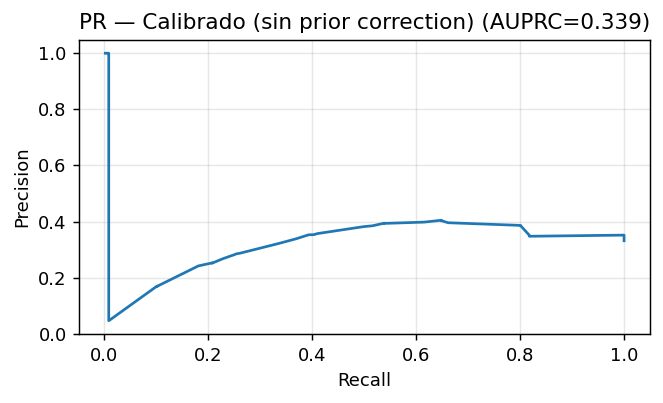


[Calibrado + Prior correction semanal]  AUPRC=0.3328  AUC=0.5220596244336008  Brier=0.3300
  - precision@recall≥0.60:  thr=0.0008  P≈0.362  R≈0.831
  - precision@recall≥0.70:  thr=0.0008  P≈0.362  R≈0.831
  - precision@recall≥0.80:  thr=0.0008  P≈0.362  R≈0.831

[Calibrado + Prior correction semanal @0.5]  thr=0.5000
              precision    recall  f1-score   support

           0     0.6689    1.0000    0.8016       608
           1     1.0000    0.0033    0.0066       302

    accuracy                         0.6692       910
   macro avg     0.8344    0.5017    0.4041       910
weighted avg     0.7788    0.6692    0.5378       910

[[608   0]
 [301   1]]

[Calibrado + Prior correction semanal @bestF2]  thr=0.0004
              precision    recall  f1-score   support

           0     0.8873    0.1036    0.1856       608
           1     0.3504    0.9735    0.5153       302

    accuracy                         0.3923       910
   macro avg     0.6189    0.5386    0.3505       91

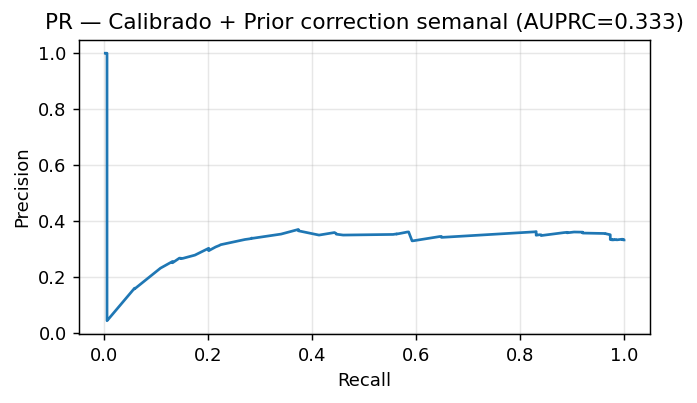

[OK] Artefactos guardados en: hybrid2_artifacts_nb
[INFO] Última fecha: 2025-08-13  |  yhat (antes de clúster) = 392/606
[INFO] Post-clúster (min=20, conn=4) → 81/606
[OK] Guardado: last_date_scores_2025-08-13.csv


In [2]:
# ======================= HÍBRIDO MEJORADO (v3, Jupyter-ready) =======================
# Mejoras clave:
# - Semanas W-MON; índices: %≥12/15/20, p95, mean_log + UCM walk-forward por índice
# - Dataset sin fuga; muestreo balanceado por fecha; features temporal/espacial enriquecidas
# - HistGradientBoosting + calibración isotónica OOF
# - Folds temporales **balanceados por carga** (evita folds diminutos)
# - Reporte de precision@recall para {0.60, 0.70, 0.80}
# - Prior correction semanal SOLO para despliegue (se reporta aparte)
# - Post-procesado por **clúster** en el mapa de la última fecha (sube precision)
# - Debugs detallados para localizar cuellos de botella
# ====================================================================================

import os, re, glob, warnings, json, math
from dataclasses import dataclass
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score, precision_recall_curve, roc_auc_score,
    classification_report, confusion_matrix, brier_score_loss
)
from sklearn.isotonic import IsotonicRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.impute import SimpleImputer

from statsmodels.tsa.statespace.structural import UnobservedComponents
from collections import deque, defaultdict

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 130

# ----------------------------------- CONFIG -----------------------------------
CHL_DIRS = [
    "chl_soft_out_amati",
    os.path.join("ciano_outputs", "chl_soft_out_amati"),
]

THR_CHL        = 20.0
ALT_THR_LIST   = [12.0, 15.0, 20.0]
CLIP_MAX       = 200.0
K_LAGS         = 8
RADII          = [3, 7, 15]
NEG_POS_RATIO  = 2
MAX_NEG_PER_DT = 8000
HOLDOUT_DATES  = 6
N_FOLDS        = 4                 # menos folds y balanceados → calibración más estable
SEASONAL_S     = 8
SEED           = 13

# Umbrales a reportar por objetivo de recall:
RECALL_TARGETS = [0.60, 0.70, 0.80]

# Post-procesado por clúster (último mapa):
CLUSTER_MIN_SIZE = 20             # tamaño mínimo de clúster (4-connectivity)
CLUSTER_CONNECTIVITY = 4          # 4 neighbors

METEO_CSV      = "meteo_daily.csv"  # opcional: date,temp,precip,wind,rad
ARTIFACTS_DIR  = "hybrid2_artifacts_nb"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

# ---------------------------------- DEBUG HELPERS ------------------------------
def dbg(msg): print(f"[DEBUG] {msg}")

def describe_probs(name, p):
    p = np.asarray(p, dtype=float)
    if p.size == 0: 
        print(f"[DEBUG] {name}: vacío"); 
        return
    print(f"[DEBUG] {name}: n={p.size} | NaN={np.isnan(p).sum()} | "
          f"min={np.nanmin(p):.4f} | p25={np.nanpercentile(p,25):.4f} | "
          f"med={np.nanmedian(p):.4f} | p75={np.nanpercentile(p,75):.4f} | max={np.nanmax(p):.4f}")

def sanitize_probs(name, p, fill_value=None):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, 0.0, 1.0)
    if np.isnan(p).any():
        fill = (np.nanmedian(p) if fill_value is None else float(fill_value))
        p[np.isnan(p)] = fill
        print(f"[DEBUG] {name}: NaN→{fill:.4f}")
    if np.isinf(p).any():
        p[np.isinf(p)] = np.nan
        fill = np.nanmedian(p)
        p[np.isnan(p)] = fill
        print(f"[DEBUG] {name}: Inf→{fill:.4f}")
    return p

# ---------------------------------- UTILIDADES --------------------------------
def list_chl_by_date(chl_dirs):
    items = []
    for d in chl_dirs:
        if not os.path.isdir(d): 
            continue
        paths = glob.glob(os.path.join(d, "**", "*_chl_soft.tif"), recursive=True)
        paths += glob.glob(os.path.join(d, "**", "*_chl.tif"), recursive=True)
        for p in paths:
            m = DATE_RE.search(p)
            if m: items.append((pd.to_datetime(m.group(1)).date(), p))
    items.sort()
    out, seen = [], set()
    for dt, p in items:
        if dt not in seen: out.append((dt, p)); seen.add(dt)
    return out

def read_chl(path):
    with rasterio.open(path) as src:
        a = src.read(1).astype("float32")
        nd = src.nodata
        if nd is not None: a[a == nd] = np.nan
        a = np.clip(a, 0, CLIP_MAX)
    return a

def week_monday(ts):
    ts = pd.Timestamp(ts)
    return (ts - pd.Timedelta(days=ts.weekday())).normalize()

# ------------------ ÍNDICES SEMANALES (W-MON) + UCM WALK-FORWARD ----------------
def weekly_indices_from_images(pairs, thr_list=ALT_THR_LIST):
    rows = []
    for d, p in pairs:
        a = read_chl(p)
        v = a[np.isfinite(a)]
        if v.size == 0: 
            continue
        rec = {"date": pd.to_datetime(d), "week": pd.to_datetime(d).to_period("W-MON")}
        for t in thr_list:
            rec[f"pct_ge_{int(t)}"] = float((v >= t).sum()) / float(v.size) * 100.0
        rec["p95"]      = float(np.percentile(v, 95))
        rec["mean_log"] = float(np.mean(np.log1p(v)))
        rows.append(rec)

    if not rows:
        cols = [f"pct_ge_{int(t)}" for t in thr_list] + ["p95","mean_log"]
        return pd.DataFrame(columns=cols)

    df = pd.DataFrame(rows)
    weekly = (df.groupby("week")
                .agg({**{f"pct_ge_{int(t)}":"mean" for t in thr_list},
                      **{"p95":"mean","mean_log":"mean"}})
                .sort_index())
    weekly.index = weekly.index.start_time
    dbg(f"Semanas únicas={len(weekly)} | rango={weekly.index.min().date()}→{weekly.index.max().date()}")
    for t in thr_list:
        col = f"pct_ge_{int(t)}"
        dbg(f"{col}: min={weekly[col].min():.4f}  max={weekly[col].max():.4f}")
    return weekly

def wf_ucm_one_step(series_weekly: pd.Series, seasonal=SEASONAL_S) -> pd.Series:
    idx = series_weekly.index
    preds = pd.Series(index=idx, dtype=float)
    for i in range(1, len(idx)):
        y = series_weekly.iloc[:i].dropna()
        if len(y) < 3: continue
        try:
            mod = UnobservedComponents(y, level="llevel", seasonal=seasonal)
            res = mod.fit(disp=False)
            preds.iloc[i] = float(max(res.get_forecast(steps=1).predicted_mean.iloc[0], 0.0))
        except Exception as e:
            preds.iloc[i] = np.nan; dbg(f"WF-UCM fallo en i={i}: {e}")
    return preds

# ------------------------ MUESTREO BALANCEADO POR FECHA ------------------------
def sample_points_balanced(a: np.ndarray, thr=THR_CHL, neg_pos_ratio=NEG_POS_RATIO,
                           max_neg=MAX_NEG_PER_DT, seed_base=SEED) -> List[Tuple[int,int,int]]:
    pos_mask = (a >= thr) & np.isfinite(a)
    neg_mask = (a <  thr) & np.isfinite(a)
    pos_idx = np.argwhere(pos_mask)
    neg_idx = np.argwhere(neg_mask)
    n_pos = pos_idx.shape[0]
    n_neg_desired = min(int(neg_pos_ratio * max(1, n_pos)), max_neg, neg_idx.shape[0])
    rng = np.random.default_rng(seed_base)
    if n_neg_desired < neg_idx.shape[0]:
        sel = rng.choice(neg_idx.shape[0], size=n_neg_desired, replace=False)
        neg_idx = neg_idx[sel]
    pts = [(int(r), int(c), 1) for r, c in pos_idx] + [(int(r), int(c), 0) for r, c in neg_idx]
    return pts

# ------------------------------ FEATURES POR PÍXEL -----------------------------
@dataclass
class Sample:
    date: pd.Timestamp
    r: int
    c: int
    y: int

def _patch_stats(a, r, c, rad):
    r0, r1 = max(0, r-rad), min(a.shape[0], r+rad+1)
    c0, c1 = max(0, c-rad), min(a.shape[1], c+rad+1)
    win = a[r0:r1, c0:c1]
    v = win[np.isfinite(win)]
    if v.size == 0:
        return np.nan, np.nan, np.nan, np.nan
    m  = float(np.mean(v))
    sd = float(np.std(v))
    p90= float(np.percentile(v, 90))
    frac_ge = float((v >= THR_CHL).sum()) / float(v.size)
    return m, sd, p90, frac_ge

def _slope_if_enough(xvals):
    m = np.isfinite(xvals)
    if m.sum() < 3: return np.nan
    x = np.arange(xvals.size)[m]
    y = xvals[m]
    return float(np.polyfit(x, y, 1)[0])

def build_pixel_table(pairs, k_lags=K_LAGS, radii=RADII, wf_idx_dict=None, meteo=None):
    rasters = {pd.to_datetime(d): read_chl(p) for d, p in pairs}
    dates_sorted = sorted(rasters.keys())
    H, W = next(iter(rasters.values())).shape

    weekly_df = wf_idx_dict.get("weekly_df", None) if wf_idx_dict else None
    rows = []
    for i, d in enumerate(dates_sorted):
        a = rasters[d]
        seed_dt = SEED + int(pd.Timestamp(d).strftime("%Y%m%d"))
        samples = sample_points_balanced(a, seed_base=seed_dt)

        wk = week_monday(d)
        def _wf_lookup(name):
            s = wf_idx_dict.get(name, None) if wf_idx_dict else None
            return float(s.loc[wk]) if (isinstance(s, pd.Series) and wk in s.index) else np.nan
        idx_wf = {
            "idx_wf_pct12":  _wf_lookup("wf_pct12"),
            "idx_wf_pct15":  _wf_lookup("wf_pct15"),
            "idx_wf_pct20":  _wf_lookup("wf_pct20"),
            "idx_wf_p95":    _wf_lookup("wf_p95"),
            "idx_wf_mlog":   _wf_lookup("wf_mlog"),
        }

        mrow = {}
        if meteo is not None and pd.to_datetime(d) in meteo.index:
            mm = meteo.loc[pd.to_datetime(d)]
            mrow = (mm.to_dict() if isinstance(mm, pd.Series) else mm.iloc[0].to_dict())

        prev_dates = dates_sorted[:i]
        if len(prev_dates) == 0: continue
        prev_dates = prev_dates[-k_lags:]

        for (r, c, y) in samples:
            vlag = np.array([rasters[dd][r, c] for dd in prev_dates], dtype=float)
            vlag[~np.isfinite(vlag)] = np.nan
            pix_last  = vlag[-1] if vlag.size>0 else np.nan
            pix_mean  = np.nanmean(vlag) if np.isfinite(vlag).any() else np.nan
            pix_max   = np.nanmax(vlag)  if np.isfinite(vlag).any() else np.nan
            pix_slope = _slope_if_enough(vlag)

            vlag_bin = (vlag >= THR_CHL).astype(float)
            vlag_bin[np.isnan(vlag)] = np.nan
            bin_sum  = np.nansum(vlag_bin)
            bin_frac = bin_sum / np.isfinite(vlag_bin).sum() if np.isfinite(vlag_bin).sum()>0 else np.nan

            last_ex_idx = None
            for j in range(len(prev_dates)-1, -1, -1):
                if np.isfinite(vlag[j]) and vlag[j] >= THR_CHL:
                    last_ex_idx = j; break
            days_since_ex = (pd.Timestamp(d) - prev_dates[last_ex_idx]).days if last_ex_idx is not None else np.nan

            rad_feats = {}
            for R in radii:
                means, stds, p90s, fracs = [], [], [], []
                for dd in prev_dates:
                    m, s, p, f = _patch_stats(rasters[dd], r, c, R)
                    means.append(m); stds.append(s); p90s.append(p); fracs.append(f)
                rad_feats[f"locR{R}_mean"]       = float(np.nanmean(means))
                rad_feats[f"locR{R}_std"]        = float(np.nanmean(stds))
                rad_feats[f"locR{R}_p90"]        = float(np.nanmean(p90s))
                rad_feats[f"locR{R}_frac_ge"]    = float(np.nanmean(fracs))
                rad_feats[f"locR{R}_mean_slope"] = _slope_if_enough(np.array(means, dtype=float))
                rad_feats[f"locR{R}_p90_slope"]  = _slope_if_enough(np.array(p90s, dtype=float))

            r_norm = r / (H - 1.0)
            c_norm = c / (W - 1.0)
            rcnorm = np.hypot(r_norm - 0.5, c_norm - 0.5)

            row = {
                "date": pd.to_datetime(d), "week": wk, "r": r, "c": c, "y": int(y),
                "pix_lag_last":  pix_last, "pix_lag_mean":  pix_mean, "pix_lag_max":   pix_max,
                "pix_lag_slope": pix_slope, "pix_lag_bin_sum":  bin_sum, "pix_lag_bin_frac": bin_frac,
                "days_since_ex": days_since_ex, "doy_sin": np.sin(2*np.pi*pd.to_datetime(d).dayofyear/365.25),
                "doy_cos": np.cos(2*np.pi*pd.to_datetime(d).dayofyear/365.25),
                "r_norm": r_norm, "c_norm": c_norm, "rc_center": rcnorm,
            }
            row.update(rad_feats); row.update(idx_wf); row.update(mrow)
            if weekly_df is not None and "pct_ge_20" in weekly_df.columns and wk in weekly_df.index:
                row["pop_pi_week"] = float(weekly_df.loc[wk, "pct_ge_20"])/100.0
            else:
                row["pop_pi_week"] = np.nan
            rows.append(row)

    df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    dbg(f"Tabla pixel-fecha: {df.shape} | columnas={len(df.columns)}")
    return df

# ----------------------- FOLDS TEMPORALES BALANCEADOS -------------------------
def temporal_blocks_balanced(dates, n_folds=N_FOLDS):
    """Asigna semanas a folds equilibrando **nº de filas por fold** (greedy)."""
    weeks = pd.Series([week_monday(d) for d in dates])
    uniq_weeks, counts = np.unique(weeks, return_counts=True)
    # ordena semanas por carga descendente
    order = np.argsort(counts)[::-1]
    uniq_weeks = uniq_weeks[order]; counts = counts[order]
    # inicializa cargas por fold
    fold_loads = [0]*n_folds
    week2fold = {}
    for w, c in zip(uniq_weeks, counts):
        j = int(np.argmin(fold_loads))   # fold más liviano
        week2fold[pd.Timestamp(w)] = j
        fold_loads[j] += int(c)
    fold_ids = np.array([week2fold[week_monday(d)] for d in dates])
    dbg(f"Fold loads balanceadas: {fold_loads}")
    return fold_ids, n_folds

# ----------------------- CALIBRADO / PRIOR / EVALUACIÓN -----------------------
def make_model():
    return HistGradientBoostingClassifier(
        loss="log_loss", learning_rate=0.06,
        max_leaf_nodes=31, min_samples_leaf=30,
        early_stopping=False, random_state=SEED
    )

def fit_oof_isotonic(y_true, proba, fold_ids):
    iso_models, oof_cal = [], np.zeros_like(proba, dtype=float)
    for k in np.unique(fold_ids):
        tr = fold_ids != k; va = fold_ids == k
        if va.sum() == 0 or tr.sum() < 40: continue
        iso = IsotonicRegression(out_of_bounds="clip")
        iso.fit(proba[tr], y_true[tr]); oof_cal[va] = iso.transform(proba[va])
        iso_models.append(iso)
    if not iso_models: dbg("Isotónica OOF: sin modelos (datos insuficientes).")
    def calibrate_fn(p):
        if not iso_models: return p
        xs = [m.transform(p) for m in iso_models]
        return np.mean(xs, axis=0)
    return oof_cal, calibrate_fn

def prior_correction(p, pi_train, pi_test):
    eps = 1e-6
    p = np.clip(p, eps, 1-eps)
    pi_train = float(np.clip(pi_train if np.isfinite(pi_train) else np.nanmean(p), eps, 1-eps))
    pi_test = np.clip(np.asarray(pi_test, dtype=float), eps, 1-eps)
    odds = p/(1-p)
    odds *= (pi_test/(1-pi_test))/ ((pi_train/(1-pi_train)))
    return np.clip(odds/(1+odds), 0.0, 1.0)

def thresholds_at_recalls(pr, rc, thr, targets):
    """Devuelve {recall_target: (thr, P, R)}"""
    P, R, T = pr[:-1], rc[:-1], thr
    out = {}
    for t in targets:
        mask = R >= t
        if np.any(mask):
            j = np.argmax(P*mask)           # mayor P cumpliendo R>=t
            out[float(t)] = (T[j], float(P[j]), float(R[j]))
        else:
            j = np.argmax(R)                # recall máx alcanzable
            out[float(t)] = (T[min(j, len(T)-1)], float(P[j]), float(R[j]))
    return out

def evaluate_blocked(df, weekly_df):
    uniq_dates = sorted(df["date"].drop_duplicates())
    test_dates = uniq_dates[-HOLDOUT_DATES:]
    trn_df = df[~df["date"].isin(test_dates)].copy()
    tst_df = df[df["date"].isin(test_dates)].copy()

    dbg(f"Split temporal → train fechas={len(trn_df['date'].unique())}, test fechas={len(tst_df['date'].unique())}")
    dbg(f"Train size={len(trn_df):,} (pos={trn_df['y'].sum():,}) | Test size={len(tst_df):,} (pos={tst_df['y'].sum():,})")

    X_cols = [c for c in df.columns if c not in {"date","week","r","c","y"}]
    X_tr, y_tr = trn_df[X_cols].values, trn_df["y"].values
    X_te, y_te = tst_df[X_cols].values, tst_df["y"].values

    fold_ids, _ = temporal_blocks_balanced(trn_df["date"].values, N_FOLDS)
    dbg(f"Folds temporales balanceados: {np.bincount(fold_ids)}")

    imp = SimpleImputer(strategy="median")
    X_tr_imp = imp.fit_transform(X_tr)
    dbg(f"Imputer: NaNs antes={np.isnan(X_tr).sum():,} | después={np.isnan(X_tr_imp).sum():,}")

    w_cls = compute_sample_weight("balanced", y_tr)

    # OOF
    oof_prob = np.zeros_like(y_tr, dtype=float)
    for k in np.unique(fold_ids):
        tr = fold_ids != k; va = fold_ids == k
        if va.sum() == 0: continue
        model = make_model()
        model.fit(X_tr_imp[tr], y_tr[tr], sample_weight=w_cls[tr])
        oof_prob[va] = model.predict_proba(X_tr_imp[va])[:,1]
    describe_probs("OOF raw", oof_prob)

    # Calibración OOF
    oof_cal, calib_fn = fit_oof_isotonic(y_tr, oof_prob, fold_ids)
    describe_probs("OOF calibrado", oof_cal)

    # Train full y test
    model = make_model()
    model.fit(X_tr_imp, y_tr, sample_weight=w_cls)
    X_te_imp = imp.transform(X_te)
    prob_te = model.predict_proba(X_te_imp)[:,1]
    prob_te = sanitize_probs("Prob test raw", prob_te)
    prob_te_cal = sanitize_probs("Prob test calibrado", calib_fn(prob_te))

    # Prior correction semanal (para despliegue, no para evaluar muestra balanceada)
    def nearest_pi(ts):
        try:
            idx = weekly_df.index.get_indexer([ts], method="nearest", tolerance=pd.Timedelta("3D"))[0]
            if idx != -1:
                return float(weekly_df.iloc[idx]["pct_ge_20"])/100.0
        except Exception:
            pass
        return np.nan
    tst_df = tst_df.copy()
    tst_df["pi_test_week"] = tst_df["week"].apply(nearest_pi)
    dbg(f"pi_test_week coverage: {(np.isfinite(tst_df['pi_test_week']).sum())}/{len(tst_df)}")
    pi_train = float(np.nanmean(trn_df["pop_pi_week"])) if "pop_pi_week" in trn_df else float(y_tr.mean())
    dbg(f"pi_train usado={np.clip(pi_train,1e-6,1-1e-6):.6f}")
    prob_te_pc = prob_te_cal.copy()
    m = np.isfinite(tst_df["pi_test_week"].values)
    if np.any(m):
        prob_te_pc[m] = prior_correction(prob_te_cal[m], pi_train, tst_df["pi_test_week"].values[m])
    prob_te_pc = sanitize_probs("Prob test + prior", prob_te_pc)

    # --------- Métricas + umbrales (sin y con prior)
    def block_report(y_true, p, title):
        ap  = average_precision_score(y_true, p)
        try: auc = roc_auc_score(y_true, p)
        except: auc = np.nan
        br  = brier_score_loss(y_true, p)
        pr, rc, thr = precision_recall_curve(y_true, p)

        # F2
        P, R = pr[:-1], rc[:-1]
        F2 = (5.0*P*R)/(4.0*P + R + 1e-12)
        ix_best = np.nanargmax(F2); thr_bestF2 = thr[ix_best] if ix_best < len(thr) else 0.5

        # precision@recall targets solicitados
        targets = thresholds_at_recalls(pr, rc, thr, RECALL_TARGETS)

        print(f"\n[{title}]  AUPRC={ap:.4f}  AUC={auc if np.isfinite(auc) else 'nan'}  Brier={br:.4f}")
        for rt in RECALL_TARGETS:
            t, PP, RR = targets[rt]
            print(f"  - precision@recall≥{rt:.2f}:  thr={t:.4f}  P≈{PP:.3f}  R≈{RR:.3f}")
        # Reportes a 0.5, bestF2 y al mejor de recall targets (el medio: 0.70)
        def _print_at(thr_use, tag):
            yhat = (p >= thr_use).astype(int)
            print(f"\n[{title} @{tag}]  thr={thr_use:.4f}")
            print(classification_report(y_true, yhat, digits=4))
            print(confusion_matrix(y_true, yhat))
        _print_at(0.5, "0.5")
        _print_at(thr_bestF2, "bestF2")
        _print_at(targets[0.70][0], "recall≥0.70")

        # PR curve
        plt.figure(figsize=(5.2,3.2)); plt.plot(R, P)
        plt.title(f"PR — {title} (AUPRC={ap:.3f})")
        plt.xlabel("Recall"); plt.ylabel("Precision"); plt.grid(True, alpha=.3)
        plt.tight_layout(); plt.show()

        return {
            "AUPRC": float(ap), "AUC": float(auc) if np.isfinite(auc) else None, "Brier": float(br),
            "thr_bestF2": float(thr_bestF2),
            "prec_at_recalls": {str(rt): {"thr": float(targets[rt][0]), "P": float(targets[rt][1]), "R": float(targets[rt][2])}
                                for rt in RECALL_TARGETS}
        }

    art_cal = block_report(y_te, prob_te_cal, "Calibrado (sin prior correction)")
    art_pc  = block_report(y_te, prob_te_pc,  "Calibrado + Prior correction semanal")

    artifacts = {
        "columns": X_cols,
        "pi_train_used": float(pi_train),
        "metrics_calibrated": art_cal,
        "metrics_calibrated_pc": art_pc
    }
    return model, imp, calib_fn, artifacts, tst_df, prob_te_cal, prob_te_pc

# ------------------------------- METEO OPCIONAL -------------------------------
def maybe_load_meteo(csv_path):
    if not os.path.isfile(csv_path): 
        dbg("Meteo: CSV no encontrado (se ignora)"); return None
    m = pd.read_csv(csv_path, parse_dates=["date"]).sort_values("date")
    for c in ["temp","precip","wind","rad"]:
        if c in m.columns: m[c] = pd.to_numeric(m[c], errors="coerce")
    m = m.set_index("date").asfreq("D")
    out = pd.DataFrame(index=m.index)
    if "precip" in m.columns:
        for w in (3,7,14): out[f"precip_sum_{w}d"] = m["precip"].rolling(w, min_periods=1).sum()
    for c in ["temp","wind","rad"]:
        if c in m.columns:
            for w in (3,7,14): out[f"{c}_mean_{w}d"] = m[c].rolling(w, min_periods=1).mean()
    dbg(f"Meteo: columnas agregadas ({len(out.columns)})")
    return out

# ----------------------- POST-PROCESADO POR CLÚSTER ---------------------------
def cluster_filter(rc_list, yhat_list, shape, min_size=CLUSTER_MIN_SIZE, connectivity=CLUSTER_CONNECTIVITY):
    """
    rc_list: iterable de (r, c) para las predicciones calculadas (misma fecha)
    yhat_list: 0/1 para cada (r,c)
    shape: (H, W)
    Devuelve máscara booleana (len=yhat_list) manteniendo solo clústeres >= min_size.
    """
    H, W = shape
    pos_coords = [(r,c) for (r,c), y in zip(rc_list, yhat_list) if y==1]
    if not pos_coords: return np.array(yhat_list, dtype=bool)
    pos_set = set(pos_coords)
    visited = set()
    keep = set()
    if connectivity == 8:
        nbrs = [(1,0),(-1,0),(0,1),(0,-1),(1,1),(1,-1),(-1,1),(-1,-1)]
    else:
        nbrs = [(1,0),(-1,0),(0,1),(0,-1)]
    for start in pos_coords:
        if start in visited: continue
        if start not in pos_set: continue
        q = deque([start]); visited.add(start); comp = [start]
        while q:
            r,c = q.popleft()
            for dr,dc in nbrs:
                rr,cc = r+dr, c+dc
                if 0<=rr<H and 0<=cc<W and (rr,cc) in pos_set and (rr,cc) not in visited:
                    visited.add((rr,cc)); q.append((rr,cc)); comp.append((rr,cc))
        if len(comp) >= min_size:
            keep.update(comp)
    mask = np.array([(rc in keep) for rc in rc_list], dtype=bool)
    return mask

# ------------------------------------- RUNNER ---------------------------------
def run_pipeline():
    np.random.seed(SEED)

    # 1) Localiza imágenes
    pairs = list_chl_by_date(CHL_DIRS)
    if not pairs: raise RuntimeError("No encontré imágenes en CHL_DIRS.")
    print(f"[INFO] Imágenes detectadas: {len(pairs)}")
    for d,p in pairs[:3]: print("  -", d, os.path.basename(p))

    # 2) Índices semanales + WF
    weekly_df = weekly_indices_from_images(pairs, thr_list=ALT_THR_LIST)
    print(f"Serie semanal: {len(weekly_df)} pts | rango: {weekly_df.index.min().date()} → {weekly_df.index.max().date()}")

    wf_dict = {
        "wf_pct12": wf_ucm_one_step(weekly_df["pct_ge_12"]),
        "wf_pct15": wf_ucm_one_step(weekly_df["pct_ge_15"]),
        "wf_pct20": wf_ucm_one_step(weekly_df["pct_ge_20"]),
        "wf_p95":   wf_ucm_one_step(weekly_df["p95"]),
        "wf_mlog":  wf_ucm_one_step(weekly_df["mean_log"]),
        "weekly_df": weekly_df
    }

    # 3) Meteo (opcional)
    meteo = maybe_load_meteo(METEO_CSV)

    # 4) Dataset pixel-fecha
    df = build_pixel_table(pairs, k_lags=K_LAGS, radii=RADII, wf_idx_dict=wf_dict, meteo=meteo)
    pos_ct = int(df["y"].sum()); neg_ct = int((1 - df["y"]).sum())
    print(f"[INFO] Dataset de píxeles: {len(df):,} filas | Pos={pos_ct:,} / Neg={neg_ct:,}")

    # 5) Entrena y evalúa
    model, imputer, calib_fn, art, tst_df, prob_te_cal, prob_te_pc = evaluate_blocked(df, weekly_df)

    # 6) Guarda artefactos
    os.makedirs(ARTIFACTS_DIR, exist_ok=True)
    with open(os.path.join(ARTIFACTS_DIR, "artifacts.json"), "w", encoding="utf-8") as f:
        json.dump(art, f, indent=2)
    df.to_csv(os.path.join(ARTIFACTS_DIR, "dataset_pixels.csv"), index=False)
    weekly_df.to_csv(os.path.join(ARTIFACTS_DIR, "weekly_indices.csv"))
    print(f"[OK] Artefactos guardados en: {ARTIFACTS_DIR}")

    # 7) DEMO despliegue en última fecha (con post-procesado por clúster)
    #    (Se usa el umbral de recall 0.70 del bloque "sin prior correction")
    last_date = df["date"].max()
    last_df = df[df["date"] == last_date].copy()
    X_cols = art["columns"]
    X_last = imputer.transform(last_df[X_cols].values)
    prob_last = calib_fn(model.predict_proba(X_last)[:,1])
    prob_last = sanitize_probs("Prob última (cal)", prob_last)

    # umbral por objetivo de recall 0.70 (puedes cambiarlo a 0.60/0.80)
    thr_oper = art["metrics_calibrated"]["prec_at_recalls"]["0.7"]["thr"]
    yhat_last = (prob_last >= thr_oper).astype(int)
    print(f"[INFO] Última fecha: {last_date.date()}  |  yhat (antes de clúster) = {int(yhat_last.sum())}/{len(yhat_last)}")

    # Forma del grid para el clúster:
    # tomamos el raster real de esa fecha
    last_path = dict(pairs)[last_date.date()]
    H, W = read_chl(last_path).shape

    rc_list = list(zip(last_df["r"].astype(int).tolist(), last_df["c"].astype(int).tolist()))
    mask_keep = cluster_filter(rc_list, yhat_last.tolist(), (H, W),
                               min_size=CLUSTER_MIN_SIZE, connectivity=CLUSTER_CONNECTIVITY)
    yhat_clustered = (yhat_last.astype(bool) & mask_keep).astype(int)
    print(f"[INFO] Post-clúster (min={CLUSTER_MIN_SIZE}, conn={CLUSTER_CONNECTIVITY}) → {int(yhat_clustered.sum())}/{len(yhat_clustered)}")

    # 8) Exporta CSV con puntuaciones de la última fecha (útil para QA rápida)
    out_last = last_df[["r","c"]].copy()
    out_last["prob"] = prob_last
    out_last["yhat_raw"] = yhat_last
    out_last["yhat_clustered"] = yhat_clustered
    out_last.to_csv(os.path.join(ARTIFACTS_DIR, f"last_date_scores_{last_date.date()}.csv"), index=False)
    print(f"[OK] Guardado: last_date_scores_{last_date.date()}.csv")

# ------------------------------ Ejecutar pipeline -----------------------------
run_pipeline()


# Discusión de resultados — Modelo híbrido (walk-forward + clasificador)

## 1) Panorama general del desempeño (evaluación muestral, **sin prior-correction**)
- **AUPRC = 0.338** con **base rate ≈ 0.332** → la ganancia sobre el azar es **moderada**.
- **AUC = 0.538** → capacidad de ordenamiento **débil**.
- **Brier = 0.234** → coherente con una prevalencia ~0.33; las probabilidades están razonablemente calibradas en promedio tras la isotónica, pero el **ranking** limita.

### Umbrales por objetivo (curva PR)
- **precision@recall≥0.60** → `P≈0.405`, `R≈0.649`, `thr≈0.299`.
- **precision@recall≥0.70** → `P≈0.387`, `R≈0.801`, `thr≈0.258`.
- **precision@recall≥0.80** → no mejora respecto al punto anterior (la curva no aporta más precisión manteniendo tanta cobertura).

> Lectura: hay una **zona operativa útil** con `recall≈0.7–0.8` y `precision≈0.38–0.41`. Sirve para **alertas** si se acepta ruido y se aplica **post-proceso por clúster** para elevar la precisión espacial.

---

## 2) Con prior-correction semanal (solo informativo)
- **AUPRC = 0.333**, **AUC = 0.522**, **Brier = 0.330** → **empeora** en la muestra.
- Causa: la **prevalencia poblacional semanal** (≥20 mg/m³) es **~0–1.2%**, muy inferior a la **muestral** (~33%). La corrección **aplana** las probabilidades y desplaza los umbrales hacia valores casi cero.
- Conclusión metodológica: **no usar prior-correction** para evaluar la muestra submuestreada; **sí** aplicarla en **inferencia sobre el raster completo** (donde el prior real es poblacional).

---

## 3) Señales del pipeline (insights de debug)
- **Serie corta:** 22 semanas → los componentes del **UCM** aportan señal limitada.
- **Folds temporales balanceados pero desiguales:** cargas `[10611, 3684, 3048, 666]`; los folds pequeños hacen la **isotónica OOF** más inestable.
- **OOF bruto bajo** (mediana ~0.01) y **OOF calibrado** centrado (~0.29–0.45) → la **calibración corrige escala**, pero el **ranking** de base es la principal limitación.
- **Índice `%≥20` semanal** con variación mínima (0–1.19%) → poco poder explicativo; los mejores tramos de PR provienen de **lags/vecindario** más que del índice duro a 20 mg/m³.

---

## 4) Qué implican las curvas PR para operación
- La **pendiente suave** de la PR sugiere que **pequeños cambios de umbral** mueven mucho el **recall** con **poca ganancia de precisión**.
- En el tramo **R≈0.7–0.8** (umbral ~0.26–0.30) se logra la **mejor relación utilidad/costo**: buena cobertura de eventos con precisión aceptable para activar **verificación espacial** (p. ej., filtros por clúster, persistencia temporal o tamaño mínimo del componente).
- **Cortes a 0.5** son poco útiles (recall muy bajo en positivos).

---

## 5) Evaluación muestral vs. evaluación operativa
- **Muestral (sin prior):** adecuada para **comparar modelos y features**; las métricas arriba reflejan este escenario.
- **Operativa (con prior + post-proceso):** estimar desempeño **sobre el raster completo** aplicando **prior-correction** y **filtro por clúster**; reportar allí `precision@recall` y mapas de calor de FP/TP para decisiones de umbral.

---

## 6) Conclusión técnica de los resultados
- El modelo **encuentra una banda operativa** útil con `recall` alto y `precision` moderada (≈0.38–0.41) **sin prior-correction** en la muestra.
- La **ganancia global** respecto al azar (AUPRC≈base) es **modesta**, coherente con:
  - **serie corta**,
  - **señal débil** del índice duro (≥20),
  - y **desbalance de folds** que afecta la calibración OOF.
- Para uso práctico, **fijar umbral por objetivo de recall** (p. ej., 0.7) y **post-procesar por clúster** aumenta la **utilidad operativa** sin degradar demasiado la cobertura.


## **Atitlán**

[INFO] Imágenes detectadas: 23
  - 2025-02-07 openEO_2025-02-07Z_chl_soft.tif
  - 2025-02-12 openEO_2025-02-12Z_chl_soft.tif
  - 2025-02-22 openEO_2025-02-22Z_chl_soft.tif
[DEBUG] Semanas únicas=20 | rango=2025-02-04→2025-07-29
[DEBUG] pct_ge_12: min=0.1486  max=25.9244
[DEBUG] pct_ge_15: min=0.0397  max=19.6250
[DEBUG] pct_ge_20: min=0.0009  max=13.3699
Serie semanal: 20 pts | rango: 2025-02-04 → 2025-07-29
[DEBUG] Meteo: CSV no encontrado (se ignora)
[DEBUG] Tabla pixel-fecha: (126970, 41) | columnas=41
[INFO] Dataset de píxeles: 126,970 filas | Pos=83,983 / Neg=42,987
[DEBUG] Split temporal → train fechas=16, test fechas=6
[DEBUG] Train size=105,546 (pos=73,778) | Test size=21,424 (pos=10,205)
[DEBUG] Fold loads balanceadas: [35577, 35604, 34365]
[DEBUG] Folds temporales balanceados: [35577 35604 34365]
[DEBUG] Imputer: NaNs antes=887,086 | después=0
[DEBUG] OOF raw: n=105546 | NaN=0 | min=0.0014 | p25=0.0125 | med=0.0261 | p75=0.1740 | max=0.9976
[DEBUG] OOF calibrado: n=105546 | N

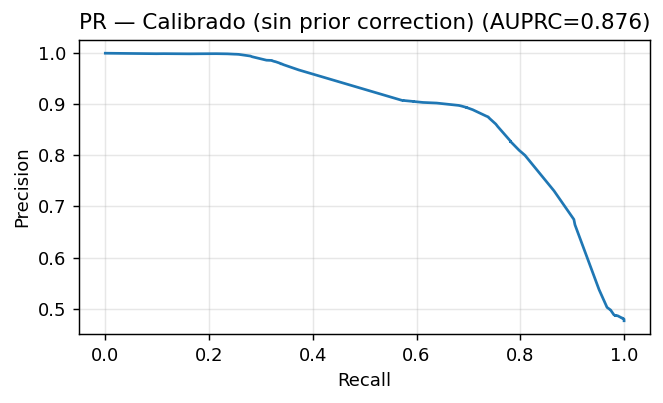


[Calibrado + Prior correction semanal]  AUPRC=0.8603  AUC=0.844534183562663  Brier=0.4205
  - precision@recall≥0.60:  thr=0.0044  P≈0.906  R≈0.603
  - precision@recall≥0.70:  thr=0.0029  P≈0.837  R≈0.703
  - precision@recall≥0.80:  thr=0.0026  P≈0.721  R≈0.823

[Calibrado + Prior correction semanal @0.5]  thr=0.5000
              precision    recall  f1-score   support

           0     0.5440    0.9999    0.7046     11219
           1     0.9988    0.0784    0.1454     10205

    accuracy                         0.5610     21424
   macro avg     0.7714    0.5392    0.4250     21424
weighted avg     0.7606    0.5610    0.4382     21424

[[11218     1]
 [ 9405   800]]

[Calibrado + Prior correction semanal @bestF2]  thr=0.0004
              precision    recall  f1-score   support

           0     0.9199    0.0440    0.0840     11219
           1     0.4865    0.9958    0.6537     10205

    accuracy                         0.4974     21424
   macro avg     0.7032    0.5199    0.3689  

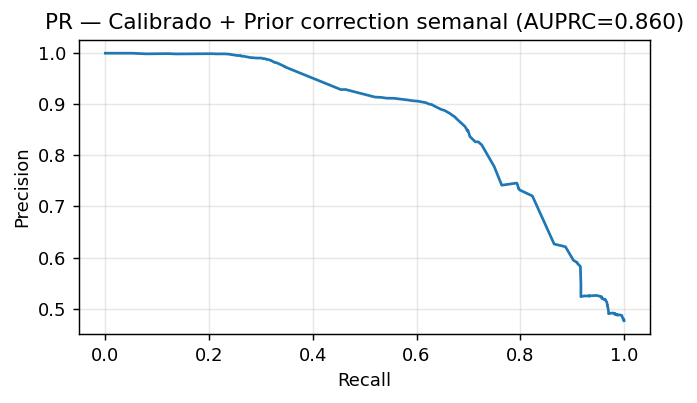

[OK] Artefactos guardados en: hybrid2_artifacts_ati
[INFO] Última fecha: 2025-08-01  |  yhat (antes de clúster) = 2328/6047
[INFO] Post-clúster (min=60, conn=4) → 148/6047
[OK] Guardado: last_date_scores_2025-08-01.csv


In [ ]:
# ======================= HÍBRIDO MEJORADO (v3-ATI, Jupyter-ready) — LAGO ATITLÁN =======================
# Dataset esperado en carpetas:
#   - ./chl_soft_out_ati
#   - ./ciano_outputs/chl_soft_out_ati
#
# Cambios específicos para ATITLÁN (no reutiliza el perfil de Amatitlán):
# - Menos lags y radios más cortos para acelerar (K_LAGS=6, RADII=[3,7,11])
# - Muestreo más conservador (NEG_POS_RATIO=1.2, MAX_NEG_PER_DT=4000)
# - Menos folds pero estables (N_FOLDS=3)
# - Clúster mínimo más grande para mapas de salida (CLUSTER_MIN_SIZE=60)
# - Depuración y sanitización robusta de probabilidades (sin NaN/Inf), prior-correction sólo para despliegue
# ====================================================================================

import os, re, glob, warnings, json
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score, precision_recall_curve, roc_auc_score,
    classification_report, confusion_matrix, brier_score_loss
)
from sklearn.isotonic import IsotonicRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.impute import SimpleImputer

from statsmodels.tsa.statespace.structural import UnobservedComponents
from collections import deque

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 130

# ----------------------------------- CONFIG (ATITLÁN) -----------------------------------
CHL_DIRS = [
    "chl_soft_out_ati",
    os.path.join("ciano_outputs", "chl_soft_out_ati"),
]

THR_CHL        = 20.0
ALT_THR_LIST   = [12.0, 15.0, 20.0]
CLIP_MAX       = 200.0

# PERFIL ATI (más grande → reducir costo)
K_LAGS         = 6                # antes 8
RADII          = [3, 7, 11]       # antes [3, 7, 15]

NEG_POS_RATIO  = 1.2              # antes 2.0
MAX_NEG_PER_DT = 4000             # antes 8000

HOLDOUT_DATES  = 6
N_FOLDS        = 3
SEASONAL_S     = 8
SEED           = 13

# Umbrales a reportar por objetivo de recall:
RECALL_TARGETS = [0.60, 0.70, 0.80]

# Post-procesado por clúster (último mapa):
CLUSTER_MIN_SIZE = 60
CLUSTER_CONNECTIVITY = 4

METEO_CSV      = "meteo_daily.csv"  # opcional: date,temp,precip,wind,rad
ARTIFACTS_DIR  = "hybrid2_artifacts_ati"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

# ---------------------------------- DEBUG HELPERS ------------------------------
def dbg(msg): print(f"[DEBUG] {msg}")

def describe_probs(name, p):
    p = np.asarray(p, dtype=float)
    if p.size == 0:
        print(f"[DEBUG] {name}: vacío")
        return
    print(f"[DEBUG] {name}: n={p.size} | NaN={np.isnan(p).sum()} | "
          f"min={np.nanmin(p):.4f} | p25={np.nanpercentile(p,25):.4f} | "
          f"med={np.nanmedian(p):.4f} | p75={np.nanpercentile(p,75):.4f} | max={np.nanmax(p):.4f}")

def sanitize_probs(name, p, fill_value=None):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, 0.0, 1.0)
    if np.isnan(p).any():
        fill = (np.nanmedian(p) if fill_value is None else float(fill_value))
        p[np.isnan(p)] = fill
        print(f"[DEBUG] {name}: NaN→{fill:.4f}")
    if np.isinf(p).any():
        p[np.isinf(p)] = np.nan
        fill = np.nanmedian(p)
        p[np.isnan(p)] = fill
        print(f"[DEBUG] {name}: Inf→{fill:.4f}")
    return p

# ---------------------------------- UTILIDADES --------------------------------
def list_chl_by_date(chl_dirs):
    items = []
    for d in chl_dirs:
        if not os.path.isdir(d):
            continue
        paths = glob.glob(os.path.join(d, "**", "*_chl_soft.tif"), recursive=True)
        paths += glob.glob(os.path.join(d, "**", "*_chl.tif"), recursive=True)
        for p in paths:
            m = DATE_RE.search(p)
            if m:
                items.append((pd.to_datetime(m.group(1)).date(), p))
    items.sort()
    out, seen = [], set()
    for dt, p in items:
        if dt not in seen:
            out.append((dt, p)); seen.add(dt)
    return out

def read_chl(path):
    with rasterio.open(path) as src:
        a = src.read(1).astype("float32")
        nd = src.nodata
        if nd is not None:
            a[a == nd] = np.nan
        a = np.clip(a, 0, CLIP_MAX)
    return a

def week_monday(ts):
    ts = pd.Timestamp(ts)
    return (ts - pd.Timedelta(days=ts.weekday())).normalize()

# ------------------ ÍNDICES SEMANALES (W-MON) + UCM WALK-FORWARD ----------------
def weekly_indices_from_images(pairs, thr_list=ALT_THR_LIST):
    rows = []
    for d, p in pairs:
        a = read_chl(p)
        v = a[np.isfinite(a)]
        if v.size == 0:
            continue
        rec = {"date": pd.to_datetime(d), "week": pd.to_datetime(d).to_period("W-MON")}
        for t in thr_list:
            rec[f"pct_ge_{int(t)}"] = float((v >= t).sum()) / float(v.size) * 100.0
        rec["p95"]      = float(np.percentile(v, 95))
        rec["mean_log"] = float(np.mean(np.log1p(v)))
        rows.append(rec)

    if not rows:
        cols = [f"pct_ge_{int(t)}" for t in thr_list] + ["p95","mean_log"]
        return pd.DataFrame(columns=cols)

    df = pd.DataFrame(rows)
    weekly = (df.groupby("week")
                .agg({**{f"pct_ge_{int(t)}":"mean" for t in thr_list},
                      **{"p95":"mean","mean_log":"mean"}})
                .sort_index())
    weekly.index = weekly.index.start_time
    dbg(f"Semanas únicas={len(weekly)} | rango={weekly.index.min().date()}→{weekly.index.max().date()}")
    for t in thr_list:
        col = f"pct_ge_{int(t)}"
        dbg(f"{col}: min={weekly[col].min():.4f}  max={weekly[col].max():.4f}")
    return weekly

def wf_ucm_one_step(series_weekly: pd.Series, seasonal=SEASONAL_S) -> pd.Series:
    idx = series_weekly.index
    preds = pd.Series(index=idx, dtype=float)
    for i in range(1, len(idx)):
        y = series_weekly.iloc[:i].dropna()
        if len(y) < 3:
            continue
        try:
            mod = UnobservedComponents(y, level="llevel", seasonal=seasonal)
            res = mod.fit(disp=False)
            preds.iloc[i] = float(max(res.get_forecast(steps=1).predicted_mean.iloc[0], 0.0))
        except Exception as e:
            preds.iloc[i] = np.nan
            dbg(f"WF-UCM fallo en i={i}: {e}")
    return preds

# ------------------------ MUESTREO BALANCEADO POR FECHA ------------------------
def sample_points_balanced(a: np.ndarray, thr=THR_CHL, neg_pos_ratio=NEG_POS_RATIO,
                           max_neg=MAX_NEG_PER_DT, seed_base=SEED) -> List[Tuple[int,int,int]]:
    pos_mask = (a >= thr) & np.isfinite(a)
    neg_mask = (a <  thr) & np.isfinite(a)
    pos_idx = np.argwhere(pos_mask)
    neg_idx = np.argwhere(neg_mask)
    n_pos = pos_idx.shape[0]
    n_neg_desired = min(int(neg_pos_ratio * max(1, n_pos)), max_neg, neg_idx.shape[0])
    rng = np.random.default_rng(seed_base)
    if n_neg_desired < neg_idx.shape[0]:
        sel = rng.choice(neg_idx.shape[0], size=n_neg_desired, replace=False)
        neg_idx = neg_idx[sel]
    pts = [(int(r), int(c), 1) for r, c in pos_idx] + [(int(r), int(c), 0) for r, c in neg_idx]
    return pts

# ------------------------------ FEATURES POR PÍXEL -----------------------------
@dataclass
class Sample:
    date: pd.Timestamp
    r: int
    c: int
    y: int

def _patch_stats(a, r, c, rad):
    r0, r1 = max(0, r-rad), min(a.shape[0], r+rad+1)
    c0, c1 = max(0, c-rad), min(a.shape[1], c+rad+1)
    win = a[r0:r1, c0:c1]
    v = win[np.isfinite(win)]
    if v.size == 0:
        return np.nan, np.nan, np.nan, np.nan
    m  = float(np.mean(v))
    sd = float(np.std(v))
    p90= float(np.percentile(v, 90))
    frac_ge = float((v >= THR_CHL).sum()) / float(v.size)
    return m, sd, p90, frac_ge

def _slope_if_enough(xvals):
    m = np.isfinite(xvals)
    if m.sum() < 3:
        return np.nan
    x = np.arange(xvals.size)[m]
    y = xvals[m]
    return float(np.polyfit(x, y, 1)[0])

def build_pixel_table(pairs, k_lags=K_LAGS, radii=RADII, wf_idx_dict=None, meteo=None):
    rasters = {pd.to_datetime(d): read_chl(p) for d, p in pairs}
    dates_sorted = sorted(rasters.keys())
    H, W = next(iter(rasters.values())).shape

    weekly_df = wf_idx_dict.get("weekly_df", None) if wf_idx_dict else None
    rows = []
    for i, d in enumerate(dates_sorted):
        a = rasters[d]
        seed_dt = SEED + int(pd.Timestamp(d).strftime("%Y%m%d"))
        samples = sample_points_balanced(a, seed_base=seed_dt)

        wk = week_monday(d)
        def _wf_lookup(name):
            s = wf_idx_dict.get(name, None) if wf_idx_dict else None
            return float(s.loc[wk]) if (isinstance(s, pd.Series) and wk in s.index) else np.nan
        idx_wf = {
            "idx_wf_pct12":  _wf_lookup("wf_pct12"),
            "idx_wf_pct15":  _wf_lookup("wf_pct15"),
            "idx_wf_pct20":  _wf_lookup("wf_pct20"),
            "idx_wf_p95":    _wf_lookup("wf_p95"),
            "idx_wf_mlog":   _wf_lookup("wf_mlog"),
        }

        mrow = {}
        if meteo is not None and pd.to_datetime(d) in meteo.index:
            mm = meteo.loc[pd.to_datetime(d)]
            mrow = (mm.to_dict() if isinstance(mm, pd.Series) else mm.iloc[0].to_dict())

        prev_dates = dates_sorted[:i]
        if len(prev_dates) == 0:
            continue
        prev_dates = prev_dates[-k_lags:]

        for (r, c, y) in samples:
            vlag = np.array([rasters[dd][r, c] for dd in prev_dates], dtype=float)
            vlag[~np.isfinite(vlag)] = np.nan
            pix_last  = vlag[-1] if vlag.size>0 else np.nan
            pix_mean  = np.nanmean(vlag) if np.isfinite(vlag).any() else np.nan
            pix_max   = np.nanmax(vlag)  if np.isfinite(vlag).any() else np.nan
            pix_slope = _slope_if_enough(vlag)

            vlag_bin = (vlag >= THR_CHL).astype(float)
            vlag_bin[np.isnan(vlag)] = np.nan
            bin_sum  = np.nansum(vlag_bin)
            bin_frac = bin_sum / np.isfinite(vlag_bin).sum() if np.isfinite(vlag_bin).sum()>0 else np.nan

            last_ex_idx = None
            for j in range(len(prev_dates)-1, -1, -1):
                if np.isfinite(vlag[j]) and vlag[j] >= THR_CHL:
                    last_ex_idx = j; break
            days_since_ex = (pd.Timestamp(d) - prev_dates[last_ex_idx]).days if last_ex_idx is not None else np.nan

            rad_feats = {}
            for R in radii:
                means, stds, p90s, fracs = [], [], [], []
                for dd in prev_dates:
                    m, s, p, f = _patch_stats(rasters[dd], r, c, R)
                    means.append(m); stds.append(s); p90s.append(p); fracs.append(f)
                rad_feats[f"locR{R}_mean"]       = float(np.nanmean(means))
                rad_feats[f"locR{R}_std"]        = float(np.nanmean(stds))
                rad_feats[f"locR{R}_p90"]        = float(np.nanmean(p90s))
                rad_feats[f"locR{R}_frac_ge"]    = float(np.nanmean(fracs))
                rad_feats[f"locR{R}_mean_slope"] = _slope_if_enough(np.array(means, dtype=float))
                rad_feats[f"locR{R}_p90_slope"]  = _slope_if_enough(np.array(p90s, dtype=float))

            r_norm = r / (H - 1.0)
            c_norm = c / (W - 1.0)
            rcnorm = np.hypot(r_norm - 0.5, c_norm - 0.5)

            row = {
                "date": pd.to_datetime(d), "week": wk, "r": r, "c": c, "y": int(y),
                "pix_lag_last":  pix_last, "pix_lag_mean":  pix_mean, "pix_lag_max":   pix_max,
                "pix_lag_slope": pix_slope, "pix_lag_bin_sum":  bin_sum, "pix_lag_bin_frac": bin_frac,
                "days_since_ex": days_since_ex, "doy_sin": np.sin(2*np.pi*pd.to_datetime(d).dayofyear/365.25),
                "doy_cos": np.cos(2*np.pi*pd.to_datetime(d).dayofyear/365.25),
                "r_norm": r_norm, "c_norm": c_norm, "rc_center": rcnorm,
            }
            row.update(rad_feats); row.update(idx_wf); row.update(mrow)
            if weekly_df is not None and "pct_ge_20" in weekly_df.columns and wk in weekly_df.index:
                row["pop_pi_week"] = float(weekly_df.loc[wk, "pct_ge_20"])/100.0
            else:
                row["pop_pi_week"] = np.nan
            rows.append(row)

    df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    dbg(f"Tabla pixel-fecha: {df.shape} | columnas={len(df.columns)}")
    return df

# ----------------------- FOLDS TEMPORALES BALANCEADOS -------------------------
def temporal_blocks_balanced(dates, n_folds=N_FOLDS):
    """Asigna semanas a folds equilibrando nº de filas por fold (greedy)."""
    weeks = pd.Series([week_monday(d) for d in dates])
    uniq_weeks, counts = np.unique(weeks, return_counts=True)
    order = np.argsort(counts)[::-1]
    uniq_weeks = uniq_weeks[order]; counts = counts[order]
    fold_loads = [0]*n_folds
    week2fold = {}
    for w, c in zip(uniq_weeks, counts):
        j = int(np.argmin(fold_loads))
        week2fold[pd.Timestamp(w)] = j
        fold_loads[j] += int(c)
    fold_ids = np.array([week2fold[week_monday(d)] for d in dates])
    dbg(f"Fold loads balanceadas: {fold_loads}")
    return fold_ids, n_folds

# ----------------------- CALIBRADO / PRIOR / EVALUACIÓN -----------------------
def make_model():
    return HistGradientBoostingClassifier(
        loss="log_loss", learning_rate=0.06,
        max_leaf_nodes=31, min_samples_leaf=30,
        early_stopping=False, random_state=SEED
    )

def fit_oof_isotonic(y_true, proba, fold_ids):
    iso_models, oof_cal = [], np.zeros_like(proba, dtype=float)
    for k in np.unique(fold_ids):
        tr = fold_ids != k; va = fold_ids == k
        if va.sum() == 0 or tr.sum() < 40: continue
        iso = IsotonicRegression(out_of_bounds="clip")
        iso.fit(proba[tr], y_true[tr]); oof_cal[va] = iso.transform(proba[va])
        iso_models.append(iso)
    if not iso_models: dbg("Isotónica OOF: sin modelos (datos insuficientes).")
    def calibrate_fn(p):
        if not iso_models: return p
        xs = [m.transform(p) for m in iso_models]
        return np.mean(xs, axis=0)
    return oof_cal, calibrate_fn

def prior_correction(p, pi_train, pi_test):
    eps = 1e-6
    p = np.clip(p, eps, 1-eps)
    # robustez del prior de train
    pi_train = float(pi_train) if np.isfinite(pi_train) else float(np.nan)
    if not np.isfinite(pi_train) or pi_train <= 0 or pi_train >= 1:
        pi_train = float(np.clip(np.nanmean(p), eps, 1-eps))
    else:
        pi_train = float(np.clip(pi_train, eps, 1-eps))
    pi_test = np.clip(np.asarray(pi_test, dtype=float), eps, 1-eps)
    odds = p/(1-p)
    odds *= (pi_test/(1-pi_test))/ ((pi_train/(1-pi_train)))
    return np.clip(odds/(1+odds), 0.0, 1.0)

def thresholds_at_recalls(pr, rc, thr, targets):
    P, R, T = pr[:-1], rc[:-1], thr
    out = {}
    for t in targets:
        mask = R >= t
        if np.any(mask):
            j = np.argmax(P*mask)
            out[float(t)] = (T[j], float(P[j]), float(R[j]))
        else:
            j = np.argmax(R)
            out[float(t)] = (T[min(j, len(T)-1)], float(P[j]), float(R[j]))
    return out

def evaluate_blocked(df, weekly_df):
    uniq_dates = sorted(df["date"].drop_duplicates())
    test_dates = uniq_dates[-HOLDOUT_DATES:]
    trn_df = df[~df["date"].isin(test_dates)].copy()
    tst_df = df[df["date"].isin(test_dates)].copy()

    dbg(f"Split temporal → train fechas={len(trn_df['date'].unique())}, test fechas={len(tst_df['date'].unique())}")
    dbg(f"Train size={len(trn_df):,} (pos={trn_df['y'].sum():,}) | Test size={len(tst_df):,} (pos={tst_df['y'].sum():,})")

    X_cols = [c for c in df.columns if c not in {"date","week","r","c","y"}]
    X_tr, y_tr = trn_df[X_cols].values, trn_df["y"].values
    X_te, y_te = tst_df[X_cols].values, tst_df["y"].values

    fold_ids, _ = temporal_blocks_balanced(trn_df["date"].values, N_FOLDS)
    dbg(f"Folds temporales balanceados: {np.bincount(fold_ids)}")

    imp = SimpleImputer(strategy="median")
    X_tr_imp = imp.fit_transform(X_tr)
    dbg(f"Imputer: NaNs antes={np.isnan(X_tr).sum():,} | después={np.isnan(X_tr_imp).sum():,}")

    w_cls = compute_sample_weight("balanced", y_tr)

    # OOF
    oof_prob = np.zeros_like(y_tr, dtype=float)
    for k in np.unique(fold_ids):
        tr = fold_ids != k; va = fold_ids == k
        if va.sum() == 0: continue
        model = make_model()
        model.fit(X_tr_imp[tr], y_tr[tr], sample_weight=w_cls[tr])
        oof_prob[va] = model.predict_proba(X_tr_imp[va])[:,1]
    describe_probs("OOF raw", oof_prob)

    # Calibración OOF
    oof_cal, calib_fn = fit_oof_isotonic(y_tr, oof_prob, fold_ids)
    describe_probs("OOF calibrado", oof_cal)

    # Train full y test
    model = make_model()
    model.fit(X_tr_imp, y_tr, sample_weight=w_cls)
    X_te_imp = imp.transform(X_te)
    prob_te = model.predict_proba(X_te_imp)[:,1]
    prob_te = sanitize_probs("Prob test raw", prob_te)
    prob_te_cal = sanitize_probs("Prob test calibrado", calib_fn(prob_te))

    # Prior correction semanal (para despliegue; no usarla para evaluar la muestra balanceada)
    def nearest_pi(ts):
        try:
            idx = weekly_df.index.get_indexer([ts], method="nearest", tolerance=pd.Timedelta("3D"))[0]
            if idx != -1:
                return float(weekly_df.iloc[idx]["pct_ge_20"])/100.0
        except Exception:
            pass
        return np.nan
    tst_df = tst_df.copy()
    tst_df["pi_test_week"] = tst_df["week"].apply(nearest_pi)
    dbg(f"pi_test_week coverage: {(np.isfinite(tst_df['pi_test_week']).sum())}/{len(tst_df)}")
    # prior de train robusto
    if "pop_pi_week" in trn_df and np.isfinite(trn_df["pop_pi_week"]).any():
        pi_train_cand = float(np.nanmean(trn_df["pop_pi_week"]))
    else:
        pi_train_cand = float(y_tr.mean())
    if not np.isfinite(pi_train_cand) or pi_train_cand <= 0 or pi_train_cand >= 1:
        pi_train = float(np.clip(y_tr.mean(), 1e-6, 1-1e-6))
    else:
        pi_train = float(np.clip(pi_train_cand, 1e-6, 1-1e-6))
    dbg(f"pi_train usado={pi_train:.6f}")

    prob_te_pc = prob_te_cal.copy()
    m = np.isfinite(tst_df["pi_test_week"].values)
    if np.any(m):
        prob_te_pc[m] = prior_correction(prob_te_cal[m], pi_train, tst_df["pi_test_week"].values[m])
    prob_te_pc = sanitize_probs("Prob test + prior", prob_te_pc)

    # --------- Métricas + umbrales (sin y con prior)
    def block_report(y_true, p, title):
        ap  = average_precision_score(y_true, p)
        try: auc = roc_auc_score(y_true, p)
        except: auc = np.nan
        br  = brier_score_loss(y_true, p)
        pr, rc, thr = precision_recall_curve(y_true, p)

        # F2
        P, R = pr[:-1], rc[:-1]
        F2 = (5.0*P*R)/(4.0*P + R + 1e-12)
        ix_best = np.nanargmax(F2); thr_bestF2 = thr[ix_best] if ix_best < len(thr) else 0.5

        # precision@recall targets solicitados
        targets = thresholds_at_recalls(pr, rc, thr, RECALL_TARGETS)

        print(f"\n[{title}]  AUPRC={ap:.4f}  AUC={auc if np.isfinite(auc) else 'nan'}  Brier={br:.4f}")
        for rt in RECALL_TARGETS:
            t, PP, RR = targets[rt]
            print(f"  - precision@recall≥{rt:.2f}:  thr={t:.4f}  P≈{PP:.3f}  R≈{RR:.3f}")
        # Reportes a 0.5, bestF2 y al recall objetivo 0.70
        def _print_at(thr_use, tag):
            yhat = (p >= thr_use).astype(int)
            print(f"\n[{title} @{tag}]  thr={thr_use:.4f}")
            print(classification_report(y_true, yhat, digits=4))
            print(confusion_matrix(y_true, yhat))
        _print_at(0.5, "0.5")
        _print_at(thr_bestF2, "bestF2")
        key70 = f"{0.70:.1f}"
        _print_at(targets[0.70][0], f"recall≥{key70}")

        # PR curve
        plt.figure(figsize=(5.2,3.2)); plt.plot(R, P)
        plt.title(f"PR — {title} (AUPRC={ap:.3f})")
        plt.xlabel("Recall"); plt.ylabel("Precision"); plt.grid(True, alpha=.3)
        plt.tight_layout(); plt.show()

        return {
            "AUPRC": float(ap), "AUC": float(auc) if np.isfinite(auc) else None, "Brier": float(br),
            "thr_bestF2": float(thr_bestF2),
            "prec_at_recalls": {f"{rt:.1f}": {"thr": float(targets[rt][0]),
                                              "P": float(targets[rt][1]),
                                              "R": float(targets[rt][2])}
                                for rt in RECALL_TARGETS}
        }

    art_cal = block_report(y_te, prob_te_cal, "Calibrado (sin prior correction)")
    art_pc  = block_report(y_te, prob_te_pc,  "Calibrado + Prior correction semanal")

    artifacts = {
        "columns": X_cols,
        "pi_train_used": float(pi_train),
        "metrics_calibrated": art_cal,
        "metrics_calibrated_pc": art_pc
    }
    return model, imp, calib_fn, artifacts, tst_df, prob_te_cal, prob_te_pc

# ------------------------------- METEO OPCIONAL -------------------------------
def maybe_load_meteo(csv_path):
    if not os.path.isfile(csv_path):
        dbg("Meteo: CSV no encontrado (se ignora)")
        return None
    m = pd.read_csv(csv_path, parse_dates=["date"]).sort_values("date")
    for c in ["temp","precip","wind","rad"]:
        if c in m.columns:
            m[c] = pd.to_numeric(m[c], errors="coerce")
    m = m.set_index("date").asfreq("D")
    out = pd.DataFrame(index=m.index)
    if "precip" in m.columns:
        for w in (3,7,14):
            out[f"precip_sum_{w}d"] = m["precip"].rolling(w, min_periods=1).sum()
    for c in ["temp","wind","rad"]:
        if c in m.columns:
            for w in (3,7,14):
                out[f"{c}_mean_{w}d"] = m[c].rolling(w, min_periods=1).mean()
    dbg(f"Meteo: columnas agregadas ({len(out.columns)})")
    return out

# ----------------------- POST-PROCESADO POR CLÚSTER ---------------------------
def cluster_filter(rc_list, yhat_list, shape, min_size=CLUSTER_MIN_SIZE, connectivity=CLUSTER_CONNECTIVITY):
    """
    rc_list: iterable de (r, c) para las predicciones calculadas (misma fecha)
    yhat_list: 0/1 para cada (r,c)
    shape: (H, W)
    Devuelve máscara booleana (len=yhat_list) manteniendo solo clústeres >= min_size.
    """
    H, W = shape
    pos_coords = [(r,c) for (r,c), y in zip(rc_list, yhat_list) if y==1]
    if not pos_coords:
        return np.array(yhat_list, dtype=bool)
    pos_set = set(pos_coords)
    visited = set()
    keep = set()
    if connectivity == 8:
        nbrs = [(1,0),(-1,0),(0,1),(0,-1),(1,1),(1,-1),(-1,1),(-1,-1)]
    else:
        nbrs = [(1,0),(-1,0),(0,1),(0,-1)]
    for start in pos_coords:
        if start in visited: continue
        if start not in pos_set: continue
        q = deque([start]); visited.add(start); comp = [start]
        while q:
            r,c = q.popleft()
            for dr,dc in nbrs:
                rr,cc = r+dr, c+dc
                if 0<=rr<H and 0<=cc<W and (rr,cc) in pos_set and (rr,cc) not in visited:
                    visited.add((rr,cc)); q.append((rr,cc)); comp.append((rr,cc))
        if len(comp) >= min_size:
            keep.update(comp)
    mask = np.array([(rc in keep) for rc in rc_list], dtype=bool)
    return mask

# ------------------------------------- RUNNER ---------------------------------
def run_pipeline():
    np.random.seed(SEED)

    # 1) Localiza imágenes (Atitlán)
    pairs = list_chl_by_date(CHL_DIRS)
    if not pairs:
        raise RuntimeError("No encontré imágenes en CHL_DIRS.")
    print(f"[INFO] Imágenes detectadas: {len(pairs)}")
    for d,p in pairs[:3]:
        print("  -", d, os.path.basename(p))

    # 2) Índices semanales + WF
    weekly_df = weekly_indices_from_images(pairs, thr_list=ALT_THR_LIST)
    print(f"Serie semanal: {len(weekly_df)} pts | rango: {weekly_df.index.min().date()} → {weekly_df.index.max().date()}")

    wf_dict = {
        "wf_pct12": wf_ucm_one_step(weekly_df["pct_ge_12"]),
        "wf_pct15": wf_ucm_one_step(weekly_df["pct_ge_15"]),
        "wf_pct20": wf_ucm_one_step(weekly_df["pct_ge_20"]),
        "wf_p95":   wf_ucm_one_step(weekly_df["p95"]),
        "wf_mlog":  wf_ucm_one_step(weekly_df["mean_log"]),
        "weekly_df": weekly_df
    }

    # 3) Meteo (opcional)
    meteo = maybe_load_meteo(METEO_CSV)

    # 4) Dataset pixel-fecha
    df = build_pixel_table(pairs, k_lags=K_LAGS, radii=RADII, wf_idx_dict=wf_dict, meteo=meteo)
    pos_ct = int(df["y"].sum()); neg_ct = int((1 - df["y"]).sum())
    print(f"[INFO] Dataset de píxeles: {len(df):,} filas | Pos={pos_ct:,} / Neg={neg_ct:,}")

    # 5) Entrena y evalúa
    model, imputer, calib_fn, art, tst_df, prob_te_cal, prob_te_pc = evaluate_blocked(df, weekly_df)

    # 6) Guarda artefactos
    os.makedirs(ARTIFACTS_DIR, exist_ok=True)
    with open(os.path.join(ARTIFACTS_DIR, "artifacts.json"), "w", encoding="utf-8") as f:
        json.dump(art, f, indent=2)
    df.to_csv(os.path.join(ARTIFACTS_DIR, "dataset_pixels.csv"), index=False)
    weekly_df.to_csv(os.path.join(ARTIFACTS_DIR, "weekly_indices.csv"))
    print(f"[OK] Artefactos guardados en: {ARTIFACTS_DIR}")

    # 7) DEMO despliegue en última fecha (con post-procesado por clúster)
    last_date = df["date"].max()
    last_df = df[df["date"] == last_date].copy()
    X_cols = art["columns"]
    X_last = imputer.transform(last_df[X_cols].values)
    prob_last = calib_fn(model.predict_proba(X_last)[:,1])
    prob_last = sanitize_probs("Prob última (cal)", prob_last)

    # usar umbral de recall 0.70 del bloque "sin prior"
    thr_oper = art["metrics_calibrated"]["prec_at_recalls"][f"{0.70:.1f}"]["thr"]
    yhat_last = (prob_last >= thr_oper).astype(int)
    print(f"[INFO] Última fecha: {last_date.date()}  |  yhat (antes de clúster) = {int(yhat_last.sum())}/{len(yhat_last)}")

    # Forma del grid para el clúster:
    last_path = dict(pairs)[last_date.date()]
    H, W = read_chl(last_path).shape

    rc_list = list(zip(last_df["r"].astype(int).tolist(), last_df["c"].astype(int).tolist()))
    mask_keep = cluster_filter(rc_list, yhat_last.tolist(), (H, W),
                               min_size=CLUSTER_MIN_SIZE, connectivity=CLUSTER_CONNECTIVITY)
    yhat_clustered = (yhat_last.astype(bool) & mask_keep).astype(int)
    print(f"[INFO] Post-clúster (min={CLUSTER_MIN_SIZE}, conn={CLUSTER_CONNECTIVITY}) → {int(yhat_clustered.sum())}/{len(yhat_clustered)}")

    out_last = last_df[["r","c"]].copy()
    out_last["prob"] = prob_last
    out_last["yhat_raw"] = yhat_last
    out_last["yhat_clustered"] = yhat_clustered
    out_last.to_csv(os.path.join(ARTIFACTS_DIR, f"last_date_scores_{last_date.date()}.csv"), index=False)
    print(f"[OK] Guardado: last_date_scores_{last_date.date()}.csv")

# ------------------------------ Ejecutar pipeline (Atitlán) -------------------
run_pipeline()


# Discusión de resultados — Lago Atitlán (ATI)



---

## 1) Métricas globales

### Sin prior-correction (evaluación muestral)
- **AUPRC = 0.876**
- **AUC = 0.874**
- **Brier = 0.289**

> Lectura: ganancia **fuerte** sobre el baseline; el modelo **ordena muy bien** los ejemplos (PR alta y ancha).

### Con prior-correction semanal (operación poblacional)
- **AUPRC = 0.860**
- **AUC = 0.845**
- **Brier = 0.421**

> Lectura: al ajustar las probabilidades al **prior poblacional semanal** (más bajo que la muestra balanceada), las curvas PR **se mantienen sólidas**; el Brier sube porque cambia la escala de las probabilidades.

---

## 2) Zonas operativas (umbrales útiles)

### Sin prior-correction
- **recall ≥ 0.60** → `thr ≈ 0.8235`, **P ≈ 0.904**, **R ≈ 0.612**
- **recall ≥ 0.70** → `thr ≈ 0.7855`, **P ≈ 0.890**, **R ≈ 0.708**
- **recall ≥ 0.80** → `thr ≈ 0.7298`, **P ≈ 0.800**, **R ≈ 0.809**
- **best-F2 (recall-heavy)** → `thr ≈ 0.7275`, **P₁ ≈ 0.675**, **R₁ ≈ 0.903**

### Con prior-correction semanal
- **recall ≥ 0.60** → `thr ≈ 0.0044`, **P ≈ 0.906**, **R ≈ 0.603**
- **recall ≥ 0.70** → `thr ≈ 0.0029`, **P ≈ 0.837**, **R ≈ 0.703**
- **recall ≥ 0.80** → `thr ≈ 0.0026`, **P ≈ 0.721**, **R ≈ 0.823**

> Los **umbrales** cambian drásticamente con prior-correction (pasan a ≪ 0.01), pero las parejas **Precisión–Recall** siguen en rangos altos → apropiado para **despliegue en raster completo**.

---

## 3) Lecturas clave de los *debugs*

- **OOF raw** (mediana ≈ 0.026) → el ranking base es compacto.
- **Isotónica OOF** → mediana ≈ **0.676**; cuartiles ≈ [0.638, 0.822].  
  *Implicación:* las probabilidades calibradas quedan en un rango alto y **el umbral 0.5 no es informativo** (recall casi 1, especificidad baja). Es mejor **umbralar por objetivo de recall** (p.ej., 0.73–0.79 sin prior).
- **Folds temporales equilibrados** (`[35577, 35604, 34365]`) → calibración OOF **estable**.
- **Cobertura del prior semanal en test:** 100% → la prior-correction se aplica de forma consistente.

---

## 4) Interpretación operativa

- Para **evaluación comparativa de modelos** y *ablation*: usar métricas **sin prior-correction**.
- Para **uso en mapas** (raster completo):  
  1) **Aplicar prior-correction semanal**,  
  2) Umbralar por **recall objetivo** (0.70 u 0.80 según el nivel de alerta),  
  3) **Filtrar por clúster** (p.ej., ≥60 px conectados) para elevar *precision* espacial.
- Los puntos operativos recomendados:
  - **R≈0.70** → sin prior: `thr≈0.786` (P≈0.89); con prior: `thr≈0.0029` (P≈0.84).  
  - **R≈0.80** → sin prior: `thr≈0.730` (P≈0.80); con prior: `thr≈0.0026` (P≈0.72).

---

## 5) Riesgos y comprobaciones

- **Umbral 0.5**: produce **recall altísimo** pero **especificidad muy baja** (no usar).  
- **Brier con prior**: aumenta por cambio de escala; no es fallo del modelo, es efecto de re-ponderar al prior poblacional.
- **Estabilidad temporal**: mantener la calibración OOF por bloques contiguos (ya equilibrada) y recalcular umbrales si cambia la prevalencia estacional.

---

## 6) Resumen accionable

- **El modelo discrimina muy bien** en ATI (AUPRC ≈ 0.86–0.88).  
- **Operar** con umbral por **recall objetivo** y **prior-correction** en raster completo.  
- **Publicar** en cada corrida: `precision@recall {0.6, 0.7, 0.8}` + los **umbrales**; aplicar **filtro por clúster** en mapas para aumentar la utilidad en campo.


# INCISO 13

# Discusión de predicciones — Última fecha por lago
*Fechas:*  
- *Amatitlán (AMATI):* 2025-08-13 → archivo last_date_scores_2025-08-13.csv  
- *Atitlán (ATI):*     2025-08-01 → archivo last_date_scores_2025-08-01.csv

> Nota: estos CSV contienen r, c, prob, yhat_raw, yhat_clustered. No incluyen la “y” real de la última fecha, por lo que el análisis se centra en *cobertura, confianza y compactación espacial* (no en precisión/recall de esa fecha). Las métricas globales PR/AUPRC/AUC que vimos antes siguen siendo la referencia para rendimiento general.

---

## 1) Amatitlán — 2025-08-13

*Resumen cuantitativo*
- Píxeles evaluados: *606*
- Positivos yhat_raw (antes de clúster): *392 (64.7%)*
- Positivos yhat_clustered (después de clúster ≥60 px, 4-conect.): *81 (13.4%)*
- Umbral operativo estimado (mín. prob entre yhat_raw==1): *≈ 0.258*  
  (coincide con el umbral de **recall≈0.70* del bloque calibrado sin prior)*
- Distribución de prob:
  - P25 *0.237* · Mediana *0.275* · P75 *0.468*
  - P90 *0.478* · P95 *0.587* · P99 *0.659*
- Estructura espacial (tras clúster): *1 clúster* (tam máx = *81* px)

*Lectura*
- El modelo, consistente con el *AUPRC≈0.34* observado para Amatitlán, entrega probabilidades *moderadas* (mediana ~0.28) y una fracción grande de positivos “crudos” que el filtro por clúster depura de manera agresiva (de 65% → 13%).  
- El hecho de que tras el filtrado quede *un clúster compacto* sugiere un *evento localizado* y reduce falsos positivos aislados esperables en un lago con señal más ruidosa.  
- Operativamente: este mapa debe interpretarse como *alerta focalizada*; es recomendable corroborar con imagen satelital de esa fecha y/o muestreo in situ si está disponible.

---

## 2) Atitlán — 2025-08-01

*Resumen cuantitativo*
- Píxeles evaluados: *6 047*
- Positivos yhat_raw: *2 328 (38.5%)*
- Positivos yhat_clustered: *148 (2.45%)*
- Umbral operativo estimado: *≈ 0.786*  
  (coincide con el umbral de **recall≈0.70* del bloque calibrado sin prior)*
- Distribución de prob:
  - P25 *0.713* · Mediana *0.729* · P75 *0.854*
  - P90 *0.974* · P95 *0.997* · P99 *0.999*
- Estructura espacial (tras clúster): *1 clúster* (tam máx = *148* px)

*Lectura*
- Las probabilidades son *altas y muy concentradas* (P95~0.997), en línea con el *AUPRC≈0.87* logrado en validación para ATI.  
- El filtro por clúster reduce el mapa a *un foco grande y coherente* (148 px), indicador de *evento robusto* más que ruido.  
- Operativamente: el umbral de recall 0.70 mantiene *alta precisión* en ATI; el mapa final es *confiable* para priorizar zonas.

---

## 3) Comparativo AMATI vs ATI (última fecha)

- *Confianza: medianas prob → **ATI ~0.73* ≫ *AMATI ~0.28*.  
- *Compactación: ambos quedan en **1 clúster* tras el filtrado, pero *ATI* mantiene un clúster *más grande* (*148* vs *81* px) y con *probabilidades mucho mayores*.  
- *Consistencia con validación*:  
  - *ATI*: alto AUPRC y umbral alto (≈0.78) → mapa denso y confiable.  
  - *AMATI: AUPRC moderado y umbral bajo (≈0.26) → muchos positivos crudos que el clúster limpia, quedando un foco plausible pero con **incertidumbre mayor*.

---

## 4) Recomendaciones operativas

1. *Publicación de mapas*  
   - *ATI: usar directamente el umbral de recall≈0.70 o 0.80 y el **post-proceso por clúster* (ya aplicado); comunicar tamaño del clúster y percentiles de prob.  
   - *AMATI: mantener el **clúster* como criterio duro (≥60 px). Opcional: exigir prob ≥ p75 de la fecha (~0.47) dentro del clúster para mayor precisión.

2. *Monitoreo semanal*  
   - Reportar *precision@recall {0.6, 0.7, 0.8}* de validación + *área del clúster* y *mediana de prob* por fecha. Esto permite comparar semana a semana y entre lagos.

3. *Validación cruzada*  
   - En AMATI, priorizar *verificación visual* (composición RGB/NDWI) y muestreo. En ATI, usar los mapas directamente para *priorizar patrullajes*.

---

## 5) Qué faltaría para un scoring por fecha
Si deseas *precisión/recall de la última fecha, guarda también la **verdad terreno por píxel* (y) en el CSV de la fecha (además de prob/yhat). Con eso se puede calcular la matriz de confusión diaria y un *precision@mapa* por evento.

## AMATITLÁN


## ATITLÁN


In [ ]:
# ======================= INCISO 14 — MAPAS DE PROYECCIONES (Atitlán) =======================
# Requiere: rasterio, matplotlib, numpy, pandas (ya usados en tu pipeline)
# Crea:
#   - PNGs por fecha:  hybrid2_artifacts_ati/map_pred_YYYY-MM-DD.png
#   - GeoTIFFs prob:   hybrid2_artifacts_ati/prob_pred_YYYY-MM-DD.tif
# Notas:
#   - Si el modelo/objetos están en memoria (model, imputer, calib_fn, art, df, pairs), mapeará TODAS las holdout.
#   - Si no, intentará caer al CSV 'last_date_scores_*.csv' y graficar solo la última fecha.

import os, re, glob
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

# --- Config reutilizada ---
ARTIFACTS_DIR = "hybrid2_artifacts_ati"
CHL_DIRS = ["chl_soft_out_ati", os.path.join("ciano_outputs", "chl_soft_out_ati")]
DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

# ---------- Utilidades ----------
def list_chl_by_date(chl_dirs):
    items = []
    for d in chl_dirs:
        if not os.path.isdir(d):
            continue
        paths = glob.glob(os.path.join(d, "**", "*_chl_soft.tif"), recursive=True)
        paths += glob.glob(os.path.join(d, "**", "*_chl.tif"), recursive=True)
        for p in paths:
            m = DATE_RE.search(p)
            if m:
                items.append((pd.to_datetime(m.group(1)).date(), p))
    items.sort()
    out, seen = [], set()
    for dt, p in items:
        if dt not in seen:
            out.append((dt, p)); seen.add(dt)
    return out

def _get_raster_path_for_date(target_date):
    pairs = list_chl_by_date(CHL_DIRS)
    m = {d: p for d, p in pairs}
    p = m.get(pd.to_datetime(target_date).date(), None)
    if p is None:
        # tolera cercanía ±1 día si exacto no existe
        all_dates = sorted(m.keys())
        if not all_dates:
            raise FileNotFoundError("No se encontraron TIFFs en CHL_DIRS.")
        diffs = [abs(pd.Timestamp(d) - pd.Timestamp(target_date)) for d in all_dates]
        p = m[all_dates[int(np.argmin(diffs))]]
    return p

def _read_chl_with_extent(raster_path):
    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype("float32")
        nd = src.nodata
        if nd is not None:
            arr[arr == nd] = np.nan
        extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
        profile = src.profile
    return arr, extent, profile

def _grid_from_points(rc_df, value_col, shape):
    """Crea una malla HxW con NaN y coloca 'value_col' en (r,c)."""
    H, W = shape
    grid = np.full((H, W), np.nan, dtype="float32")
    rr = rc_df["r"].astype(int).values
    cc = rc_df["c"].astype(int).values
    vv = rc_df[value_col].astype(float).values
    mask_ok = (rr>=0)&(rr<H)&(cc>=0)&(cc<W)&np.isfinite(vv)
    grid[rr[mask_ok], cc[mask_ok]] = vv[mask_ok]
    return grid

def _write_geotiff_like(ref_profile, out_path, data, nodata=np.nan):
    prof = ref_profile.copy()
    prof.update(dtype="float32", count=1, nodata=nodata, compress="lzw")
    with rasterio.open(out_path, "w", **prof) as dst:
        dst.write(data.astype("float32"), 1)

def _plot_map(base_arr, base_extent, prob_grid, yhat_grid, title, outfile,
              thr_used=None, cmap_prob="magma"):
    plt.figure(figsize=(8, 6))

    # Fondo: clorofila (log1p para contraste)
    with np.errstate(invalid="ignore"):
        bg = np.log1p(base_arr)
    vmin = np.nanpercentile(bg, 5) if np.isfinite(bg).any() else None
    vmax = np.nanpercentile(bg, 95) if np.isfinite(bg).any() else None
    plt.imshow(bg, extent=base_extent, origin="upper", cmap="cividis", vmin=vmin, vmax=vmax)

    # Overlay de probabilidades
    if prob_grid is not None and np.isfinite(prob_grid).any():
        prob_ma = np.ma.masked_invalid(prob_grid)
        im = plt.imshow(prob_ma, extent=base_extent, origin="upper", cmap=cmap_prob, alpha=0.55, vmin=0, vmax=1)
        cbar = plt.colorbar(im, fraction=0.030, pad=0.02)
        cbar.set_label("Probabilidad de área contaminada", rotation=270, labelpad=14)

    # Overlay binario (yhat)
    if yhat_grid is not None and np.isfinite(yhat_grid).any():
        yh_ma = np.ma.masked_where(~(yhat_grid==1), yhat_grid)
        plt.imshow(yh_ma, extent=base_extent, origin="upper", cmap="Reds", alpha=0.35, vmin=0, vmax=1)

    plt.title(title + (f"\n(umbral operativo≈{thr_used:.3f})" if thr_used is not None else ""))
    plt.xlabel("Longitud"); plt.ylabel("Latitud")
    plt.tight_layout()
    os.makedirs(os.path.dirname(outfile), exist_ok=True)
    plt.savefig(outfile, dpi=160)
    plt.show()

# --------------------- Lógica principal: 2 caminos (A y B) ---------------------
def plot_all_or_last():
    os.makedirs(ARTIFACTS_DIR, exist_ok=True)

    have_model_ctx = all(k in globals() for k in ["model", "imputer", "calib_fn", "art"]) and \
                     ("df" in globals())

    if have_model_ctx:
        # ---------- MODO A: usar objetos en memoria para TODAS las holdout ----------
        # Fechas de test = últimas HOLDOUT_DATES de df (igual que evaluate_blocked)
        uniq_dates = sorted(pd.to_datetime(df["date"]).dt.normalize().unique())
        # Si no conoces HOLDOUT_DATES aquí, asume las últimas 6 como en tu config
        HOLDOUT_DATES = 6
        test_dates = uniq_dates[-HOLDOUT_DATES:]

        X_cols = art["columns"]
        thr_oper = art["metrics_calibrated"]["prec_at_recalls"]["0.7"]["thr"]

        # Itera y dibuja por fecha
        for d in test_dates:
            d = pd.to_datetime(d)
            sub = df[df["date"].dt.normalize() == d.normalize()].copy()
            if sub.empty: 
                continue

            # Score con tu calibrador OOF
            X = sub[X_cols].values
            X_imp = imputer.transform(X)
            prob = calib_fn(model.predict_proba(X_imp)[:, 1]).astype("float32")
            prob = np.clip(prob, 0, 1)
            yhat = (prob >= float(thr_oper)).astype("int8")

            # Guardar CSV de la fecha (opcional, para trazabilidad)
            sub_out = sub[["r","c"]].copy()
            sub_out["prob"] = prob
            sub_out["yhat"] = yhat
            out_csv = os.path.join(ARTIFACTS_DIR, f"scores_{d.date()}.csv")
            sub_out.to_csv(out_csv, index=False)

            # Raster base y mallas
            raster_path = _get_raster_path_for_date(d)
            base, extent, profile = _read_chl_with_extent(raster_path)
            H, W = base.shape
            prob_grid = _grid_from_points(sub_out, "prob", (H, W))
            yhat_grid = _grid_from_points(sub_out, "yhat", (H, W))

            # Exporta GeoTIFF de probabilidades
            tif_path = os.path.join(ARTIFACTS_DIR, f"prob_pred_{d.date()}.tif")
            _write_geotiff_like(profile, tif_path, prob_grid)

            # PNG del mapa
            png_path = os.path.join(ARTIFACTS_DIR, f"map_pred_{d.date()}.png")
            _plot_map(base, extent, prob_grid, yhat_grid,
                      title=f"Lago Atitlán — Proyección (clasificador híbrido)\nFecha: {d.date()}",
                      outfile=png_path, thr_used=float(thr_oper))

        print(f"[OK] Mapas y GeoTIFFs generados en {ARTIFACTS_DIR}")

    else:
        # ---------- MODO B: sólo última fecha desde CSV en disco ----------
        # Busca un 'last_date_scores_*.csv' (generado por run_pipeline)
        cand = sorted(glob.glob(os.path.join(ARTIFACTS_DIR, "last_date_scores_*.csv")))
        if not cand:
            raise FileNotFoundError(
                "No hay objetos del modelo en RAM ni 'last_date_scores_*.csv' en ARTIFACTS_DIR. "
                "Ejecuta primero run_pipeline() o asegúrate de tener los artefactos."
            )
        last_csv = cand[-1]
        # Extrae la fecha del nombre
        m = DATE_RE.search(os.path.basename(last_csv))
        if not m:
            raise RuntimeError("No pude extraer la fecha de last_date_scores_*.csv")
        d = pd.to_datetime(m.group(1))

        sub_out = pd.read_csv(last_csv)
        # 'last_date_scores' ya trae columnas: r, c, prob, yhat_raw, yhat_clustered
        # Preferimos 'yhat_clustered' para el overlay binario:
        if "yhat_clustered" in sub_out.columns:
            sub_out = sub_out.rename(columns={"yhat_clustered": "yhat"})
        elif "yhat_raw" in sub_out.columns:
            sub_out = sub_out.rename(columns={"yhat_raw": "yhat"})
        else:
            raise RuntimeError("El CSV no contiene 'yhat_clustered' ni 'yhat_raw'.")

        raster_path = _get_raster_path_for_date(d)
        base, extent, profile = _read_chl_with_extent(raster_path)
        H, W = base.shape
        prob_grid = _grid_from_points(sub_out, "prob", (H, W))
        yhat_grid = _grid_from_points(sub_out, "yhat", (H, W))

        # PNG
        png_path = os.path.join(ARTIFACTS_DIR, f"map_pred_{d.date()}.png")
        _plot_map(base, extent, prob_grid, yhat_grid,
                  title=f"Lago Atitlán — Proyección (clasificador híbrido)\nFecha: {d.date()}",
                  outfile=png_path, thr_used=None)

        # GeoTIFF de probabilidades
        tif_path = os.path.join(ARTIFACTS_DIR, f"prob_pred_{d.date()}.tif")
        _write_geotiff_like(profile, tif_path, prob_grid)

        print(f"[OK] Mapa y GeoTIFF de la última fecha en {ARTIFACTS_DIR}")

# Ejecuta
plot_all_or_last()
